# Compactness vs. central proper time, for different $\lambda_{\rm GB}$

Single-purpose notebook. Loads the oscillon runs that share every parameter except $\lambda_{\rm GB}$ (linear GB coupling, $\mu=0.08$, $a_{\rm MG}=0.2$, $b_{\rm MG}=0.4$, $A=-0.02$, $R=3$, $\Delta r=0.0625$) and plots
$$ \mathcal{C}(\tau_c) \quad\text{with}\quad \tau_c(t) = \int_0^{t}\alpha(t', r=0)\,dt'. $$

`tau_c` is computed by `bssn.oscillondiagnostic.get_oscillon_diagnostic`; if a run's cached `diagnostics.npz` predates that addition, this notebook regenerates the diagnostic and re-saves the cache.

In [1]:
import sys, os, re, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, PROJECT_ROOT)

from core.grid import Grid
from core.spacing import CubicSpacing
from core.statevector import StateVector
from matter.scalarmatter_MG import ScalarMatter
from backgrounds.sphericalbackground import FlatSphericalBackground
from bssn.oscillondiagnostic import get_oscillon_diagnostic

DATA_DIR = os.path.join(os.environ.get('VSC_DATA', os.getcwd()), 'oscillon_runs')
FIG_DIR  = Path(os.getcwd()) / 'GoodFigures'
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.family':       'serif',
    'mathtext.fontset':  'cm',
    'figure.dpi':        120,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.labelsize':    20,
    'axes.titlesize':    16,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'legend.fontsize':   12,
    'lines.linewidth':   2.0,
    'axes.linewidth':    2.0,
})

def save_fig(fig, name):
    pdf = FIG_DIR / f'{name}.pdf'
    png = FIG_DIR / f'{name}.png'
    fig.savefig(pdf, bbox_inches='tight')
    fig.savefig(png, bbox_inches='tight')
    print(f'  saved {pdf.name} and {png.name}')

print(f'DATA_DIR = {DATA_DIR}')
print(f'FIG_DIR  = {FIG_DIR}')

DATA_DIR = /data/leuven/384/vsc38419/oscillon_runs
FIG_DIR  = /vsc-hard-mounts/leuven-user/384/vsc38419/0scillons/February26Oscillons/Feb26/RunningCode/DATA/GoodFigures


In [2]:
# ──────────────────────────────────────────────────────────────────────
# Selection: which stripe of runs to plot. Same interface as
# select_runs(...) in finalplots2.ipynb — every field is a list of
# allowed values, or None to leave that dimension unfiltered.
# ──────────────────────────────────────────────────────────────────────

LGB      = [0, 10]      # lambda_GB values to plot (None = all)
MU       = [0.08]
BETA     = [0]                # None -> linear coupling; X -> quadratic_X
AMP      = [-0.02]
WIDTH    = [3.0]
G2       = [0,10]
COUPLING = None               # optional, e.g. ["quadratic_0"]; usually
                              # implied by BETA so leave at None.

# Load-time filters (same names/semantics as finalplots2.ipynb).
FILTER_A_MG = 0      # None to load every a_mg
FILTER_B_MG = 0      # None to load every b_mg
FILTER_DR   = 1/24   # None to load every dr

# Tag substrings to skip outright. Useful for diagnostic / control runs
# that would otherwise collide with the production run on the same key
# (the directory tree has e.g. "..._noBR_..." copies for no-backreaction
#  tests, which are much shorter in proper time and shadow the real one).
EXCLUDE_TAG_SUBSTRINGS = ['_noBR_']

# ── Which lambda_GB are allowed to (re)build their cached diagnostic? ──
# The diagnostic must contain tau_c (added recently) for this notebook to
# work. If a run's cached diagnostics.npz is too old to have it, we either
# regenerate it (slow, needs solution.npy in memory) or skip the run.
#   None / []   -> never recompute; stale runs are skipped with a warning.
#   "all"       -> recompute any stale run, regardless of lambda_GB.
#   [v1, v2,..] -> only recompute runs whose lambda_GB matches one of these.
LGB_RECALC = [0, 10]

# Physics constants used to (re)build the diagnostic when the cache is stale.
scalar_mu = 1
chi0      = 0.15

# Diagnostic settings — match the rest of the project.
SURFACE_THRESHOLD = 0.05
R_MAX_DIAG        = 100.0

OUT_NAME = 'compactness_vs_tau_c'

# Historical default outer-boundary radius. Runs at this r_max go into
# the main `runs` dict; runs with any other r_max are routed into
# `runs_alt_box` (keyed by (lgb, r_max)) so that boundary-comparison
# studies can overlay them on the compactness plot.
R_MAX_DEFAULT = 150.0

In [3]:
# ──────────────────────────────────────────────────────────────────────
# Loader: walk DATA_DIR, keep runs that match the selection above, and
# load (or regenerate) their diagnostic so that we have tau_c and C.
# ──────────────────────────────────────────────────────────────────────

def _parse_tag_and_meta(tag, run_dir):
    """Pull (lgb, mu, a_mg, b_mg, amp, width, dr, coupling, beta, g2) for a
    run, using metadata.npz when available and falling back to the tag.
    Mirrors the convention in finalplots2.ipynb so the BETA filter works."""
    m_lgb = re.search(r'lgb([0-9eE.+-]+)', tag)
    m_mu  = re.search(r'mu([0-9eE.+-]+)',  tag)
    if not (m_lgb and m_mu):
        return None
    lgb   = float(m_lgb.group(1))
    mu    = float(m_mu.group(1))
    m_a   = re.search(r'_a([0-9eE.+-]+)_b',   tag)
    m_b   = re.search(r'_b([0-9eE.+-]+)_amp', tag)
    m_amp = re.search(r'_amp([0-9eE.+-]+)',   tag)
    m_R   = re.search(r'_R([0-9eE.+-]+)',     tag)
    m_dr  = re.search(r'_dr([0-9eE.+-]+)',    tag)
    a_mg  = float(m_a.group(1))   if m_a   else 0.2
    b_mg  = float(m_b.group(1))   if m_b   else 0.4
    amp   = float(m_amp.group(1)) if m_amp else -0.02
    width = float(m_R.group(1))   if m_R   else 3.0
    dr    = float(m_dr.group(1))  if m_dr  else 0.0625

    # Coupling/beta: prefer metadata.npz (authoritative), fall back to tag.
    meta_path = os.path.join(run_dir, 'metadata.npz')
    cpl_meta = None
    if os.path.exists(meta_path):
        try:
            _md = dict(np.load(meta_path, allow_pickle=True))
            if 'coupling' in _md:
                cpl_meta = str(_md['coupling'])
        except Exception:
            pass

    if cpl_meta is not None:
        if cpl_meta == 'linear':
            coupling, beta = 'linear', None
        elif cpl_meta.startswith('quadratic'):
            _parts = cpl_meta.split('_')
            beta = float(_parts[1]) if len(_parts) > 1 else 250.0
            coupling = cpl_meta
        else:
            coupling, beta = cpl_meta, None
    else:
        if '_linear' in tag:
            coupling, beta = 'linear', None
        else:
            m_beta = re.search(r'quadratic_(\d+\.?\d*)', tag)
            if m_beta:
                beta = float(m_beta.group(1))
                coupling = f'quadratic_{int(beta)}' if beta == int(beta) else f'quadratic_{beta}'
            else:
                coupling, beta = 'quadratic', 250.0

    # g2: directory first, then metadata, default 0.
    g2 = 0.0
    m_g2 = re.search(r'_g2([0-9eE.+-]+)', tag)
    if m_g2:
        g2 = float(m_g2.group(1))
    elif os.path.exists(meta_path):
        try:
            _md = dict(np.load(meta_path, allow_pickle=True))
            if 'g2' in _md:
                g2 = float(_md['g2'])
        except Exception:
            pass

    # r_max: prefer metadata, then "_rmax<N>" suffix in tag, then default.
    r_max_val   = R_MAX_DEFAULT
    r_max_diag  = None
    if os.path.exists(meta_path):
        try:
            _md = dict(np.load(meta_path, allow_pickle=True))
            if 'r_max' in _md:
                r_max_val = float(_md['r_max'])
            if 'r_max_diag' in _md:
                r_max_diag = float(_md['r_max_diag'])
        except Exception:
            pass
    m_rmax = re.search(r'_rmax([0-9eE.+-]+)', tag)
    if m_rmax:
        r_max_val = float(m_rmax.group(1))

    return dict(lgb=lgb, mu=mu, a_mg=a_mg, b_mg=b_mg, amp=amp,
                width=width, dr=dr, coupling=coupling, beta=beta, g2=g2,
                r_max=r_max_val, r_max_diag=r_max_diag)


def _norm(v):
    """Normalize a select_runs-style filter: None, scalar, or list."""
    if v is None:
        return None
    return list(v) if isinstance(v, (list, tuple, set)) else [v]


def _in_allowed(x, allowed):
    """Loose membership test that tolerates float vs int (beta=0 vs 0.0)."""
    if allowed is None:
        return True
    for v in allowed:
        if v is None and x is None:
            return True
        if v is None or x is None:
            continue
        try:
            if abs(float(x) - float(v)) < 1e-10:
                return True
        except (TypeError, ValueError):
            if x == v:
                return True
    return False


def _matches_filters(p):
    # Load-time filters (rigid): a_mg, b_mg, dr.
    if FILTER_A_MG is not None and abs(p['a_mg'] - FILTER_A_MG) > 1e-10:
        return False
    if FILTER_B_MG is not None and abs(p['b_mg'] - FILTER_B_MG) > 1e-10:
        return False
    if FILTER_DR is not None and abs(p['dr'] - FILTER_DR) > 1e-4:
        return False
    # select_runs-style filters.
    return (_in_allowed(p['lgb'],      _norm(LGB))      and
            _in_allowed(p['mu'],       _norm(MU))       and
            _in_allowed(p['beta'],     _norm(BETA))     and
            _in_allowed(p['amp'],      _norm(AMP))      and
            _in_allowed(p['width'],    _norm(WIDTH))    and
            _in_allowed(p['g2'],       _norm(G2))       and
            _in_allowed(p['coupling'], _norm(COUPLING)))


def _is_recalc_allowed(lgb):
    """Decide whether this lambda_GB is allowed to (re)build its diagnostic
    cache. Controlled by LGB_RECALC in the config cell above."""
    if LGB_RECALC is None or (isinstance(LGB_RECALC, (list, tuple)) and len(LGB_RECALC) == 0):
        return False
    if isinstance(LGB_RECALC, str) and LGB_RECALC.lower() == 'all':
        return True
    if isinstance(LGB_RECALC, (list, tuple)):
        return any(abs(lgb - v) < 1e-10 for v in LGB_RECALC)
    return False


def _diag_for(run_dir, p, allow_recompute):
    """Return (osc, t_run, status) for this run. status is one of:
        'cache'        - loaded from cache, tau_c already present
        'cache+rebuild'- loaded from cache, tau_c built on the fly from alpha_c
        'recomputed'   - cache was stale (or missing) and we re-ran the diagnostic
        'stale-skip'   - cache lacks tau_c/alpha_c and recompute not allowed for this lambda
    If the status is 'stale-skip', osc is None."""
    diag_path = os.path.join(run_dir, 'diagnostics.npz')
    t_run_path = os.path.join(run_dir, 't.npy')
    if os.path.exists(diag_path):
        osc = dict(np.load(diag_path, allow_pickle=True))
        t_run = np.load(t_run_path)
        if 'tau_c' in osc and np.asarray(osc['tau_c']).size == t_run.size:
            return osc, t_run, 'cache'
        if 'alpha_c' in osc and np.asarray(osc['alpha_c']).size == t_run.size:
            a = np.asarray(osc['alpha_c']).ravel()
            tau = np.zeros_like(a)
            if t_run.size > 1:
                dt        = np.diff(t_run)
                alpha_avg = 0.5 * (a[1:] + a[:-1])
                tau[1:]   = np.cumsum(alpha_avg * dt)
            osc['tau_c'] = tau
            return osc, t_run, 'cache+rebuild'
        if not allow_recompute:
            return None, t_run, 'stale-skip'
    else:
        t_run = np.load(t_run_path) if os.path.exists(t_run_path) else None
        if not allow_recompute:
            return None, t_run, 'stale-skip'

    # Need a fresh diagnostic.
    sol = np.load(os.path.join(run_dir, 'solution.npy'))
    t_run = np.load(t_run_path)
    meta_path = os.path.join(run_dir, 'metadata.npz')
    meta = dict(np.load(meta_path, allow_pickle=True)) if os.path.exists(meta_path) else {}
    run_r_max  = float(meta.get('r_max',  150.0))
    run_min_dr = float(meta.get('min_dr', p['dr']))
    run_max_dr = float(meta.get('max_dr', 2.0))
    matter_i   = ScalarMatter(scalar_mu, p['mu'])
    sv_i       = StateVector(matter_i)
    spacing_i  = CubicSpacing(**CubicSpacing.get_parameters(
                     run_r_max, run_min_dr, run_max_dr))
    grid_i     = Grid(spacing_i, sv_i)
    bg_i       = FlatSphericalBackground(grid_i.r)
    params     = (p['lgb'], p['a_mg'], p['b_mg'], chi0, p['coupling'], p['g2'])
    osc = get_oscillon_diagnostic(
        sol, t_run, grid_i, bg_i, matter_i,
        params, surface_threshold=SURFACE_THRESHOLD, r_max_diag=R_MAX_DIAG,
    )
    np.savez(diag_path, **osc)
    del sol
    return osc, t_run, 'recomputed'


runs         = {}   # lgb -> dict(...)            (only r_max == R_MAX_DEFAULT)
runs_alt_box = {}   # (lgb, r_max) -> dict(...)    (every other r_max)
_skipped_stale = []

def _is_default_box(r_max_val):
    return abs(float(r_max_val) - R_MAX_DEFAULT) < 1e-6

for run_dir in sorted(glob.glob(os.path.join(DATA_DIR, 'lgb*'))):
    if not os.path.exists(os.path.join(run_dir, 'solution.npy')):
        continue
    tag = os.path.basename(run_dir)
    if any(sub in tag for sub in EXCLUDE_TAG_SUBSTRINGS):
        print(f'  [excluded]  {tag}   (matched EXCLUDE_TAG_SUBSTRINGS)')
        continue
    p = _parse_tag_and_meta(tag, run_dir)
    if p is None or not _matches_filters(p):
        continue
    allow_recompute = _is_recalc_allowed(p['lgb'])
    try:
        osc, t_run, status = _diag_for(run_dir, p, allow_recompute)
    except Exception as e:
        print(f'  [skip]      {tag}  ({type(e).__name__}: {e})')
        continue
    if status == 'stale-skip':
        _skipped_stale.append((p['lgb'], tag))
        print(f'  [stale]     lgb={p["lgb"]:>6g}   {tag}   '
              'cache lacks tau_c/alpha_c; add this lambda to LGB_RECALC to refresh.')
        continue
    C     = np.asarray(osc['C']).ravel()
    tau_c = np.asarray(osc['tau_c']).ravel()
    n     = min(C.size, tau_c.size)
    new_entry = dict(C=C[:n], tau_c=tau_c[:n], tag=tag, status=status,
                     r_max=p['r_max'], r_max_diag=p['r_max_diag'])

    # Route runs by r_max: the historical default goes into `runs`
    # (keyed by lgb); anything else goes into `runs_alt_box` keyed by
    # (lgb, r_max) so two runs at the same lambda_GB but different box
    # sizes never overwrite each other.
    if _is_default_box(p['r_max']):
        target, key, dict_name = runs, p['lgb'], 'runs'
    else:
        target, key = runs_alt_box, (p['lgb'], float(p['r_max']))
        dict_name = 'runs_alt_box'

    if key in target:
        prev_entry = target[key]
        prev_span  = float(np.ptp(prev_entry['tau_c'])) if prev_entry['tau_c'].size else 0.0
        new_span   = float(np.ptp(new_entry['tau_c']))  if new_entry['tau_c'].size  else 0.0
        if new_span > prev_span:
            print(f'  [overwrite] {dict_name}[{key!r}]   '
                  f'{prev_entry["tag"]} -> {tag}   '
                  f'(tau_c span {prev_span:.2f} -> {new_span:.2f})')
            target[key] = new_entry
        else:
            print(f'  [shadowed]  {dict_name}[{key!r}]   {tag}   '
                  f'(would shadow {prev_entry["tag"]} with shorter '
                  f'tau_c span {new_span:.2f} < {prev_span:.2f})')
    else:
        tag_status = 'recomputed' if status == 'recomputed' else 'ok'
        print(f'  [{tag_status:>10s}] {dict_name}[{key!r}]   {tag}')
        target[key] = new_entry

print(f'\nLoaded {len(runs)} default-box run(s) (r_max={R_MAX_DEFAULT:g}) '
      f'and {len(runs_alt_box)} alternate-box run(s).')
if runs_alt_box:
    for (lgb_k, r_k), e in sorted(runs_alt_box.items()):
        r_diag_str = f', r_max_diag={e["r_max_diag"]:g}' if e['r_max_diag'] is not None else ''
        print(f'    alt-box:  lgb={lgb_k:g}, r_max={r_k:g}{r_diag_str}   {e["tag"]}')
if _skipped_stale:
    print(f'Skipped {len(_skipped_stale)} stale run(s) (no tau_c in cache).')
    print('To include them, set LGB_RECALC in the config cell, e.g.:')
    print('    LGB_RECALC = [' + ', '.join(f'{v:g}' for v,_ in _skipped_stale) + ']')
    print('or  LGB_RECALC = "all"  to refresh every stale cache.')

  [        ok] runs[0.0]   lgb0.0_mu0.08_a0.0_b0.0_amp-0.02_R3.0_dr0.041666666666666664_quadratic_0
  [excluded]  lgb0_mu0.08_a0_b0_amp-0.0002_R3_dr0.0416667_quadratic_0_noBR_g20   (matched EXCLUDE_TAG_SUBSTRINGS)
  [shadowed]  runs[0.0]   lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_0_g210   (would shadow lgb0.0_mu0.08_a0.0_b0.0_amp-0.02_R3.0_dr0.041666666666666664_quadratic_0 with shorter tau_c span 789.80 < 793.16)
  [excluded]  lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_0_noBR_g20   (matched EXCLUDE_TAG_SUBSTRINGS)
  [        ok] runs[10.0]   lgb10_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_0_g20
  [        ok] runs_alt_box[(10.0, 100.0)]   lgb10_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_0_g20_rmax100
  [shadowed]  runs[10.0]   lgb10_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_0_g210   (would shadow lgb10_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_0_g20 with shorter tau_c span 788.15 < 791.09)

Loaded 2 default-box run(s) (r_max=150) and 1 alternate-

  anchor = GR   tau_c (first peak) = 325.958
  [default-box] lgb=     0   first-peak tau_c =  325.958   shifted by   +0.000
  [default-box] lgb=    10   first-peak tau_c =  197.716   shifted by +128.242
  [alt-box]     lgb=    10, r_max=100   first-peak tau_c =  200.125   shifted by +125.833
  saved compactness_vs_tau_c_GR_baseline.pdf and compactness_vs_tau_c_GR_baseline.png


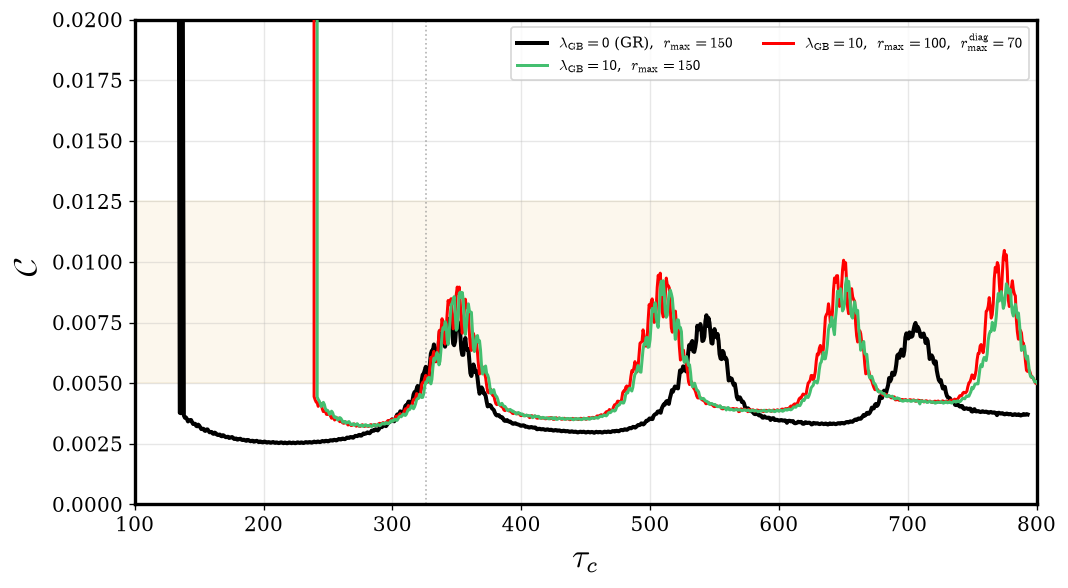

In [4]:
# ──────────────────────────────────────────────────────────────────────
# Plot:  C(tau_c) with GR as the baseline.
#   - The GR run (lambda_GB = 0) is plotted in its own (un-shifted)
#     central proper time; its first peak defines the anchor.
#   - Every other run is shifted along tau_c so that *its* first peak
#     lands on top of GR's first peak.
#   - lgb > 0 are coloured along viridis from pale to dark by |lambda_GB|.
# ──────────────────────────────────────────────────────────────────────

from matplotlib.cm import viridis

# Window in which to look for the *first* peak of C, in the original
# (un-aligned) central-proper-time units. Lower bound trims initial-
# condition transients; raise it if pre-formation wobbles are picked up.
ALIGN_WINDOW   = (0, 800)
# Minimum prominence required for a maximum to count as a "real" peak
# (set to 0.0 to accept any local maximum). Helps reject tiny ripples.
PEAK_PROMINENCE = 1e-4
# Acceptable absolute height of the first peak (in units of C). The
# physical formation peaks of these runs live in this band; anything
# below is an IC wobble, anything above is an unphysical spike.
PEAK_HEIGHT_RANGE = (5e-3, 1.25e-2)
# Absolute x-axis range to display (in raw tau_c units, since the
# baseline is GR's un-shifted curve).
DISPLAY_WINDOW = (50, 700)


def _first_peak_tau(tau, C, lo, hi,
                    prom=PEAK_PROMINENCE, height_range=PEAK_HEIGHT_RANGE):
    """Return the tau_c value of the first local maximum of C inside
    [lo, hi] satisfying both the prominence threshold and the absolute
    height band. Falls back to the in-window argmax if nothing qualifies.
    Returns None if the window has fewer than 3 samples."""
    h_lo, h_hi = height_range
    mask = (tau >= lo) & (tau <= hi)
    if mask.sum() < 3:
        return None
    t_w = tau[mask]
    C_w = C[mask]
    for i in range(1, len(C_w) - 1):
        if C_w[i] > C_w[i - 1] and C_w[i] > C_w[i + 1]:
            local_prom = C_w[i] - min(C_w[i - 1], C_w[i + 1])
            if local_prom >= prom and h_lo <= C_w[i] <= h_hi:
                return float(t_w[i])
    return float(t_w[int(np.argmax(C_w))])


if len(runs) == 0 and len(runs_alt_box) == 0:
    print('No runs matched the selection — adjust the filters in the cell above.')
else:
    lgbs_sorted = sorted(runs.keys(), key=lambda v: (abs(v), v))
    lgbs_nonzero = [v for v in lgbs_sorted if v != 0.0]

    def _color(lgb):
        if lgb == 0.0:
            return 'k'
        if len(lgbs_nonzero) <= 1:
            return viridis(0.7)
        rank = lgbs_nonzero.index(lgb) if lgb in lgbs_nonzero else 0
        frac = 0.15 + 0.80 * rank / (len(lgbs_nonzero) - 1)
        return viridis(frac)

    # Anchor: GR's first peak (or the first available default-box run).
    anchor_lgb = 0.0 if 0.0 in runs else (lgbs_sorted[0] if lgbs_sorted else None)
    if anchor_lgb is None:
        raise RuntimeError('No default-box runs loaded — cannot define anchor.')
    anchor_peak = _first_peak_tau(runs[anchor_lgb]['tau_c'],
                                  runs[anchor_lgb]['C'], *ALIGN_WINDOW)
    if anchor_peak is None:
        raise RuntimeError(
            f'No qualifying first peak for the anchor run lgb={anchor_lgb} '
            f'inside tau_c in {ALIGN_WINDOW}, height in {PEAK_HEIGHT_RANGE}.')
    anchor_label = 'GR' if anchor_lgb == 0.0 else f'lambda_GB={anchor_lgb:g}'
    print(f'  anchor = {anchor_label}   tau_c (first peak) = {anchor_peak:.3f}')

    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    _missing_peak = []

    # ── Default-box runs (solid lines) ─────────────────────────────────
    for lgb in lgbs_sorted:
        d       = runs[lgb]
        t_peak  = _first_peak_tau(d['tau_c'], d['C'], *ALIGN_WINDOW)
        if t_peak is None:
            _missing_peak.append(('default', lgb, R_MAX_DEFAULT))
            continue
        shift       = anchor_peak - t_peak
        tau_shifted = d['tau_c'] + shift
        lbl = (rf'$\lambda_{{\rm GB}}={lgb:g}$' +
               (' (GR)' if lgb == 0.0 else '') +
               rf',  $r_{{\max}}={R_MAX_DEFAULT:g}$')
        lw  = 2.4 if lgb == 0.0 else 1.8
        z   = 3   if lgb == 0.0 else 4
        ax.plot(tau_shifted, d['C'], color=_color(lgb), lw=lw, ls='-',
                label=lbl, zorder=z)
        print(f'  [default-box] lgb={lgb:>6g}   first-peak tau_c = {t_peak:8.3f}   '
              f'shifted by {shift:+8.3f}')

    # ── Alternate-box runs (dashed lines, same color as their lambda) ───
    alt_keys_sorted = sorted(runs_alt_box.keys(),
                             key=lambda k: (abs(k[0]), k[0], k[1]))
    for (lgb, r_max_val) in alt_keys_sorted:
        d       = runs_alt_box[(lgb, r_max_val)]
        t_peak  = _first_peak_tau(d['tau_c'], d['C'], *ALIGN_WINDOW)
        if t_peak is None:
            _missing_peak.append(('alt', lgb, r_max_val))
            continue
        shift       = anchor_peak - t_peak
        tau_shifted = d['tau_c'] + shift
        r_diag_note = (f',  $r^{{\\rm diag}}_{{\\max}}={d["r_max_diag"]:g}$'
                       if d.get('r_max_diag') is not None else '')
        lbl = (rf'$\lambda_{{\rm GB}}={lgb:g}$,  '
               rf'$r_{{\max}}={r_max_val:g}$' + r_diag_note)
        ax.plot(tau_shifted, d['C'], color="red", lw=1.8, ls='-',
                label=lbl, zorder=3)
        print(f'  [alt-box]     lgb={lgb:>6g}, r_max={r_max_val:g}   '
              f'first-peak tau_c = {t_peak:8.3f}   shifted by {shift:+8.3f}')

    ax.axvline(anchor_peak, color='grey', ls=':', lw=1.0, alpha=0.6)
    ax.axhspan(*PEAK_HEIGHT_RANGE, color='goldenrod', alpha=0.08, zorder=0)
    ax.set_xlabel(r'$\tau_c$')
    ax.set_ylabel(r'$\mathcal{C}$ ')
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, loc='best', fontsize=9)
    ax.set_ylim(0, 0.02)
    ax.set_xlim(*DISPLAY_WINDOW)
    ax.set_xlim(100, 800)

    if _missing_peak:
        print('[align] could not find a qualifying first peak for: '
              + ', '.join(f'{which}/lgb={l:g}/r_max={r:g}'
                          for which, l, r in _missing_peak)
              + f' inside tau_c in {ALIGN_WINDOW}, '
                f'height in {PEAK_HEIGHT_RANGE}; those curves were skipped. '
                'Widen ALIGN_WINDOW or PEAK_HEIGHT_RANGE to include them.')

    fig.tight_layout()
    save_fig(fig, OUT_NAME + '_GR_baseline')
    plt.show()

  saved rho_profile_lgb0_vs_lgb10_vs_g2_10.pdf and rho_profile_lgb0_vs_lgb10_vs_g2_10.png


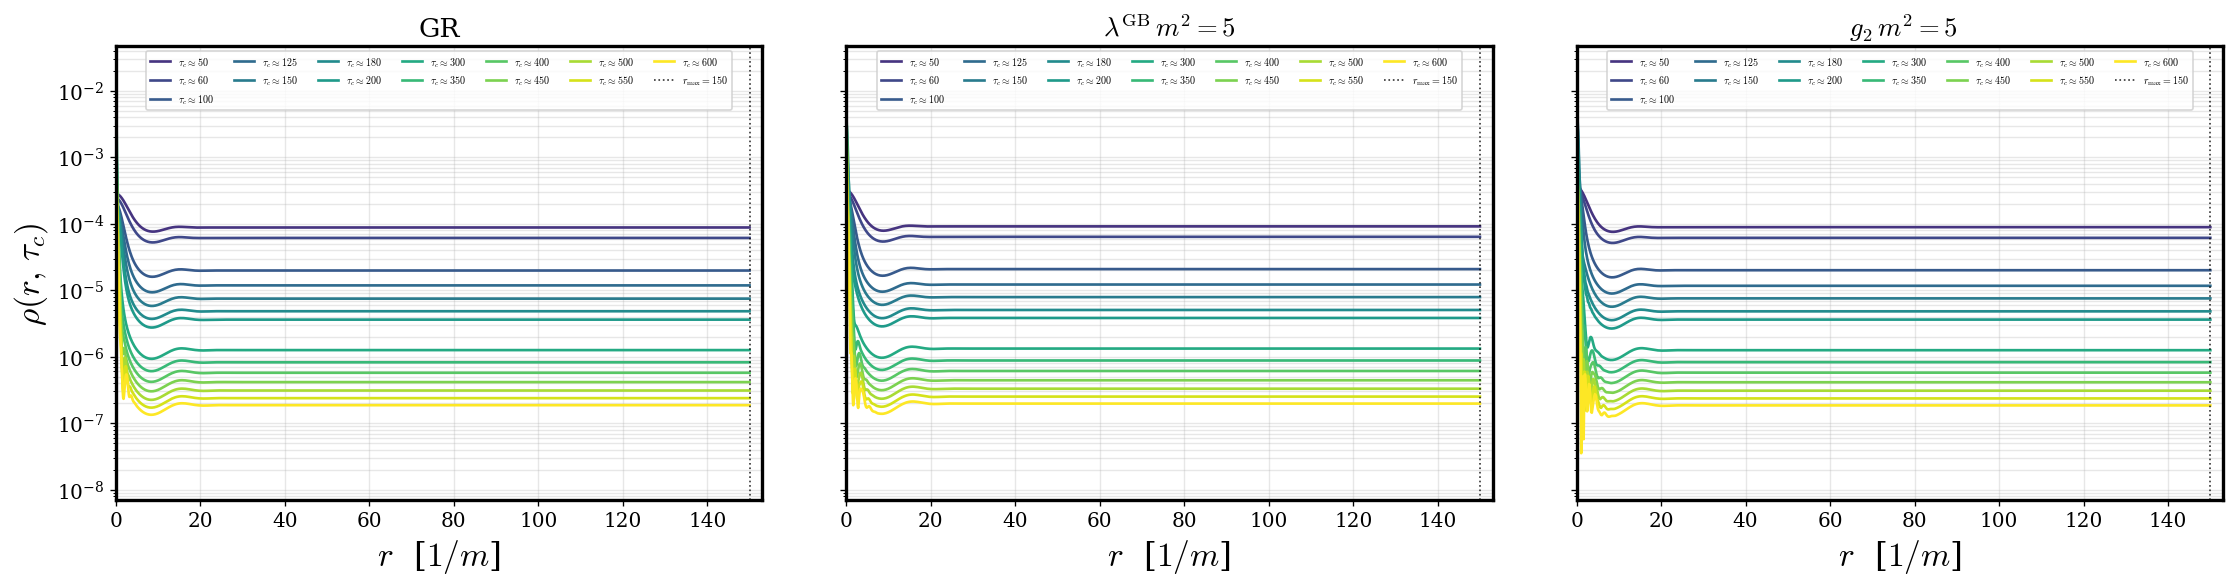

In [11]:
# ──────────────────────────────────────────────────────────────────────
# Boundary-contamination check:  rho(r) snapshots for GR vs lambda_GB=10
# vs g2=10
#
# For each run we load the cached diagnostics.npz to get rho(r,t_i), then
# overlay a handful of radial profiles taken at common central-proper-time
# values. If the outer boundary (r = r_max) is reflecting waves back into
# the domain, the rho profile will pick up ripples / a non-monotone tail
# in the region r ~ R_MAX_DIAG ... r_max at late times. A clean run has
# rho falling smoothly to ~0 well before r_max.
# ──────────────────────────────────────────────────────────────────────

import os
from matplotlib.cm import viridis as _cmap_t

# Each panel description: (lgb, g2, tag_override).
# tag_override=None  -> use runs[lgb]['tag'] (loaded by the selection cell).
# tag_override=<str> -> load DATA_DIR/<tag>/diagnostics.npz directly.  This
# is how we pull in g2=10, which is filtered out of the global `runs` dict.
INSPECT_PANELS = [
    {'lgb': 0.0,  'g2': 0,  'tag': None},
    {'lgb': 10.0, 'g2': 0,  'tag': None},
    {'lgb': 0.0,  'g2': 10,
     'tag': 'lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_0_g210'},
]
SNAPSHOT_TAU_C  = [50,60,100,125,150,180, 200, 300,350, 400,450,500,550, 600, 800]   # central proper times to plot
RHO_FLOOR       = 1e-14                # floor for log-scale plotting

# Try to share a consistent y-range so the panels are directly
# comparable; we compute it on the fly below.
y_min, y_max = np.inf, -np.inf

fig, axes = plt.subplots(1, len(INSPECT_PANELS), figsize=(19, 5),
                         sharey=True)
if len(INSPECT_PANELS) == 1:
    axes = [axes]

panel_records = []  # cache (ax, r, rho_at_idxs, taus, lgb) for second pass

for ax, panel in zip(axes, INSPECT_PANELS):
    lgb = panel['lgb']
    g2  = panel['g2']
    if lgb == 0 and not g2:
        title = 'GR'
    elif g2:
        title = rf'$\;g_2\,m^2={g2/2:g}$'
    else:
        title = rf'$\lambda^{{\rm GB}}\,m^2={lgb/2:g}$'

    tag = panel['tag']
    if tag is None:
        if lgb not in runs:
            ax.text(0.5, 0.5, f'lambda_GB = {lgb:g}\nnot loaded',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title)
            continue
        tag = runs[lgb]['tag']

    run_dir  = os.path.join(DATA_DIR, tag)
    diag_path = os.path.join(run_dir, 'diagnostics.npz')
    if not os.path.exists(diag_path):
        ax.text(0.5, 0.5, f'{tag}\ndiagnostics.npz not found',
                ha='center', va='center', transform=ax.transAxes, fontsize=8)
        ax.set_title(title)
        continue
    osc_full = dict(np.load(diag_path, allow_pickle=True))

    # The g2=10 cache predates tau_c (and even alpha_c), so np.asarray
    # would KeyError on osc_full['tau_c']. Route through the loader's
    # _diag_for helper which (a) returns tau_c from cache when present,
    # (b) rebuilds tau_c on the fly from alpha_c, or (c) recomputes the
    # whole diagnostic and re-saves the cache. Falls through gracefully
    # if the helpers aren't in scope yet (e.g. cell 5 run before cell 3).
    if 'tau_c' not in osc_full or np.asarray(osc_full['tau_c']).size == 0:
        try:
            p_diag = _parse_tag_and_meta(tag, run_dir)
            osc_full, _t_run, _status = _diag_for(
                run_dir, p_diag, allow_recompute=True)
            print(f'  [{_status}]  {tag}')
        except NameError:
            ax.text(0.5, 0.5,
                    f'{tag}\ncache lacks tau_c; run the loader cell first',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=8)
            ax.set_title(title)
            continue
    r     = np.asarray(osc_full['r']).ravel()
    tau   = np.asarray(osc_full['tau_c']).ravel()
    #tau   = np.asarray(osc_full['t']).ravel()
    rho   = np.asarray(osc_full['rho'])
    if rho.shape[0] != tau.size:
        # Defensive: some older caches may store rho with shape mismatched
        # against tau_c. Trim to the common length.
        n = min(rho.shape[0], tau.size)
        rho, tau = rho[:n], tau[:n]

    picks = []
    for t_req in SNAPSHOT_TAU_C:
        if tau.max() < t_req:
            continue
        i = int(np.argmin(np.abs(tau - t_req)))
        picks.append((i, float(tau[i])))

    if not picks:
        ax.text(0.5, 0.5, 'no snapshots fall inside\nthis run\'s tau_c span',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        continue

    for k, (i, t_val) in enumerate(picks):
        col = _cmap_t(0.15 + 0.85 * k / max(len(picks) - 1, 1))
        rho_safe = np.maximum(rho[i, :], RHO_FLOOR)
        ax.plot(r, rho_safe, color=col, lw=1.6,
                label=rf'$\tau_c\approx{t_val:.0f}$')
        y_min = min(y_min, float(rho_safe.min()))
        y_max = max(y_max, float(rho_safe.max()))

    # Reference lines: diagnostic cutoff and outer boundary.
    r_outer = float(r.max())
    #ax.axvline(R_MAX_DIAG, color='red',  ls='--', lw=1.0, alpha=0.8,label=rf'$R_{{\rm diag}}={R_MAX_DIAG:g}$')
    ax.axvline(r_outer,    color='black', ls=':',  lw=1.0, alpha=0.8,
               label=rf'$r_{{\max}}={r_outer:g}$')

    ax.set_xlabel(r'$r$  [$1/m$]')
    ax.set_yscale('log')
    ax.set_xlim(0, r_outer * 1.02)
    #ax.set_xlim(1 ,152)
    #ax.set_xlim(0 ,15)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=6, loc='upper center', ncol=7)

axes[0].set_ylabel(r'$\rho(r,\,\tau_c)$')
if np.isfinite(y_min) and np.isfinite(y_max) and y_max > 0:
    pad = 5.0
    for ax in axes:
        ax.set_ylim(max(y_min / pad, RHO_FLOOR), y_max * pad)

#fig.suptitle(r'Radial energy-density profiles — boundary-contamination check',fontsize=14)
fig.tight_layout()
save_fig(fig, 'rho_profile_lgb0_vs_lgb10_vs_g2_10')
plt.show()

  spacetime colour range: |delta| <= 4.56e+03   (rho_bg_inf taken from r in (80.0, 140.0))
  saved rho_spacetime_lgb0_vs_lgb10.pdf and rho_spacetime_lgb0_vs_lgb10.png


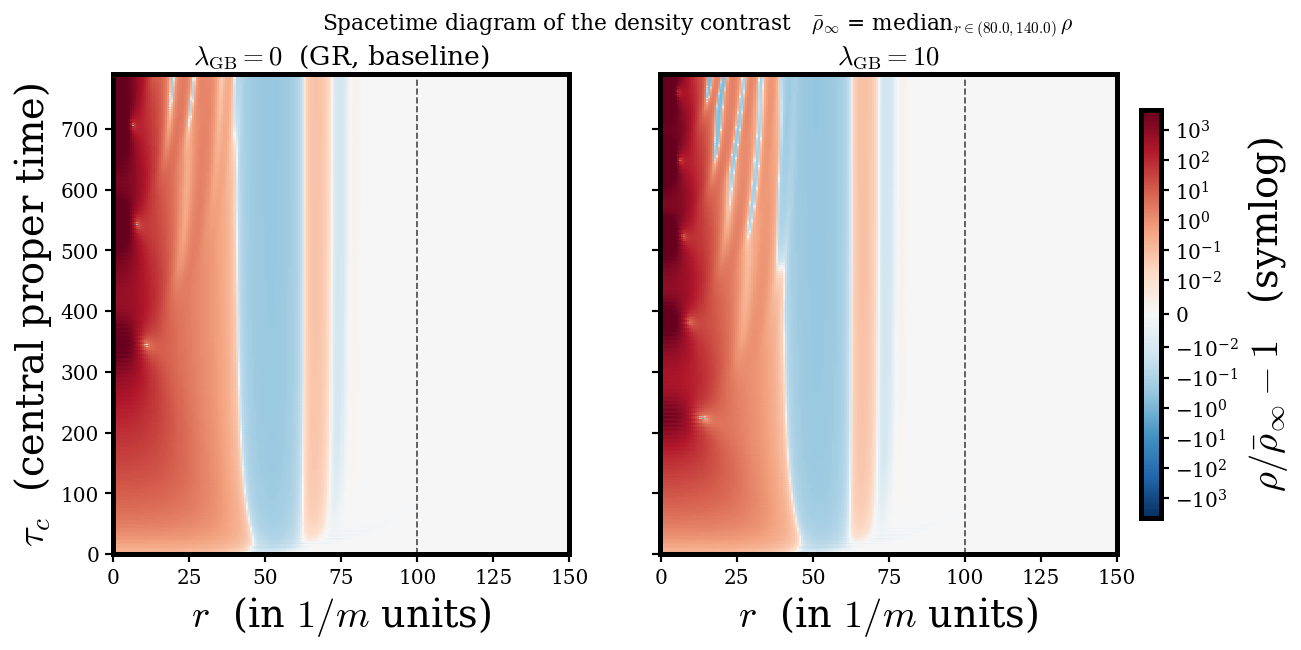

In [28]:
# ──────────────────────────────────────────────────────────────────────
# Spacetime diagram:  (rho/rho_bg_inf - 1)  vs  (r, tau_c)
#
# Subtracting an estimate of the FLRW-like background density rho_bg_inf
# (the average rho in an outer shell r in BG_SHELL) reveals localised
# structure that would otherwise be drowned by the homogeneous plateau:
#   - the oscillon shows up as a localised positive blob near r ~ 0,
#   - an outgoing scalar/GW wave shows up as a positive ridge with slope
#     dr/d tau_c ~ +1,
#   - a reflection off r_max shows up as a returning ridge with slope -1.
# Two panels (GR vs lambda_GB = 10), shared colour scale.
# ──────────────────────────────────────────────────────────────────────

from matplotlib.colors import SymLogNorm

INSPECT_LGBS_ST = [0.0, 10.0]
BG_SHELL        = (80.0, 140.0)     # radial band used to define rho_bg_inf
TAU_C_RANGE_ST  = (0.0, 800.0)      # vertical (tau_c) range shown

# Pre-load both runs and find a common colour-scale range.
panels = []
delta_min, delta_max = 0.0, 0.0
for lgb in INSPECT_LGBS_ST:
    if lgb not in runs:
        panels.append(None)
        continue
    tag      = runs[lgb]['tag']
    osc_full = dict(np.load(os.path.join(DATA_DIR, tag, 'diagnostics.npz'),
                            allow_pickle=True))
    r   = np.asarray(osc_full['r']).ravel()
    tau = np.asarray(osc_full['tau_c']).ravel()
    rho = np.asarray(osc_full['rho'])
    n = min(rho.shape[0], tau.size)
    rho, tau = rho[:n], tau[:n]
    # Restrict to the tau_c window the user cares about.
    t_mask = (tau >= TAU_C_RANGE_ST[0]) & (tau <= TAU_C_RANGE_ST[1])
    tau = tau[t_mask]; rho = rho[t_mask, :]
    # Asymptotic background: median rho over the outer shell, per time slice.
    bg_mask = (r >= BG_SHELL[0]) & (r <= BG_SHELL[1])
    rho_bg = np.median(rho[:, bg_mask], axis=1)         # (num_t,)
    rho_bg_safe = np.where(rho_bg > 0, rho_bg, np.nan)
    delta = (rho / rho_bg_safe[:, None]) - 1.0          # broadcast
    delta_min = min(delta_min, float(np.nanpercentile(delta, 1)))
    delta_max = max(delta_max, float(np.nanpercentile(delta, 99)))
    panels.append(dict(lgb=lgb, r=r, tau=tau, delta=delta))

# Symmetric range for the diverging colormap.
vlim = max(abs(delta_min), abs(delta_max), 1e-3)
print(f'  spacetime colour range: |delta| <= {vlim:.3g}'
      f'   (rho_bg_inf taken from r in {BG_SHELL})')

fig, axes = plt.subplots(1, len(INSPECT_LGBS_ST),
                         figsize=(13, 5.2), sharey=True)
if len(INSPECT_LGBS_ST) == 1:
    axes = [axes]

imgs = []
for ax, pdata, lgb in zip(axes, panels, INSPECT_LGBS_ST):
    if pdata is None:
        ax.text(0.5, 0.5, f'lambda_GB = {lgb:g}\nnot loaded',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(rf'$\lambda_{{\rm GB}}={lgb:g}$')
        continue
    r   = pdata['r']; tau = pdata['tau']; delta = pdata['delta']
    im = ax.imshow(
        delta,
        origin='lower',
        aspect='auto',
        extent=[float(r.min()), float(r.max()),
                float(tau.min()), float(tau.max())],
        cmap='RdBu_r',
        norm=SymLogNorm(linthresh=1e-2, vmin=-vlim, vmax=vlim, base=10),
        interpolation='nearest',
    )
    imgs.append(im)
    ax.axvline(R_MAX_DIAG, color='k',     ls='--', lw=1.0, alpha=0.7)
    ax.axvline(float(r.max()), color='k', ls=':',  lw=1.0, alpha=0.7)
    ax.set_xlabel(r'$r$  (in $1/m$ units)')
    ax.set_title(rf'$\lambda_{{\rm GB}}={lgb:g}$'
                 + ('  (GR, baseline)' if lgb == 0.0 else ''))

axes[0].set_ylabel(r'$\tau_c$  (central proper time)')
if imgs:
    cbar = fig.colorbar(imgs[-1], ax=axes, shrink=0.85, pad=0.02,
                        label=r'$\rho/\bar\rho_\infty - 1$   (symlog)')
fig.suptitle(r'Spacetime diagram of the density contrast'
             rf'   $\bar\rho_\infty$ = median$_{{r\in{BG_SHELL}}}\,\rho$',
             fontsize=13)
save_fig(fig, 'rho_spacetime_lgb0_vs_lgb10')
plt.show()

## Infrastructure copied from `finalplots2.ipynb`

The cells below set up the publication style, helpers, the full `all_runs` catalogue and the `select_runs(...)` filter that the GW / oscillon-amplitude plots further down need.

In [2]:
import sys, os, re, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, PROJECT_ROOT)

from core.grid import Grid
from core.spacing import CubicSpacing
from core.statevector import StateVector
from matter.scalarmatter_MG import ScalarMatter
from backgrounds.sphericalbackground import FlatSphericalBackground
from bssn.oscillondiagnostic import get_oscillon_diagnostic

DATA_DIR = os.path.join(os.environ.get('VSC_DATA', os.getcwd()), 'oscillon_runs')
FIG_DIR  = Path(os.getcwd()) / 'GoodFigures'
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.family':       'serif',
    'mathtext.fontset':  'cm',
    'figure.dpi':        120,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.labelsize':    20,
    'axes.titlesize':    16,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'legend.fontsize':   12,
    'lines.linewidth':   2.0,
    'axes.linewidth':    2.0,
})

def save_fig(fig, name):
    pdf = FIG_DIR / f'{name}.pdf'
    png = FIG_DIR / f'{name}.png'
    fig.savefig(pdf, bbox_inches='tight')
    fig.savefig(png, bbox_inches='tight')
    print(f'  saved {pdf.name} and {png.name}')

print(f'DATA_DIR = {DATA_DIR}')
print(f'FIG_DIR  = {FIG_DIR}')

DATA_DIR = /data/leuven/384/vsc38419/oscillon_runs
FIG_DIR  = /vsc-hard-mounts/leuven-user/384/vsc38419/0scillons/February26Oscillons/Feb26/RunningCode/DATA/GoodFigures


In [3]:
from numpy._core.numeric import False_


plt.rcParams.update({
    "font.family":      "serif",
    "mathtext.fontset": "cm",
    "figure.dpi":       120,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "axes.labelsize":   23,
    "axes.titlesize":   16,
    "xtick.labelsize":  12,
    "ytick.labelsize":  12,
    "legend.fontsize":  13,
    "lines.linewidth":  2.5,
    "axes.linewidth":   3,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "xtick.minor.width": 0.9,
    "ytick.minor.width": 0.9,
    "xtick.major.size":  5.0,
    "ytick.major.size":  5.0,
    "axes.grid":        False,
    "grid.alpha":       0.3,
})

def save_fig(fig, name):
    """Save fig as both PDF and PNG in GoodFigures/."""
    pdf_path = FIG_DIR / f"{name}.pdf"
    png_path = FIG_DIR / f"{name}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"  saved {pdf_path.name} and {png_path.name}")

In [4]:
ALIGN_LNA      = 2.0
ALIGN_METHOD   = "last_cross"   # "min_C" or "last_cross"
LNA_MIN_SEARCH = 0.0

C_CROSS_LEVELS = {
    -0.02: 0.02,
    -0.05: 0.04,
    -0.1:  0.06,
    -0.5:  0.125,
}
C_CROSS_DEFAULT = 0.02

LN_A_COMP_MIN = 2.0
LN_A_COMP_MAX = 3.5

scalar_mu = 1
r_max     = 150
min_dr    = 1 / 16
max_dr    = 2
a_mg      = 0.2
b_mg      = 0.4
chi0      = 0.15

In [5]:
def find_peak_lna(osc, lna_min=0.0):
    """Return ln(a) of the minimum compactness after lna_min."""
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    peak = idx[np.argmin(C[idx])]
    return ln_a[peak]

def find_last_crossing_lna(osc, level, lna_min=0.0):
    """Return ln(a) of the last time C crosses `level` (from above) after lna_min."""
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    C_sub = C[idx]
    ln_a_sub = ln_a[idx]
    above = C_sub > level
    crossings = np.where(above[:-1] & ~above[1:])[0]
    if len(crossings) == 0:
        return np.nan
    last = crossings[-1]
    frac = (level - C_sub[last+1]) / (C_sub[last] - C_sub[last+1])
    return ln_a_sub[last] * frac + ln_a_sub[last+1] * (1 - frac)

def compactness_in_window(shifted_ln_a, C, lo=LN_A_COMP_MIN, hi=LN_A_COMP_MAX):
    """Mean, min, max, std of C inside [lo, hi] on the *shifted* axis."""
    mask = (shifted_ln_a >= lo) & (shifted_ln_a <= hi)
    if not np.any(mask):
        return np.nan, np.nan, np.nan, np.nan
    c = C[mask]
    return np.mean(c), np.min(c), np.max(c), np.std(c)

def _key_sort(key):
    """Sort key for run-keys that may contain None (e.g. beta=None for linear coupling).

    Maps None -> +inf so linear runs sort after numeric beta values.
    """
    return tuple(float('inf') if v is None else v for v in key)

In [6]:
######## LOADING FILTERS ########
FILTER_A_MG = 0       # None to load all
FILTER_B_MG = 0       # None to load all
FILTER_DR   = 1/24    # None to load all
############################

# Key now includes g2 so quadratic and g2-EFT runs with the same
# (lgb, mu, beta, amp, width) but different g2 don't overwrite each other.
all_runs = {}   # key = (lgb, mu, beta, amp, width, g2)

for run_dir in sorted(glob.glob(os.path.join(DATA_DIR, "lgb*"))):
    tag = os.path.basename(run_dir)
    if not os.path.exists(os.path.join(run_dir, "solution.npy")):
        continue

    m_lgb = re.search(r"lgb([0-9eE.+-]+)", tag)
    m_mu  = re.search(r"mu([0-9eE.+-]+)", tag)
    m_amp = re.search(r"_amp([0-9eE.+-]+)", tag)
    m_R   = re.search(r"_R([0-9eE.+-]+)", tag)
    if not m_lgb or not m_mu:
        continue
    lgb   = float(m_lgb.group(1))
    mu    = float(m_mu.group(1))
    amp   = float(m_amp.group(1)) if m_amp else -0.02
    width = float(m_R.group(1))   if m_R   else 3.0

    m_a = re.search(r"_a([0-9eE.+-]+)_b", tag)
    m_b = re.search(r"_b([0-9eE.+-]+)_amp", tag)
    tag_a = float(m_a.group(1)) if m_a else 0.2
    tag_b = float(m_b.group(1)) if m_b else 0.4

    m_dr = re.search(r"_dr([0-9eE.+-]+)", tag)
    tag_dr = float(m_dr.group(1)) if m_dr else 0.0625

    if FILTER_A_MG is not None and abs(tag_a - FILTER_A_MG) > 1e-10:
        continue
    if FILTER_B_MG is not None and abs(tag_b - FILTER_B_MG) > 1e-10:
        continue
    if FILTER_DR is not None and abs(tag_dr - FILTER_DR) > 1e-4:
        continue

    # Derive coupling and beta from metadata.npz (authoritative source).
    # Per bssn/ModifiedGravity.py: "quadratic" (no suffix) => beta=250;
    # "quadratic_X" => beta=X; "linear" => beta=None.
    _meta_for_cpl = os.path.join(run_dir, "metadata.npz")
    _cpl_meta = None
    if os.path.exists(_meta_for_cpl):
        try:
            _md = dict(np.load(_meta_for_cpl, allow_pickle=True))
            if "coupling" in _md:
                _cpl_meta = str(_md["coupling"])
        except Exception:
            pass

    if _cpl_meta is not None:
        if _cpl_meta == "linear":
            coupling = "linear"; beta = None
        elif _cpl_meta.startswith("quadratic"):
            _parts = _cpl_meta.split("_")
            beta = float(_parts[1]) if len(_parts) > 1 else 250.0
            coupling = _cpl_meta
        else:
            coupling = _cpl_meta; beta = None
    else:
        # Fallback for runs with missing metadata: parse from tag string.
        if "_linear" in tag:
            coupling = "linear"; beta = None
        else:
            _m_beta = re.search(r"quadratic_(\d+\.?\d*)", tag)
            if _m_beta:
                beta = float(_m_beta.group(1))
                coupling = f"quadratic_{int(beta)}" if beta == int(beta) else f"quadratic_{beta}"
            else:
                # "_quadratic_g2X" or trailing "_quadratic" => coupling="quadratic" => beta=250
                coupling = "quadratic"; beta = 250.0

    # Extract g2: first from directory name, then from metadata, default 0.0
    g2_val = 0.0
    m_g2 = re.search(r"_g2([0-9eE.+-]+)", tag)
    if m_g2:
        g2_val = float(m_g2.group(1))
    else:
        meta_path = os.path.join(run_dir, "metadata.npz")
        if os.path.exists(meta_path):
            try:
                meta = dict(np.load(meta_path, allow_pickle=True))
                if "g2" in meta:
                    g2_val = float(meta["g2"])
            except Exception:
                pass

    # Grid must match the run that wrote solution.npy (notebook r_max/min_dr alone can differ).
    _meta_for_grid = os.path.join(run_dir, "metadata.npz")
    _meta_grid = dict(np.load(_meta_for_grid, allow_pickle=True)) if os.path.exists(_meta_for_grid) else {}
    run_r_max  = float(_meta_grid.get("r_max", r_max))
    run_min_dr = float(_meta_grid.get("min_dr", tag_dr))
    run_max_dr = float(_meta_grid.get("max_dr", max_dr))

    sol = np.load(os.path.join(run_dir, "solution.npy"))
    t   = np.load(os.path.join(run_dir, "t.npy"))

    matter_i  = ScalarMatter(scalar_mu, mu)
    sv_i      = StateVector(matter_i)
    spacing_i = CubicSpacing(**CubicSpacing.get_parameters(run_r_max, run_min_dr, run_max_dr))
    grid_i    = Grid(spacing_i, sv_i)
    bg_i      = FlatSphericalBackground(grid_i.r)

    diag_path = os.path.join(run_dir, "diagnostics.npz")
    if os.path.exists(diag_path):
        osc = dict(np.load(diag_path, allow_pickle=True))
    else:
        params = (lgb, a_mg, b_mg, chi0, coupling, g2_val)
        osc = get_oscillon_diagnostic(
            sol, t, grid_i, bg_i,
            ScalarMatter(scalar_mu, mu),
            params, surface_threshold=0.05, r_max_diag=100.0,
        )
        np.savez(diag_path, **osc)

    # Stash central scalar field phi(r=0, t)
    N_grid   = len(grid_i.r)
    NUM_VARS = sol.shape[1] // N_grid
    phi_c    = sol[:, 12 * N_grid].copy()

    if ALIGN_METHOD == "last_cross":
        cross_level = C_CROSS_LEVELS.get(amp, C_CROSS_DEFAULT)
        anchor_lna  = find_last_crossing_lna(osc, level=cross_level, lna_min=LNA_MIN_SEARCH)
    else:
        anchor_lna  = find_peak_lna(osc, lna_min=LNA_MIN_SEARCH)
    shift = ALIGN_LNA - anchor_lna if not np.isnan(anchor_lna) else 0.0
    shifted_ln_a = osc["ln_a"] + shift

    C_mean, C_min, C_max, C_std = compactness_in_window(shifted_ln_a, osc["C"])

    key = (lgb, mu, beta, amp, width, g2_val)
    new_entry = dict(
        osc=osc, t=t, phi_c=phi_c, tag=tag,
        lgb=lgb, mu=mu, beta=beta, coupling=coupling, amp=amp, width=width, g2=g2_val,
        run_dir=run_dir, dr=tag_dr,
        run_r_max=run_r_max, run_min_dr=run_min_dr, run_max_dr=run_max_dr,
        shift=shift, shifted_ln_a=shifted_ln_a,
        C_mean=C_mean, C_min=C_min, C_max=C_max, C_std=C_std,
    )

    # If another run already occupies this key, keep the one with the longer
    # shifted_ln_a span so a short/incomplete duplicate doesn't shadow a good
    # run. Ties are broken by the alphabetically-later tag (matches the old
    # "sorted() last wins" behaviour).
    if key in all_runs:
        prev = all_runs[key]
        prev_span = float(np.ptp(np.asarray(prev["shifted_ln_a"])))
        new_span  = float(np.ptp(np.asarray(shifted_ln_a)))
        if new_span > prev_span or (new_span == prev_span and tag > prev["tag"]):
            print(f"  [overwrite] {prev['tag']} -> {tag}  "
                  f"(ln_a span {prev_span:.3f} -> {new_span:.3f})")
            all_runs[key] = new_entry
        else:
            print(f"  [skip]      {tag}  (would shadow {prev['tag']} "
                  f"with shorter ln_a span {new_span:.3f} < {prev_span:.3f})")
            del sol
            continue
    else:
        all_runs[key] = new_entry

    beta_str = f"beta={int(beta)}" if beta is not None else "linear"
    if np.isnan(C_mean):
        print(f"  lgb={lgb:6.1f}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}, g2={g2_val:g}  "
              f"shift={shift:+.3f}  C: no data in window  ({len(t)} steps)")
    else:
        print(f"  lgb={lgb:6.1f}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}, g2={g2_val:g}  "
              f"shift={shift:+.3f}  C={C_mean:.4e} [{C_min:.4e}, {C_max:.4e}]  ({len(t)} steps)")
    del sol

print(f"\nTotal: {len(all_runs)} run(s) loaded and aligned")

  lgb=  -1.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.538  C=7.1395e-03 [4.3339e-03, 1.4466e-02]  (1000 steps)
  lgb=  -2.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.536  C=7.0535e-03 [4.2847e-03, 1.3609e-02]  (1000 steps)
  lgb=  -3.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.531  C=6.9746e-03 [4.2228e-03, 1.3554e-02]  (1000 steps)
  lgb=  -4.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.526  C=6.8850e-03 [4.1713e-03, 1.3361e-02]  (1000 steps)
  lgb=  -5.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.524  C=6.8001e-03 [4.1293e-03, 1.3226e-02]  (1000 steps)
  lgb=  -6.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.490  C=6.7319e-03 [4.1234e-03, 1.2932e-02]  (1000 steps)
  lgb=  -7.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.480  C=6.6470e-03 [4.0823e-03, 1.2883e-02]  (1000 steps)
  lgb=  -8.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.475  C=6.5698e-03 [4.0308e-03, 1.2720e-02]  (1000 steps)
  lgb=  

In [7]:
all_lgb   = sorted(set(k[0] for k in all_runs))
all_mu    = sorted(set(k[1] for k in all_runs))
all_beta  = sorted(set(k[2] for k in all_runs if k[2] is not None))
has_linear = any(k[2] is None for k in all_runs)
all_amp   = sorted(set(k[3] for k in all_runs))
all_width = sorted(set(k[4] for k in all_runs))
all_g2    = sorted(set(k[5] for k in all_runs))
all_couplings = sorted(set(d["coupling"] for d in all_runs.values()))

print(f"runs loaded:      {len(all_runs)}")
print(f"lambda_GB values: {all_lgb}")
print(f"mu values:        {all_mu}")
print(f"beta values:      {all_beta}" + ('  (+ linear runs present)' if has_linear else ''))
print(f"amplitude values: {all_amp}")
print(f"width values:     {all_width}")
print(f"g2 values:        {all_g2}")
print(f"couplings:        {all_couplings}")

print("\nLoaded keys (lgb, mu, beta, amp, width, g2):")
header = (f"  {'lgb':>6s}  {'mu':>5s}  {'beta':>5s}  {'amp':>6s}  {'R':>4s}  {'g2':>6s}  "
          f"{'coupling':<14s}  {'shift':>7s}  {'C_mean':>10s}")
print(header)
print("  " + "-" * (len(header) - 2))
for k in sorted(all_runs.keys(), key=_key_sort):
    d = all_runs[k]
    beta_s = "lin" if k[2] is None else f"{k[2]:g}"
    cmean  = "nan" if np.isnan(d['C_mean']) else f"{d['C_mean']:.3e}"
    print(f"  {k[0]:>6g}  {k[1]:>5g}  {beta_s:>5s}  {k[3]:>6g}  {k[4]:>4g}  {k[5]:>6g}  "
          f"{d['coupling']:<14s}  {d['shift']:>+7.3f}  {cmean:>10s}")

runs loaded:      220
lambda_GB values: [-9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]
mu values:        [0.08]
beta values:      [0.0, 250.0]  (+ linear runs present)
amplitude values: [-1.0, -0.5, -0.1, -0.05, -0.02, -0.0002]
width values:     [3.0]
g2 values:        [-10.0, -5.0, -4.0, -3.0, -2.0, -1.0, -0.5, 0.0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 25.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 40.0, 50.0]
couplings:        ['linear', 'quadratic', 'quadratic_0', 'quadratic_0_noBR', 'quadratic_0_rampOn']

Loaded keys (lgb, mu, beta, amp, width, g2):
     lgb     mu   beta     amp     R      g2  coupling          shift      C_mean
  -------------------------------------------------------------------------------
      -9   0.08      0   -0.02     3      20  quadratic

In [8]:
def select_runs(lgb=None, mu=None, beta=None, amp=None, width=None, g2=None, coupling=None):
    """Return list of keys in all_runs whose fields are in the given allowed lists.

    Pass a single value or a list; None = no filter on that dimension.
    Keys are 6-tuples: (lgb, mu, beta, amp, width, g2).
    """
    def _norm(v):
        if v is None: return None
        return v if isinstance(v, (list, tuple, set)) else [v]

    lgb, mu, beta = _norm(lgb), _norm(mu), _norm(beta)
    amp, width, g2 = _norm(amp), _norm(width), _norm(g2)
    coupling = _norm(coupling)

    def _in(x, allowed): return allowed is None or x in allowed

    matches = [
        k for k, d in all_runs.items()
        if _in(k[0], lgb) and _in(k[1], mu) and _in(k[2], beta)
        and _in(k[3], amp) and _in(k[4], width) and _in(k[5], g2)
        and _in(d["coupling"], coupling)
    ]
    return sorted(matches, key=_key_sort)

## GW spectra and oscillon-amplitude plots

Self-contained set of plots copied over from `finalplots2.ipynb`. Run the cells in order: Panel 7 must run first because it builds `p7_runs`, `p7_Renv` and `p7_results` that every later plot consumes.

P7_PURE_ONLY: kept 21 of 59 keys (only pure-λ_GB and pure-g₂ runs).
21 run(s) loaded:
  (0.0, 0.08, 0.0, -0.02, 3.0, 0.0)  A=0.1749, R_diag=12.438, omega_s=0.9611, H0=5.3985e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 1.0)  A=0.1887, R_diag=11.399, omega_s=0.9635, H0=5.3504e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 2.0)  A=0.1921, R_diag=11.003, omega_s=0.9538, H0=5.3505e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 3.0)  A=0.1984, R_diag=10.640, omega_s=0.9538, H0=5.3507e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 4.0)  A=0.2123, R_diag=10.225, omega_s=0.9440, H0=5.3508e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 5.0)  A=0.2170, R_diag=10.241, omega_s=0.9440, H0=5.3509e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 6.0)  A=0.2245, R_diag=9.893, omega_s=0.9440, H0=5.3510e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 7.0)  A=0.2316, R_diag=9.859, omega_s=0.9343, H0=5.3511e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 8.0)  A=0.2374, R_diag=9.743, omega_s=0.9343, H0=5.3511e-03
  (0.0, 0.08, 0.0, -0.02, 3.0, 9.0)  A=0.2439, R_diag=9.503, omega_s=0.9246, H0=5.3512e-0

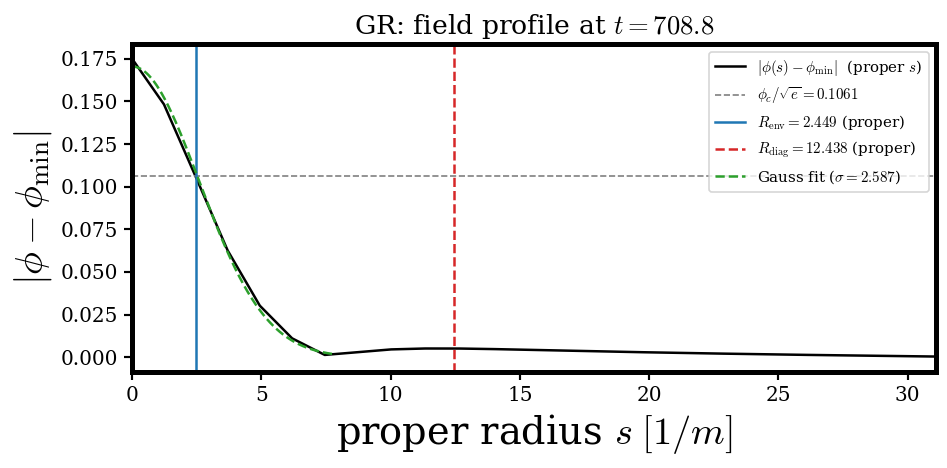

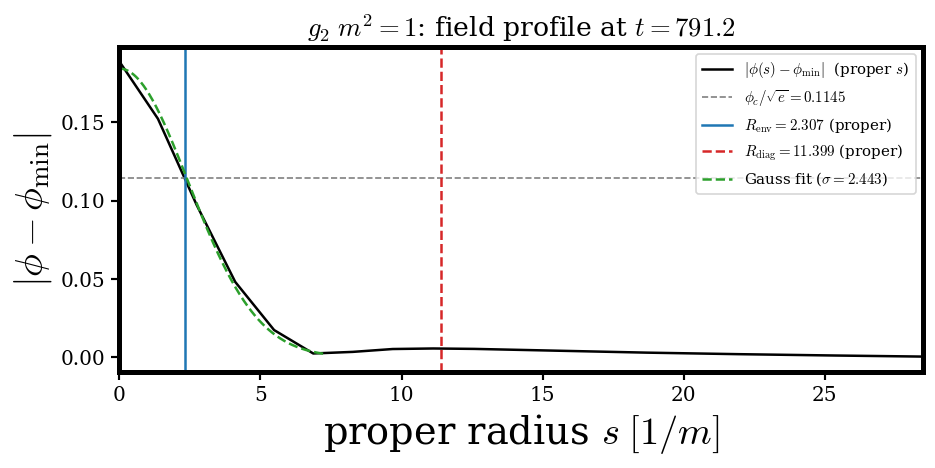

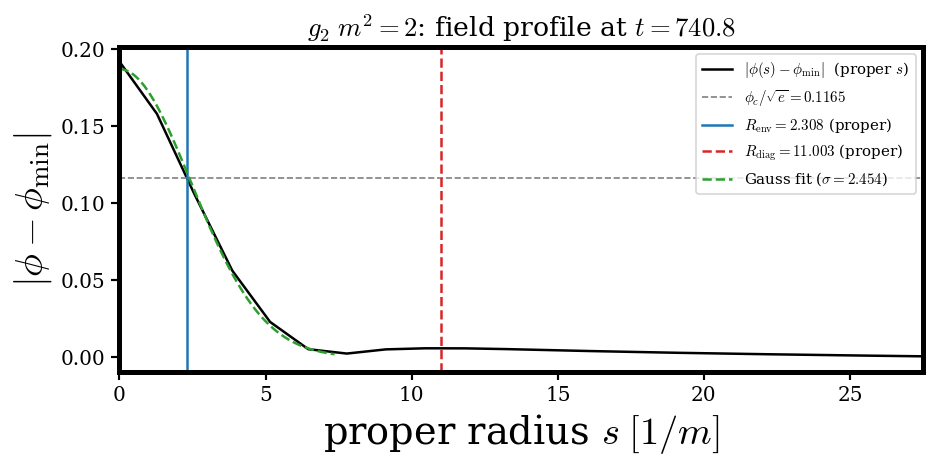

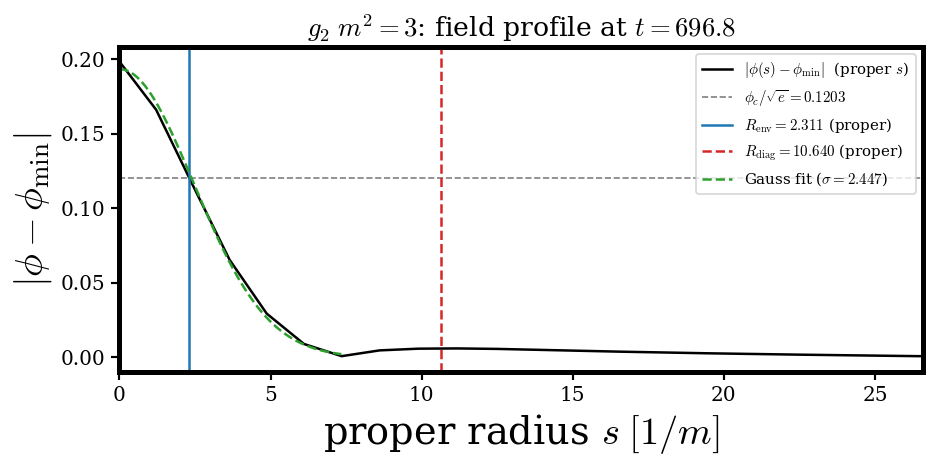

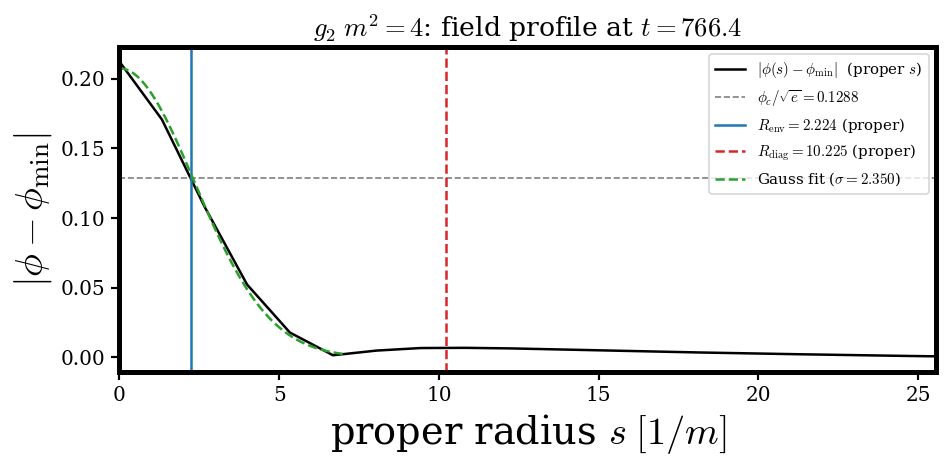

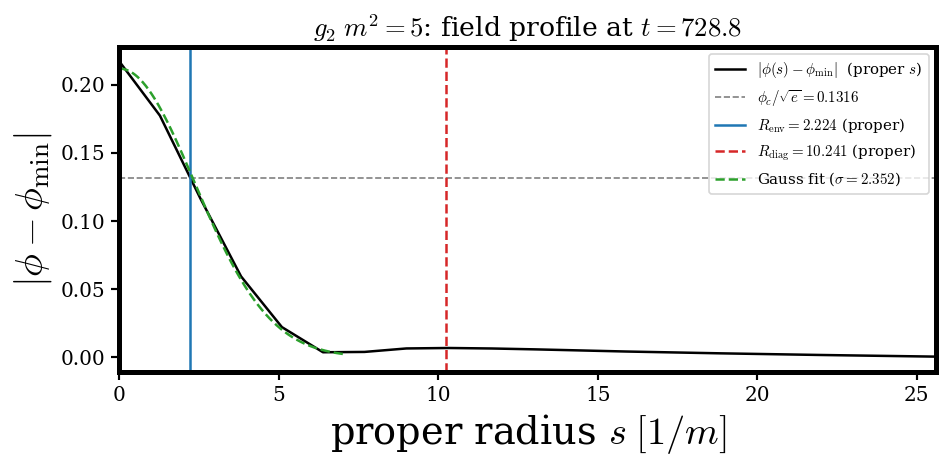

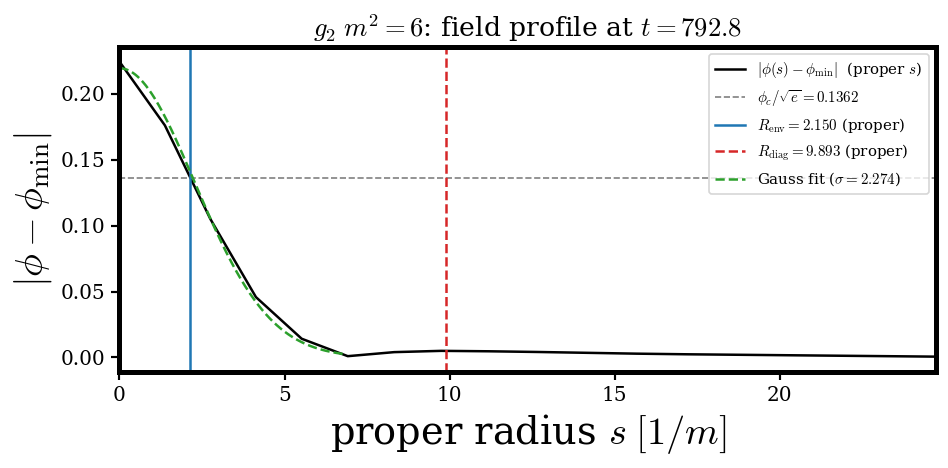

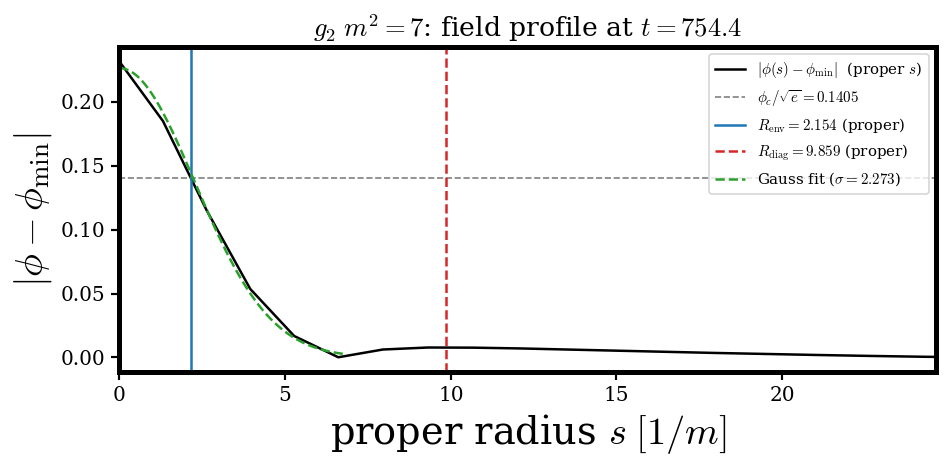

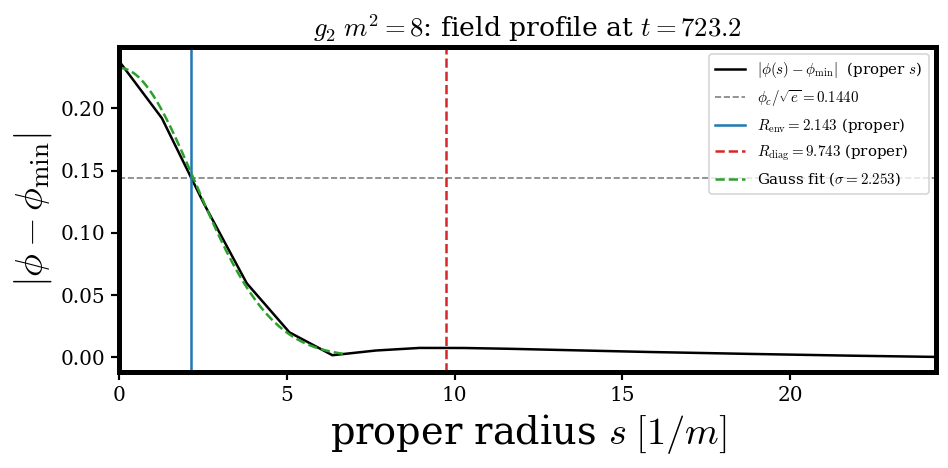

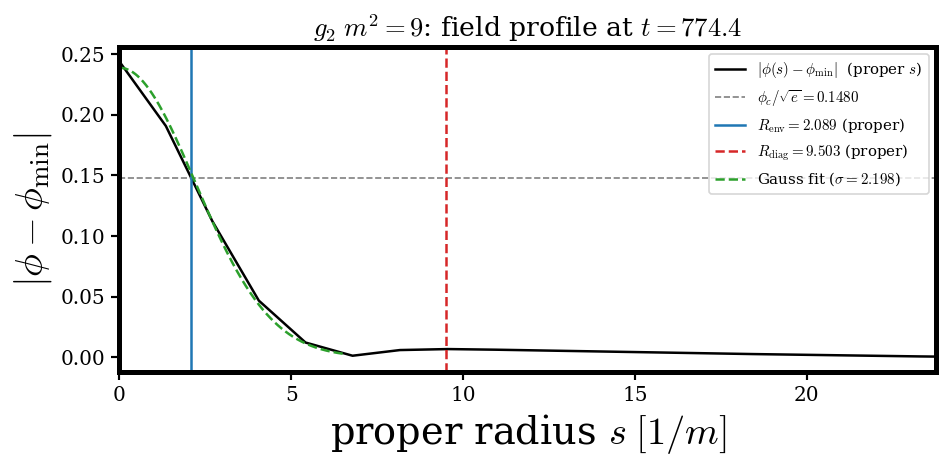

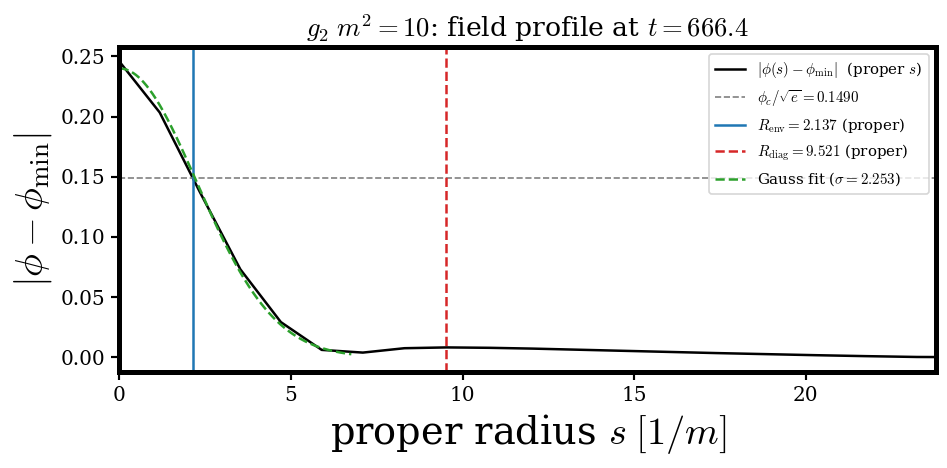

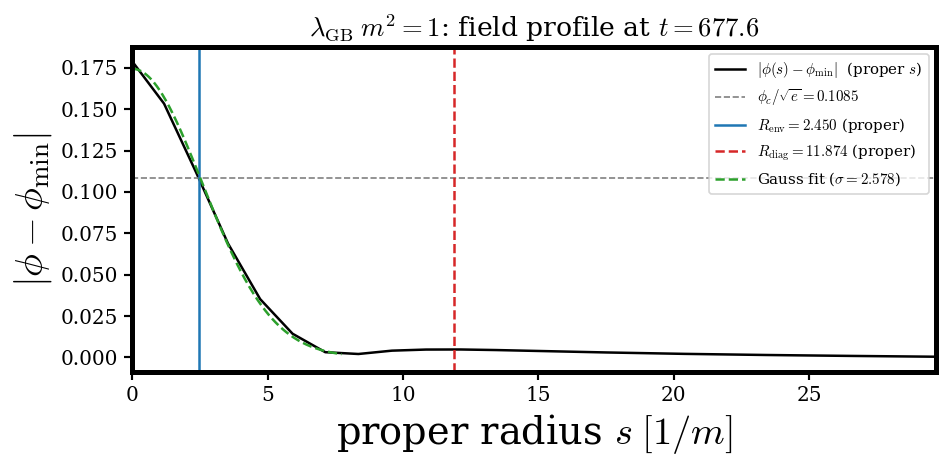

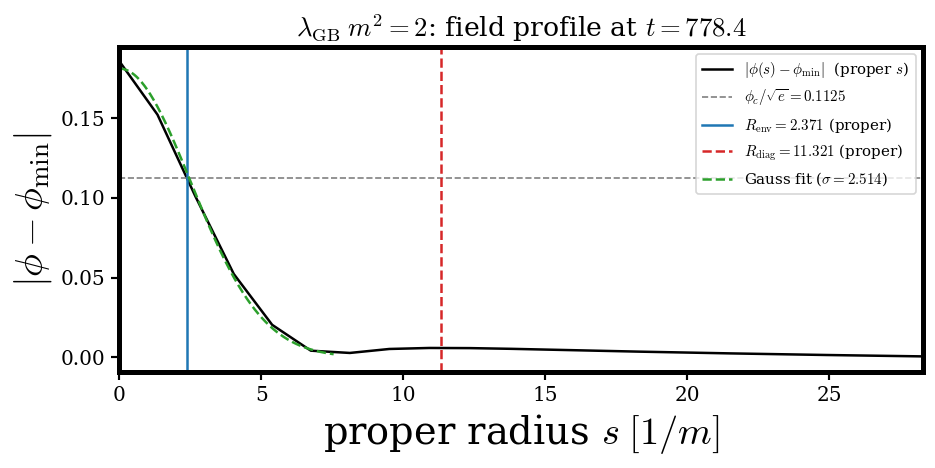

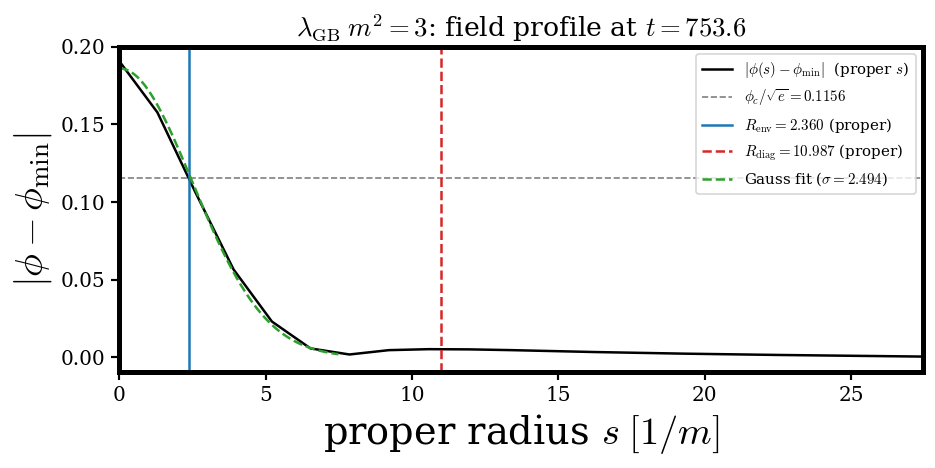

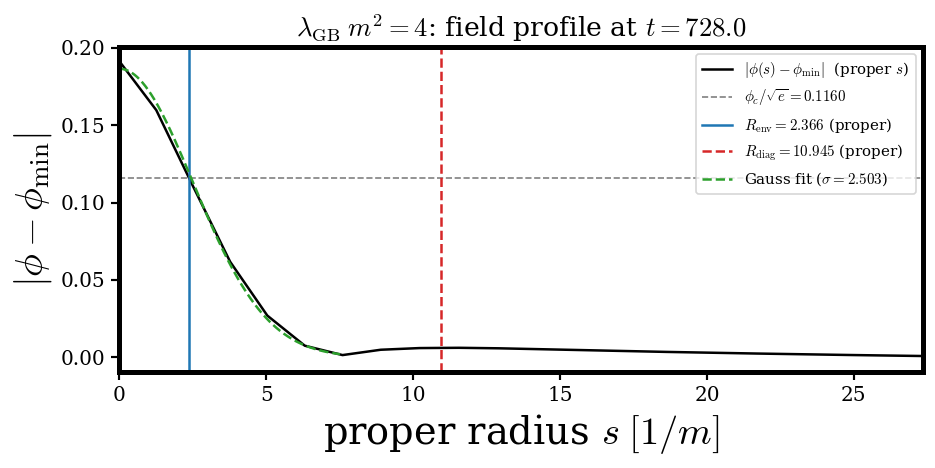

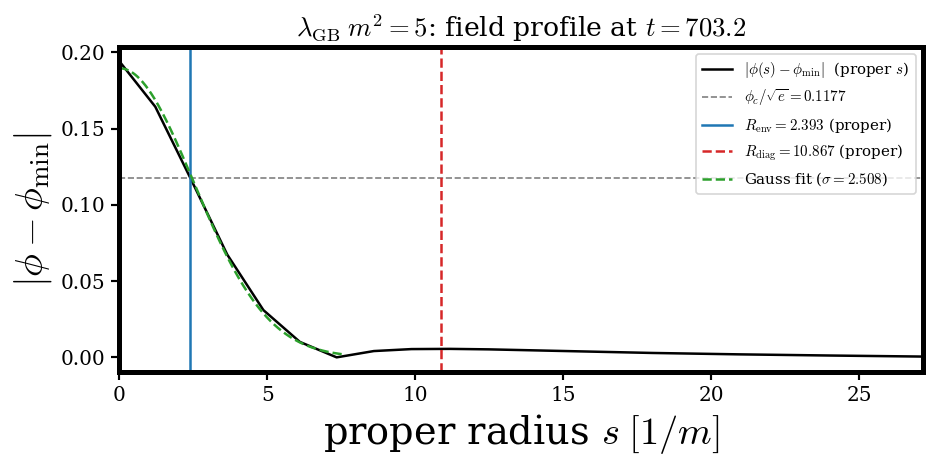

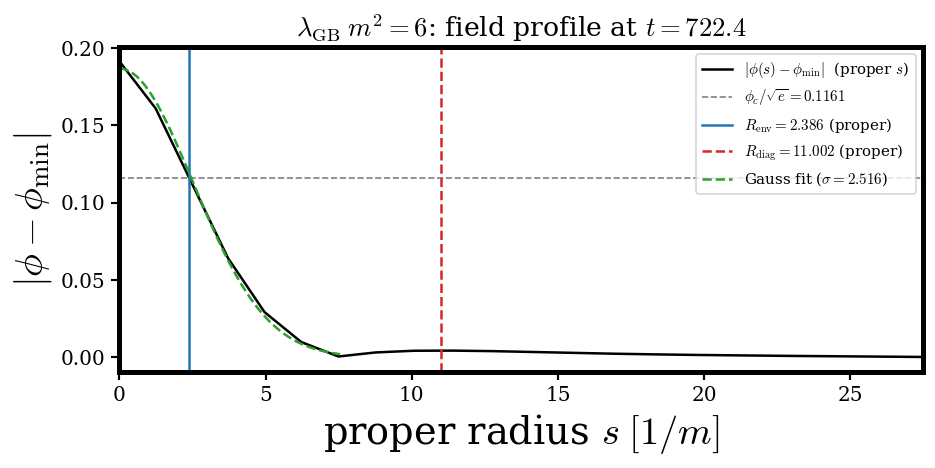

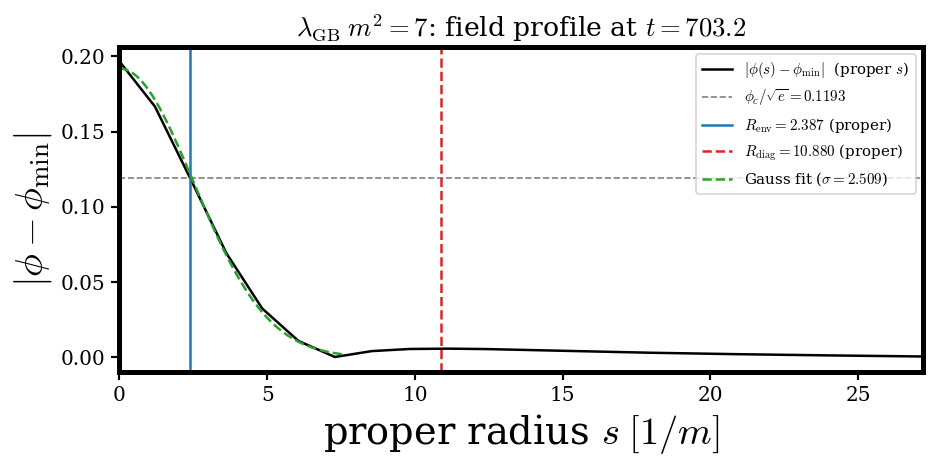

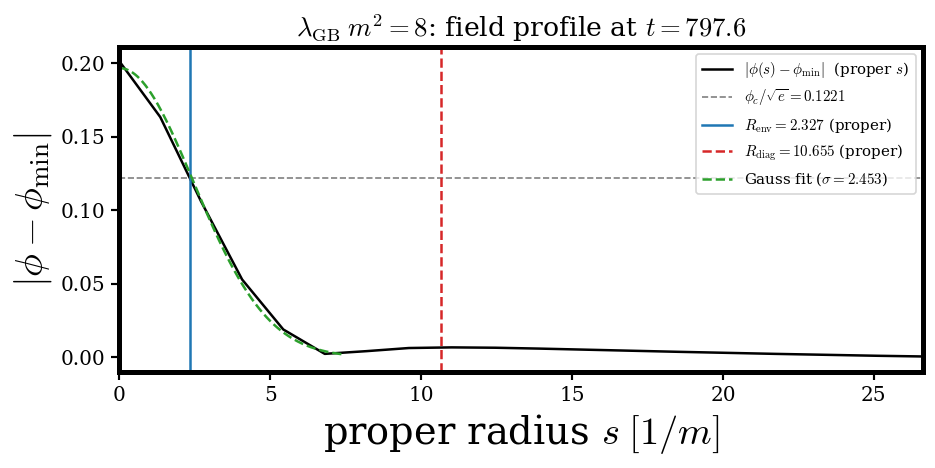

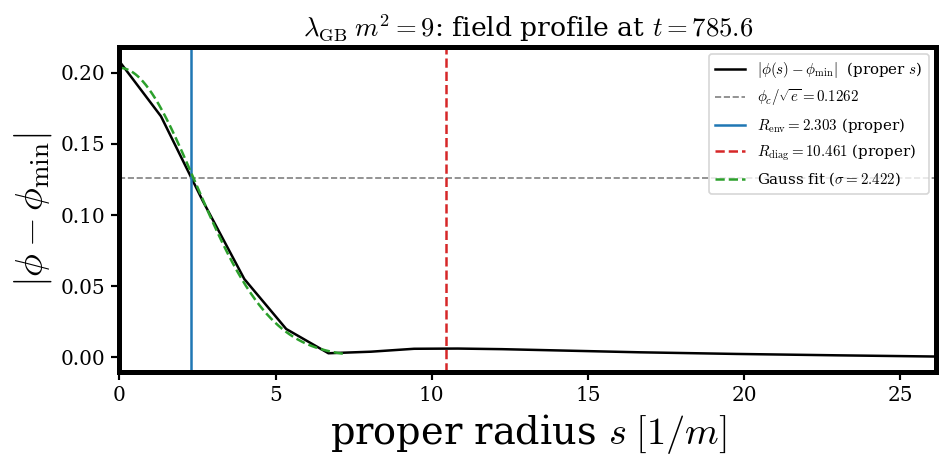

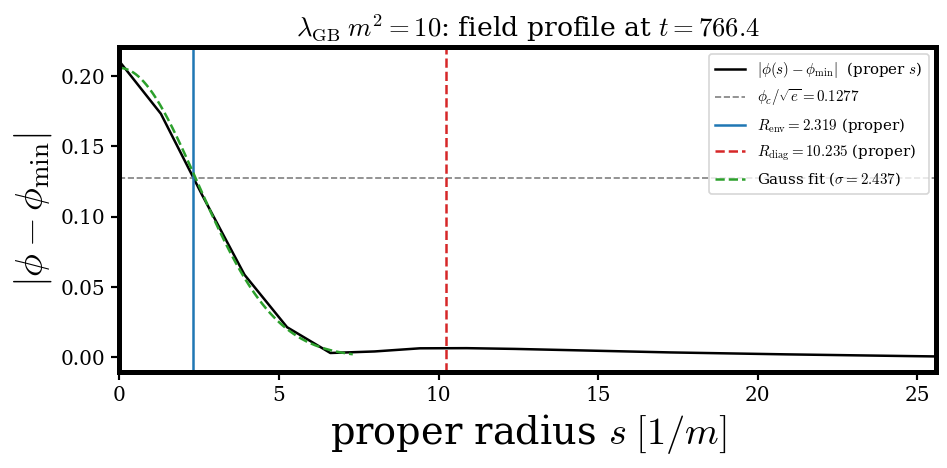

Running GR  (ωR_env=2.354, a_f=3.12) ...
Running $g_2\;m^2=1$  (ωR_env=2.223, a_f=3.12) ...
Running $g_2\;m^2=2$  (ωR_env=2.201, a_f=3.12) ...
Running $g_2\;m^2=3$  (ωR_env=2.204, a_f=3.12) ...
Running $g_2\;m^2=4$  (ωR_env=2.100, a_f=3.12) ...
Running $g_2\;m^2=5$  (ωR_env=2.099, a_f=3.12) ...
Running $g_2\;m^2=6$  (ωR_env=2.029, a_f=3.12) ...
Running $g_2\;m^2=7$  (ωR_env=2.012, a_f=3.12) ...
Running $g_2\;m^2=8$  (ωR_env=2.002, a_f=3.12) ...
Running $g_2\;m^2=9$  (ωR_env=1.931, a_f=3.12) ...
Running $g_2\;m^2=10$  (ωR_env=1.974, a_f=3.12) ...
Running $\lambda_{\rm GB}\;m^2=1$  (ωR_env=2.364, a_f=3.12) ...
Running $\lambda_{\rm GB}\;m^2=2$  (ωR_env=2.279, a_f=3.12) ...
Running $\lambda_{\rm GB}\;m^2=3$  (ωR_env=2.254, a_f=3.12) ...
Running $\lambda_{\rm GB}\;m^2=4$  (ωR_env=2.262, a_f=3.12) ...
Running $\lambda_{\rm GB}\;m^2=5$  (ωR_env=2.280, a_f=3.12) ...
Running $\lambda_{\rm GB}\;m^2=6$  (ωR_env=2.284, a_f=3.12) ...
Running $\lambda_{\rm GB}\;m^2=7$  (ωR_env=2.285, a_f=3.12) ...


In [9]:
# ============================================================================
# Panel 7 — GW spectra using R_env = proper 1/√e field half-width.
#   R_env is measured as a PROPER radius (∫ e^{2φ} dr to the 1/√e crossing),
#   consistent with the envelope's physical-width convention (eq. 3.3) and
#   with R_diag. R_diag (density-ball) is kept only for reporting + volume.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.optimize import curve_fit

from bssn.GWSignal import (
    Omega_GW, OscillonRun, background_a_of_t, DEFAULT_DELTA, PHI_MIN,
)
from core.spacing import NUM_GHOSTS
from bssn.bssnstatevariables import NUM_BSSN_VARS

# ── !! VERIFY THESE TWO AGAINST YOUR CODE !! ─────────────────────────────────
PHI_BSSN_IDX = 0     # row index of the BSSN conformal factor `phi` in the
                     # flattened state (the var your diagnostic calls bssn_N.phi).
                     # NOT the matter field (that's at NUM_BSSN_VARS).
                     # Check BSSNVars.set_bssn_vars / bssnstatevariables ordering.
PROPER_FACTOR_EXP = 2.0   # radial proper length element = e^{PROPER_FACTOR_EXP * phi} dr.
                          # Standard BSSN with gamma~_rr = 1 -> 2.0. If your conformal
                          # metric has gamma~_rr != 1, multiply by sqrt(gamma~_rr).
# ─────────────────────────────────────────────────────────────────────────────

PLOT7_KEYS = select_runs(
    lgb=[0,1,2,3,4,5,6,7,8,9,10], 
    mu=[0.08], 
    beta=[0], 
    amp=[-0.02], 
    width=[3.0], 
    g2=[0,1,2,3,4,5,6,7,8,9,10],
)
P7_PURE_ONLY = True   # if True: drop mixed-coupling combinations
                      # (keep only λ_GB=0 OR g₂=0)
if P7_PURE_ONLY:
    _n_before = len(PLOT7_KEYS)
    PLOT7_KEYS = [k for k in PLOT7_KEYS if k[0] == 0.0 or k[5] == 0.0]
    print(f"P7_PURE_ONLY: kept {len(PLOT7_KEYS)} of {_n_before} keys "
          f"(only pure-λ_GB and pure-g₂ runs).")

P7_STABLE_WINDOW = (2.0, 3.5)
P7_DELTA, P7_N_OSC = DEFAULT_DELTA, 1
P7_N_ANGLES, P7_N_TAU = 20, 500
P7_SEED, P7_N_HUBBLE, P7_N_K, P7_KMAX_FAC = 42, 3, 200, 3.0
P7_SHOW_PROFILE = True
P7_NAME = "GW_spectrum_Renv_proper"

def _label(key):
    lgb, mu, beta, amp, width, g2 = key
    if lgb == 0.0 and g2 == 0.0: return "GR"
    if lgb != 0.0 and g2 != 0.0: return rf"$\lambda_{{\rm GB}}\;m^2={lgb:g},\ g_2={g2:g}$"
    if lgb != 0.0:               return rf"$\lambda_{{\rm GB}}\;m^2={lgb:g}$"
    return rf"$g_2\;m^2={g2:g}$"

# Match the colour scheme used by Panel 4 (g2 -> blue ramp) and Panel 4-GB
# (lambda_GB -> red ramp) in finalplots2.ipynb. GR (lgb=0, g2=0) stays black.
# When both lgb and g2 are non-zero (mixed coupling), we fall back to tab10
# so that mixed runs remain visually distinguishable from the pure ramps.
from matplotlib.colors import LinearSegmentedColormap as _LSC

_unique_g2_p7  = sorted({k[5] for k in PLOT7_KEYS if k[5] != 0.0})
_unique_lgb_p7 = sorted({k[0] for k in PLOT7_KEYS if k[0] != 0.0},
                        key=lambda v: (abs(v), v))
_BLUES_RAMP_P7 = _LSC.from_list("_p7_g2_blues", ["#fafbfc", "blue"])
_REDS_RAMP_P7  = _LSC.from_list("_p7_lgb_reds", ["#fee0d2", "#c0392b"])

def _ramp_frac(rank, total):
    if total <= 1:
        return 1.0
    return 0.30 + 0.70 * rank / (total - 1)

def _color(idx, key):
    lgb, mu, beta, amp, width, g2 = key
    if lgb == 0.0 and g2 == 0.0:
        return "k"                                  # GR
    if g2 != 0.0 and lgb == 0.0:                    # pure g2 -> blue ramp
        rank = _unique_g2_p7.index(g2)
        return _BLUES_RAMP_P7(_ramp_frac(rank, len(_unique_g2_p7)))
    if lgb != 0.0 and g2 == 0.0:                    # pure lambda_GB -> red ramp
        rank = _unique_lgb_p7.index(lgb)
        return _REDS_RAMP_P7(_ramp_frac(rank, len(_unique_lgb_p7)))
    return cm.tab10(idx % 10)                       # mixed coupling fallback

# ── 1. load runs ─────────────────────────────────────────────────────────────
p7_runs = {}
for k in PLOT7_KEYS:
    run = OscillonRun(all_runs[k]["run_dir"], label=_label(k),
                      stable_window=P7_STABLE_WINDOW)
    run.extract_all(verbose=False)
    p7_runs[k] = run

print(f"{len(PLOT7_KEYS)} run(s) loaded:")
for k, run in p7_runs.items():
    print(f"  {k}  A={run.A:.4f}, R_diag={run.R:.3f}, "
          f"omega_s={run.omega_source:.4f}, H0={run.H0:.4e}")

# ── 2. R_env: proper 1/√e field half-width ───────────────────────────────────
def _gauss(s, A, sigma):
    return A * np.exp(-s**2 / (2.0 * sigma**2))

def extract_R_env(run):
    sol  = run._solution_array()
    mask = run._stable_mask()
    n_vars = sol.shape[1] // run.grid.num_points

    # peak-amplitude time step in the stable window
    dev = np.abs(run.u_r0_t - PHI_MIN)
    s_idx = np.where(mask)[0]
    i_peak = s_idx[np.argmax(dev[s_idx])]

    sol2d = sol[i_peak].reshape(n_vars, run.grid.num_points)
    r_phys   = run.r[NUM_GHOSTS:]                              # coordinate r
    phi_mat  = np.abs(sol2d[NUM_BSSN_VARS, NUM_GHOSTS:] - PHI_MIN)  # |matter field|
    phi_conf = sol2d[PHI_BSSN_IDX, NUM_GHOSTS:]               # BSSN conformal factor

    # cumulative PROPER radius s(r) = ∫_0^r e^{2 phi_conf} dr'
    e_fac = np.exp(PROPER_FACTOR_EXP * phi_conf)
    ds = 0.5 * (e_fac[1:] + e_fac[:-1]) * np.diff(r_phys)
    s_proper = np.concatenate([[0.0], np.cumsum(ds)])

    phi_c  = phi_mat[0]
    thresh = phi_c / np.sqrt(np.e)

    # 1/√e crossing, interpolated in PROPER radius s
    i_cross = np.where(phi_mat < thresh)[0]
    if i_cross.size and i_cross[0] > 0:
        j = i_cross[0]
        p0, p1 = phi_mat[j-1], phi_mat[j]
        s0, s1 = s_proper[j-1], s_proper[j]
        frac = (thresh - p0) / (p1 - p0)
        R_env = s0 + frac * (s1 - s0)
        warn = ""
    else:
        R_env = s_proper[-1]
        warn = "  ⚠ profile never reached φ_c/√e — R_env = proper grid edge"

    # Gaussian fit in proper radius (cross-check)
    core = phi_mat > 0.10 * phi_c
    try:
        popt, _ = curve_fit(_gauss, s_proper[core], phi_mat[core],
                            p0=[phi_c, max(R_env, 1e-3)], maxfev=5000)
        R_env_fit = abs(popt[1])
    except (RuntimeError, ValueError):
        popt, R_env_fit = None, np.nan

    a_here = float(np.exp(2.0 * phi_conf[0]))  # ~ scale factor at center (e^{2phi})
    return dict(R_env=float(R_env), R_env_fit=float(R_env_fit),
                phi_c=float(phi_c), thresh=float(thresh),
                r_phys=r_phys, s_proper=s_proper, profile=phi_mat,
                popt=popt, t_peak=float(run.t[i_peak]),
                a_center=a_here, warn=warn)

p7_Renv = {k: extract_R_env(run) for k, run in p7_runs.items()}

print(f"\n{'─'*78}")
print(f"  {'run':<12s}{'R_diag':>9s}{'R_env_p':>9s}{'R_fit_p':>9s}"
      f"{'a_ctr':>8s}{'ωR_diag':>9s}{'ωR_env':>9s}{'φ_c':>8s}{'A':>8s}")
print(f"  {'─'*72}")
for k, run in p7_runs.items():
    e, ws = p7_Renv[k], run.omega_source
    print(f"  {run.label:<12s}{run.R:>9.3f}{e['R_env']:>9.3f}{e['R_env_fit']:>9.3f}"
          f"{e['a_center']:>8.2f}{ws*run.R:>9.2f}{ws*e['R_env']:>9.3f}"
          f"{e['phi_c']:>8.3f}{run.A:>8.3f}" + e["warn"])
print(f"{'─'*78}\n")

if P7_SHOW_PROFILE:
    for idx, (k, run) in enumerate(p7_runs.items()):
        e = p7_Renv[k]
        fig, ax = plt.subplots(figsize=(8, 4))
        # plot vs PROPER radius so R_env/R_diag are comparable on one axis
        ax.plot(e["s_proper"], e["profile"], 'k-', lw=1.5,
                label=r"$|\phi(s)-\phi_{\min}|$  (proper $s$)")
        ax.axhline(e["thresh"], color='gray', ls='--', lw=1,
                   label=rf"$\phi_c/\sqrt{{e}}={e['thresh']:.4f}$")
        ax.axvline(e["R_env"], color='C0', lw=1.5,
                   label=rf"$R_{{\rm env}}={e['R_env']:.3f}$ (proper)")
        ax.axvline(run.R, color='C3', ls='--', lw=1.5,
                   label=rf"$R_{{\rm diag}}={run.R:.3f}$ (proper)")
        if e["popt"] is not None:
            ss = np.linspace(0, min(3*e["R_env_fit"], e["s_proper"][-1]), 300)
            ax.plot(ss, _gauss(ss, *e["popt"]), 'C2--', lw=1.5,
                    label=rf"Gauss fit ($\sigma={e['R_env_fit']:.3f}$)")
        ax.set_xlim(0, max(2.5*run.R, 4*e["R_env"]))
        ax.set_xlabel(r"proper radius $s\;[1/m]$")
        ax.set_ylabel(r"$|\phi-\phi_{\min}|$")
        ax.set_title(rf"{run.label}: field profile at $t={e['t_peak']:.1f}$")
        ax.legend(fontsize=9); fig.tight_layout(); plt.show()

# ── 3. spectra (R_env proper in envelope; V from R_diag, decoupled) ──────────
def _a_final(H0, tau_end, w=0.0, n=5000):
    t = np.linspace(0.0, tau_end, n)
    return float(background_a_of_t(t, w, H0)[-1])

def _fourier_modes(run):
    # run.harmonics are (omega_n, A_n, phase_n) least-squares modes of the
    # source Phi^2(t) (A_n already in phi^2 units) -> feed them straight through.
    return [(float(w), float(A_n), float(ph)) for w, A_n, ph in run.harmonics]

p7_results, skipped = {}, []
for k in PLOT7_KEYS:
    run, e = p7_runs[k], p7_Renv[k]
    R_env, ws, H0 = e["R_env"], run.omega_source, run.H0
    if not all(np.isfinite(v) and v > 0 for v in (run.A, R_env, ws, H0)):
        print(f"  [skip] {run.label}: bad param"); skipped.append(k); continue

    tau_w = (0.0, P7_N_HUBBLE / H0)
    a_f   = _a_final(H0, tau_w[1])
    oR    = ws * R_env
    k_max_phys = P7_KMAX_FAC * (2.0 / R_env)
    k_grid = np.logspace(np.log10(0.01 * ws),
                         np.log10(k_max_phys * a_f), P7_N_K)

    print(f"Running {run.label}  (ωR_env={oR:.3f}, a_f={a_f:.2f}) ...")
    res = Omega_GW(
        A=run.A, R=R_env, omega_source=ws, H0=H0, w=0.0,
        Delta=P7_DELTA, N=P7_N_OSC,
        V=(100.0 * run.R)**3,        # placeholder volume from R_diag; cancels in ratios
        n_angles=P7_N_ANGLES, n_tau=P7_N_TAU,
        k_grid=k_grid, tau_window=tau_w, seed=P7_SEED,
        harmonics="fourier", fourier_modes=_fourier_modes(run),
    )
    p7_results[k] = dict(res=res, oR=oR, a_f=a_f, R_env=R_env, run=run)

print(f"\nComputed {len(p7_results)}, skipped {len(skipped)}.")
for k, r in p7_results.items():
    print(f"  {r['run'].label}: peak k/ω = "
          f"{r['res']['peak_k']/r['run'].omega_source:.3f},  "
          f"Ω_max = {r['res']['Omega_GW'].max():.3e}")

print("Spectra ready — plot in next cell.")

saved -> GoodFigures/Renv_profile_0.pdf


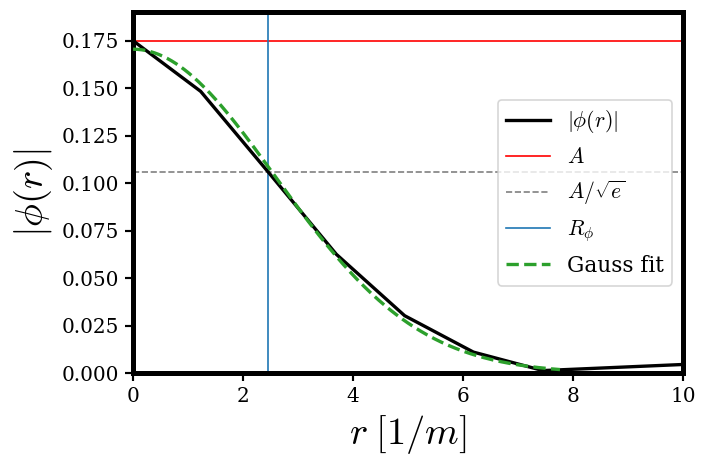

saved -> GoodFigures/Renv_profile_1.pdf


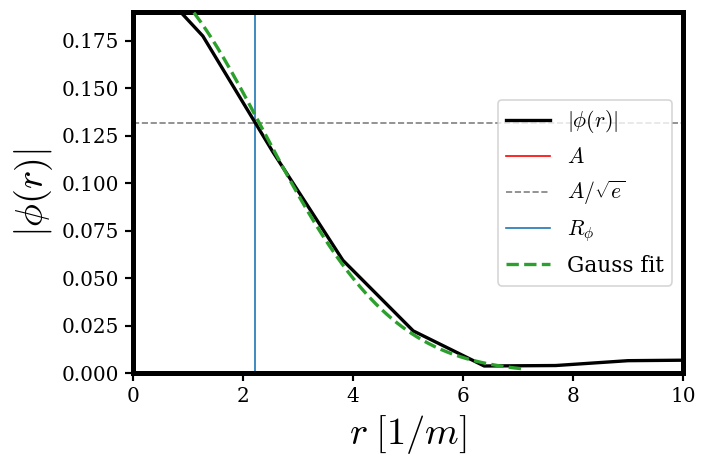

In [24]:
# ============================================================================
# Standalone copy of the R_env field-profile plot (same as Panel 7 above).
#   Reuses p7_runs / p7_Renv computed in the cell above. Tweak styling and
#   uncomment fig.savefig(...) to export.
# ============================================================================
P7_SAVE_FIG = True   # set False to skip saving
P7_SAVE_DIR = "GoodFigures"
os.makedirs(P7_SAVE_DIR, exist_ok=True)
for idx, (k, run) in enumerate(p7_runs.items()):
    e = p7_Renv[k]
    fig, ax = plt.subplots(figsize=(6, 4))
    # plot vs PROPER radius so R_env/R_diag are comparable on one axis
    ax.plot(e["s_proper"], e["profile"], 'k-', lw=2,label=r"$|\phi(r)|$", zorder=5)
    ax.axhline(run.A, color='red', ls='-', lw=1,label=rf"$A$", zorder=1)
    #ax.axhline(run.A, color='red', ls='-', lw=1,label=rf"$A={run.A:.3f}$", zorder=1)
    ax.axhline(e["thresh"], color='gray', ls='--', lw=1,label=rf"$A/\sqrt{{e}}$")
    #ax.axhline(e["thresh"], color='gray', ls='--', lw=1,label=rf"$A/\sqrt{{e}}={e['thresh']:.4f}$")

    ax.axvline(e["R_env"], color='C0', lw=1,label=rf"$R_{{\rm \phi}}$")
    #ax.axvline(run.R, color='C3', ls='--', lw=1.5,label=rf"$R_{{\rm oscillon}}={run.R:.3f}$ (proper)")
    if e["popt"] is not None:
        ss = np.linspace(0, min(3*e["R_env_fit"], e["s_proper"][-1]), 300)
        ax.plot(ss, _gauss(ss, *e["popt"]), 'C2--', lw=2,label=rf"Gauss fit", zorder=10)
        #ax.plot(ss, _gauss(ss, *e["popt"]), 'C2--', lw=2,label=rf"Gauss fit ($\sigma={e['R_env_fit']:.3f}$)", zorder=10)

    # horizontal double-sided arrow for R_phi (0 -> R_env)
    y_arrow = 0.40 * e["phi_c"]
    #ax.annotate("", xy=(e["R_env"], y_arrow), xytext=(0.0, y_arrow),arrowprops=dict(arrowstyle="<->", color="C0", lw=1.5))
    #ax.text(0.5 * e["R_env"], y_arrow, r"$R_\phi$", color="C0",ha="center", va="bottom", fontsize=12)
    # vertical double-sided arrow for A (0 -> A)
    x_arrow = 6
    #ax.annotate("", xy=(x_arrow, run.A), xytext=(x_arrow, 0.0),arrowprops=dict(arrowstyle="<->", color="red", lw=1.5))
    #ax.text(x_arrow, 0.5 * run.A, r"$\;\;\;A$", color="red",ha="left", va="center", fontsize=12)
    ax.set_xlim(0, max(2.5*run.R, 4*e["R_env"]))
    ax.set_xlim(0,10)
    ax.set_ylim(0,0.190)
    ax.set_xlabel(r"$r\;[1/m]$")
    ax.set_ylabel(r"$|\phi(r)|$")
    #ax.set_title(rf"{run.label}: field profile at $t={e['t_peak']:.1f}$")
    ax.legend(fontsize=13, loc="center right")
    fig.tight_layout()
    if P7_SAVE_FIG:
        fname = os.path.join(P7_SAVE_DIR, f"Renv_profile_{idx}.pdf")
        fig.savefig(fname, dpi=300, bbox_inches="tight")
        print(f"saved -> {fname}")
    plt.show()


In [10]:
# ── Table: source Fourier modes (frequencies + amplitudes) per parameter combo ──
# run.harmonics = (omega_n, A_n, phase_n): least-squares modes of the radiating
# source Phi^2(t) - trend (A_n in units of phi^2), from
# OscillonRun.extract_source_fourier_modes().  These are the exact modes fed into
# Omega_GW via _fourier_modes(run) in the cell above.

hdr = (f"{'run':<20s}{'n':>3s}{'omega_n [m]':>14s}{'omega_n/omega_1':>16s}"
       f"{'A_n [phi^2]':>15s}{'A_n/A_1':>10s}{'phase_n':>10s}")
print(hdr)
print("─" * len(hdr))
for k, run in p7_runs.items():
    modes = np.asarray(run.harmonics, dtype=float)
    if modes.size == 0:
        print(f"{run.label:<20s}  (no modes)")
        print("─" * len(hdr))
        continue
    om1, A1 = modes[0, 0], modes[0, 1]
    for n, (om, A_n, ph) in enumerate(modes, start=1):
        name = run.label if n == 1 else ""
        print(f"{name:<20s}{n:>3d}{om:>14.4f}{om/om1:>16.3f}"
              f"{A_n:>15.4e}{A_n/A1:>10.3f}{ph:>10.3f}")
    print(f"{'':<20s}{'#modes='}{len(modes):d}")
    print("─" * len(hdr))

run                   n   omega_n [m] omega_n/omega_1    A_n [phi^2]   A_n/A_1   phase_n
────────────────────────────────────────────────────────────────────────────────────────
GR                    1        0.9611           1.000     2.5436e-03     1.000    -2.530
                      2        1.9028           1.980     7.5263e-04     0.296     1.142
                      3        2.8348           2.949     3.3267e-04     0.131    -1.518
                      4        3.7571           3.909     1.1256e-04     0.044     1.047
                    #modes=4
────────────────────────────────────────────────────────────────────────────────────────
$g_2\;m^2=1$          1        0.9635           1.000     1.5102e-03     1.000     0.651
                      2        1.8686           1.939     4.6594e-04     0.309     0.018
                      3        2.8224           2.929     2.7795e-04     0.184     2.538
                      4        3.7469           3.889     1.6334e-04     0.108   

  saved GW_spectrum_Renv_proper.pdf and GW_spectrum_Renv_proper.png


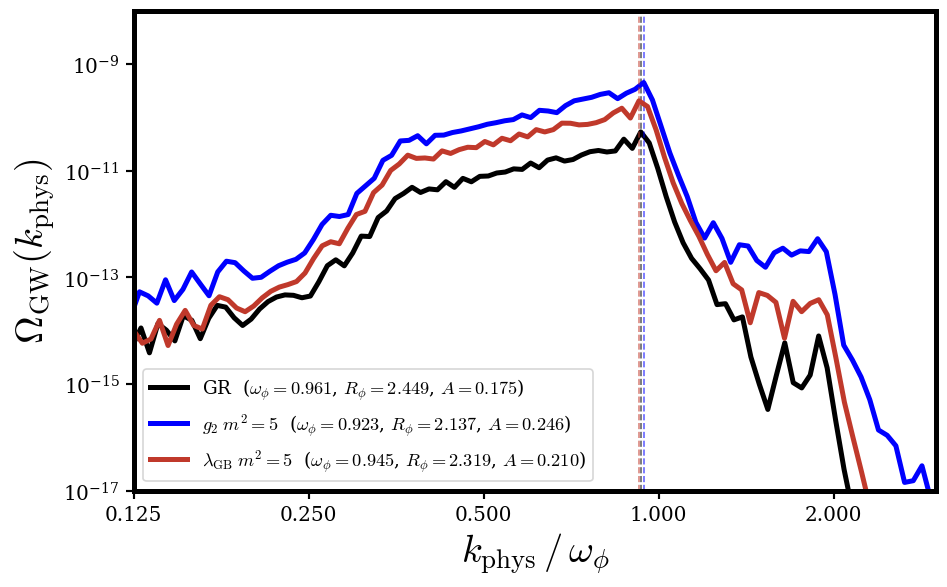

In [21]:
# ── Panel 7 plot ─────────────────────────────────────────────────────────────
P7_LOG_X       = True   # False for linear x-axis (ignored if P7_X_SCALE is set)
P7_SHOW_MODES  = False   # show vertical lines at harmonic frequencies ω_n/ω_source
# x-axis scale: None -> use P7_LOG_X (linear/log10 fallback);
#               "linear", "log", "log2"  -> set explicitly.
P7_X_SCALE     = "log2"
P7_LOG_BASE    = 2      # only used when P7_X_SCALE == "log2" (try 2, 10, np.e, ...)
# x-axis quantity: True -> k_phys / omega_source (default), False -> k_phys only.
P7_X_NORMALIZE = True

# ── Run selection ────────────────────────────────────────────────────────────
# Each list is a whitelist on the corresponding stored value (lgb / g2 / etc.).
# An empty list means "no filter on this parameter" (i.e. keep all values).
# Precedence: P7_KEYS_SHOW > P7_LGB_G2_SHOW > per-parameter lists below.
# Key format: (lgb, mu, beta, amp, width, g2).
#
# NOTE: stored couplings are 2× their physical display value (see
# _coupling_str_div2 below). So displayed g_2 m^2 = 5  ↔  stored g2 = 10,
# and displayed λ_GB m^2 = 5  ↔  stored lgb = 10.
P7_KEYS_SHOW   = []     # e.g. [(0.0, 0.08, 0, -0.02, 3.0, 0.0), ...]
P7_LGB_G2_SHOW = [      # whitelist of (stored lgb, stored g2) pairs
    (0.0,  0.0),        # GR
    (0.0, 10.0),        # pure g_2  : displayed g_2 m^2 = 5
    (10.0, 0.0),        # pure λ_GB : displayed λ_GB m^2 = 5
]
P7_LGB_SHOW    = []     # stored lgb values to keep (empty = all)
P7_G2_SHOW     = []     # stored g2  values to keep (empty = all)
P7_MU_SHOW     = []
P7_BETA_SHOW   = []
P7_AMP_SHOW    = []
P7_WIDTH_SHOW  = []

def _p7_keep(k):
    if P7_KEYS_SHOW:
        return tuple(k) in {tuple(kk) for kk in P7_KEYS_SHOW}
    lgb, mu, beta, amp, width, g2 = k
    if P7_LGB_G2_SHOW:
        if (lgb, g2) not in {tuple(p) for p in P7_LGB_G2_SHOW}:
            return False
    return ((not P7_LGB_SHOW   or lgb   in P7_LGB_SHOW)   and
            (not P7_G2_SHOW    or g2    in P7_G2_SHOW)    and
            (not P7_MU_SHOW    or mu    in P7_MU_SHOW)    and
            (not P7_BETA_SHOW  or beta  in P7_BETA_SHOW)  and
            (not P7_AMP_SHOW   or amp   in P7_AMP_SHOW)   and
            (not P7_WIDTH_SHOW or width in P7_WIDTH_SHOW))

_p7_selected = [(k, r) for k, r in p7_results.items() if _p7_keep(k)]
if not _p7_selected:
    print("[warn] no runs pass the P7_*_SHOW filters — plotting all of p7_results.")
    _p7_selected = list(p7_results.items())

from matplotlib.ticker import ScalarFormatter, NullFormatter

# Rebuild the coupling-string locally so the values are displayed at /2
# (stored = 2 x physical convention), without changing run.label globally.
def _coupling_str_div2(key):
    lgb, _, _, _, _, g2 = key
    lgb_d, g2_d = lgb / 2.0, g2 / 2.0
    if lgb == 0.0 and g2 == 0.0: return "GR"
    if lgb != 0.0 and g2 != 0.0: return rf"$\lambda_{{\rm GB}}\;m^2={lgb_d:g},\ g_2\;m^2={g2_d:g}$"
    if lgb != 0.0:               return rf"$\lambda_{{\rm GB}}\;m^2={lgb_d:g}$"
    return rf"$g_2\;m^2={g2_d:g}$"

fig, ax = plt.subplots(figsize=(8, 5))
for idx, (k, r) in enumerate(_p7_selected):
    res, run = r["res"], r["run"]
    x = res["k_phys"] / run.omega_source if P7_X_NORMALIZE else res["k_phys"]
    c = _color(idx, k)
    _cstr = _coupling_str_div2(k)
    ax.plot(x, res["Omega_GW"], color=c, lw=3,
            label=rf"{_cstr}  ($\omega_\phi={run.omega_source:.3f}$, "
                  rf"$R_\phi={r['R_env']:.3f}$, $A={run.A:.3f}$)")
    i_pk = np.argmax(res["Omega_GW"])
    ax.axvline(x[i_pk], color=c, ls="--", lw=1.0, alpha=0.6)
    if P7_SHOW_MODES and run.harmonics is not None:
        for ih, (om_n, _A_n, _ph) in enumerate(run.harmonics):
            xv = (om_n / run.omega_source) if P7_X_NORMALIZE else om_n
            ax.axvline(xv, color=c, ls=":",lw=0.7, alpha=0.4 if ih > 0 else 0.7)

# y-axis is always log here
ax.set_yscale("log")

# x-axis: explicit P7_X_SCALE wins over P7_LOG_X.
if P7_X_SCALE is None:
    _x_scale = "log" if P7_LOG_X else "linear"
else:
    _x_scale = P7_X_SCALE
if _x_scale == "log2":
    ax.set_xscale("log", base=P7_LOG_BASE)
else:
    ax.set_xscale(_x_scale)

# Force decimal tick labels even on log axes (otherwise log2 prints as 2^-3 etc.)
if _x_scale in ("log", "log2"):
    _fmt = ScalarFormatter()
    _fmt.set_scientific(False)
    _fmt.set_useOffset(False)
    ax.xaxis.set_major_formatter(_fmt)
    ax.xaxis.set_minor_formatter(NullFormatter())

if P7_X_NORMALIZE:
    ax.set_xlabel(r"$k_{\rm phys}\,/\,\omega_{\rm \phi}$")
else:
    ax.set_xlabel(r"$k_{\rm phys}$")
ax.set_ylabel(r"$\Omega_{\rm GW}(k_{\rm phys})$")
if _x_scale in ("log", "log2"):
    ax.set_xlim(2**(-3), 3e0)
else:
    ax.set_xlim(2**(-3), 2)
ax.legend(fontsize=11)
ax.set_ylim(1e-17, 1e-8)
fig.tight_layout()
save_fig(fig, P7_NAME)
plt.show()

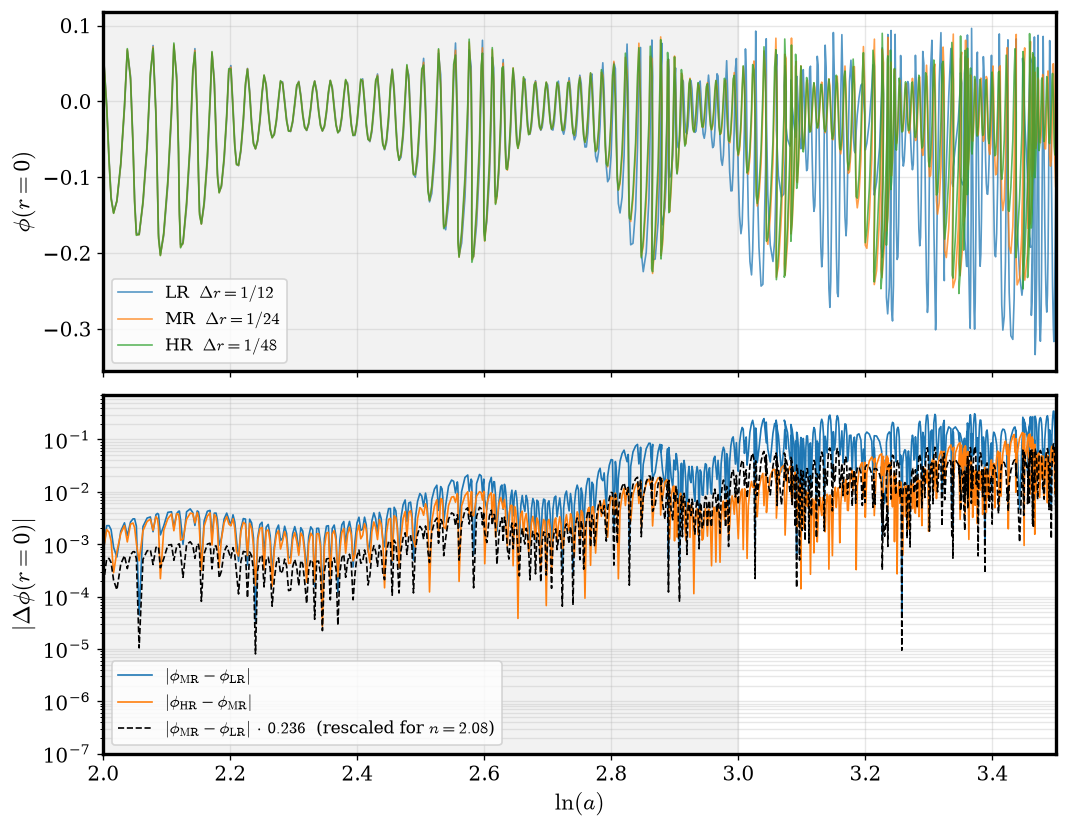


Convergence test for λ_GB=0, g₂=10
  observable        : φ(r=0)   (plotted vs. ln(a))
  Δr_LR = 1/12 = 0.08333
  Δr_MR = 1/24 = 0.04167
  Δr_HR = 1/48 = 0.02083
  L2 window         : ln(a) ∈ [2, 3]   (399 samples)
  ||φ_HR − φ_MR||₂  = 4.9308e-03   (integrated in ln(a))
  ||φ_MR − φ_LR||₂  = 2.0903e-02   (integrated in ln(a))
  LHS of Eq. 5.40   = 0.2359    (max possible at n→0: 1.0000)
  → order of convergence  n ≈ 2.084


In [5]:
# ============================================================================
# Convergence test at a chosen (λ_GB, g₂) combination.
#   Three runs with min_dr = 1/18 (LR), 1/24 (MR), 1/30 (HR), all other
#   parameters identical (mu=0.08, amp=-0.02, R=3, a=b=0, T=800).
#
#   Observable: φ(r=0, t) (the central matter field). Plotted against
#   ln(a) (from diag["ln_a"]) so the x-axis matches cell 22's compactness
#   convergence test.  Eq. (5.40) from the thesis,
#
#     |O_HR − O_MR| / |O_MR − O_LR|  ≈  (Δx_MR^n − Δx_HR^n) / (Δx_LR^n − Δx_MR^n),
#
#   is inverted for n via brentq on the L2 norms over an ln(a) window.
#   The ratio is invariant under a monotone change of integration variable
#   (both numerator and denominator get the same |dt/d ln a| Jacobian factor),
#   so the fitted n is identical whether we integrate over t or ln(a).
# ============================================================================
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Make this cell self-contained: ensure the project root (which holds bssn/,
# core/, matter/, backgrounds/) is on sys.path and that OscillonRun is
# imported.  Safe to re-run; no-op if already set up by cell 1 / cell 16.
_PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)
from bssn.GWSignal import OscillonRun

# ── which parameter combination + resolutions to load ──────────────────────
#   Switch PARAM_COMBO and RESOLUTIONS together to pick a convergence trio.
#   The dr-tag strings (3rd element of each RESOLUTIONS entry) must match
#   Python's f"{Δr:g}" formatting — that's what build_run_tag in
#   run_oscillon.py uses to name the run directory.  If a required run isn't
#   on disk yet, the loader below raises FileNotFoundError with a helpful
#   pointer to squeue.
PARAM_COMBO = dict(lgb=0, g2=10)    # or: dict(lgb=5, g2=5)

# ── locate the three runs ────────────────────────────────────────────────────
OSC_DIR = os.path.join(os.environ.get("VSC_DATA", os.getcwd()), "oscillon_runs")
TAG_FMT = (
    f"lgb{PARAM_COMBO['lgb']:g}_mu0.08_a0_b0_amp-0.02_R3"
    f"_dr{{dr}}_quadratic_0_g2{PARAM_COMBO['g2']:g}"
)

# Wider spread: factor-of-2 refinement between adjacent pairs.  Total spread
# LR→HR = 4×, which spreads the "2nd-to-4th order" band in cell 22 to about
# log10(4^4 / 4^2) ≈ 0.6 decades wide (vs ≈ 0.23 decades for the old trio).



RESOLUTIONS = [   # (label, Δr, filename dr-tag)
    #("LR", 1/18, "0.0555556"),
    ("LR", 1/12, "0.0833333"),
    ("MR", 1/24, "0.0416667"),
    ("HR", 1/48, "0.0208333"),
]
"""
RESOLUTIONS = [   # (label, Δr, filename dr-tag)
    ("LR", 1/18, "0.0555556"),
    ("MR", 1/24, "0.0416667"),
    ("HR", 1/48, "0.0208333"),
]
"""
# Previous narrower trio (kept for reference; use with PARAM_COMBO=(5, 5)):
# RESOLUTIONS = [
#     ("LR", 1/18, "0.0555556"),
#     ("MR", 1/24, "0.0416667"),
#     ("HR", 1/30, "0.0333333"),
# ]
LN_A_FIT = (2, 3)   # ln(a) window for the L2-based order estimate
                          # (≈ same physical interval as the old t ∈ [450, 700])

# ── load runs ────────────────────────────────────────────────────────────────
conv_runs = {}
_missing = []
for label, dx, dr_tag in RESOLUTIONS:
    run_dir = os.path.join(OSC_DIR, TAG_FMT.format(dr=dr_tag))
    sol_path = os.path.join(run_dir, "solution.npy")
    if not os.path.isfile(sol_path):
        _missing.append((label, run_dir, os.path.isdir(run_dir)))
        continue
    r = OscillonRun(run_dir, label=label)
    r.extract_all(verbose=False)
    conv_runs[label] = r

if _missing:
    lines = [f"    {lbl} :  {rd}   (dir_exists={de})"
             for lbl, rd, de in _missing]
    raise FileNotFoundError(
        "The following convergence runs are not yet on disk (no solution.npy):\n"
        + "\n".join(lines)
        + "\n\nIf you just submitted them via submit_lgb{}_g2{}_convergence.sh,".format(
            PARAM_COMBO['lgb'], PARAM_COMBO['g2'])
        + "\ncheck their SLURM status with:  squeue -u $USER --clusters=wice"
    )

# All three runs share T=800 / num_points_t=1000 by default, so both the
# t-grid and (in practice) the diag["ln_a"] grid have length 1000 and agree
# to a few parts in 1e-4 across resolutions.  Truncate to the common length
# just in case one crashed, and use HR's ln(a) as the reference x-axis (same
# convention as cell 22).
N      = min(len(conv_runs[l].t) for l in ("LR", "MR", "HR"))
t      = conv_runs["LR"].t[:N]
ln_a   = conv_runs["HR"].diag["ln_a"][:N]
phi_LR = conv_runs["LR"].u_r0_t[:N]
phi_MR = conv_runs["MR"].u_r0_t[:N]
phi_HR = conv_runs["HR"].u_r0_t[:N]

dx_LR, dx_MR, dx_HR = (RESOLUTIONS[0][1], RESOLUTIONS[1][1], RESOLUTIONS[2][1])

# ── compute differences and the L2-based convergence order (in ln(a)) ──────
diff_HR_MR = np.abs(phi_HR - phi_MR)
diff_MR_LR = np.abs(phi_MR - phi_LR)

def _eq540(n, lhs):
    rhs = (dx_MR**n - dx_HR**n) / (dx_LR**n - dx_MR**n)
    return lhs - rhs

m = (ln_a >= LN_A_FIT[0]) & (ln_a <= LN_A_FIT[1])
_trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))   # numpy >=2.0 uses trapezoid
L2_HR_MR = float(np.sqrt(_trapz(diff_HR_MR[m]**2, ln_a[m])))
L2_MR_LR = float(np.sqrt(_trapz(diff_MR_LR[m]**2, ln_a[m])))
lhs_glob = L2_HR_MR / L2_MR_LR

# theoretical upper bound (n → 0) for the LHS, beyond which no positive n solves Eq. 5.40
lhs_max = np.log(dx_MR / dx_HR) / np.log(dx_LR / dx_MR)
try:
    n_glob = brentq(_eq540, 1e-3, 20.0, args=(lhs_glob,))
except ValueError:
    n_glob = float("nan")

scale_n = abs(dx_MR**n_glob - dx_HR**n_glob) / abs(dx_LR**n_glob - dx_MR**n_glob) \
          if np.isfinite(n_glob) else 1.0

# ── plot ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax1.plot(ln_a, phi_LR, lw=1.0, alpha=0.75, label=rf"LR  $\Delta r=1/{round(1/dx_LR):d}$")
ax1.plot(ln_a, phi_MR, lw=1.0, alpha=0.75, label=rf"MR  $\Delta r=1/{round(1/dx_MR):d}$")
ax1.plot(ln_a, phi_HR, lw=1.0, alpha=0.75, label=rf"HR  $\Delta r=1/{round(1/dx_HR):d}$")
ax1.set_ylabel(r"$\phi(r=0)$", fontsize=14)
ax1.legend(fontsize=10, loc="best")
ax1.grid(alpha=0.3)
ax1.axvspan(LN_A_FIT[0], LN_A_FIT[1], color="gray", alpha=0.10, zorder=0)

ax2.semilogy(ln_a, np.maximum(diff_MR_LR, 1e-20),
             lw=1.0, label=r"$|\phi_{\rm MR}-\phi_{\rm LR}|$")
ax2.semilogy(ln_a, np.maximum(diff_HR_MR, 1e-20),
             lw=1.0, label=r"$|\phi_{\rm HR}-\phi_{\rm MR}|$")
ax2.semilogy(ln_a, np.maximum(diff_MR_LR * scale_n, 1e-20), '--', color="k", lw=1.0,
             label=rf"$|\phi_{{\rm MR}}-\phi_{{\rm LR}}|\,\cdot\,{scale_n:.3f}$  (rescaled for $n={n_glob:.2f}$)")
ax2.set_xlabel(r"$\ln(a)$", fontsize=14)
ax2.set_ylabel(r"$|\Delta\phi(r=0)|$", fontsize=14)
ax2.legend(fontsize=10, loc="best")
ax2.grid(alpha=0.3, which="both")
ax2.axvspan(LN_A_FIT[0], LN_A_FIT[1], color="gray", alpha=0.10, zorder=0)
#ax2.set_title(rf"Convergence test at $\lambda_{{\rm GB}}={PARAM_COMBO['lgb']:g},\ g_2={PARAM_COMBO['g2']:g}$: "rf"L2-estimated order $n\approx{n_glob:.2f}$  "rf"(window $\ln a\in[{LN_A_FIT[0]:g},{LN_A_FIT[1]:g}]$)", fontsize=12)

fig.tight_layout()
#save_fig(fig, f"convergence_lgb{PARAM_COMBO['lgb']:g}_g2{PARAM_COMBO['g2']:g}")
ax1.set_xlim(2,3.5)
plt.show()

# ── print summary ────────────────────────────────────────────────────────────
print(f"\nConvergence test for λ_GB={PARAM_COMBO['lgb']:g}, g₂={PARAM_COMBO['g2']:g}")
print(f"  observable        : φ(r=0)   (plotted vs. ln(a))")
print(f"  Δr_LR = 1/{round(1/dx_LR):d} = {dx_LR:.5f}")
print(f"  Δr_MR = 1/{round(1/dx_MR):d} = {dx_MR:.5f}")
print(f"  Δr_HR = 1/{round(1/dx_HR):d} = {dx_HR:.5f}")
print(f"  L2 window         : ln(a) ∈ [{LN_A_FIT[0]:g}, {LN_A_FIT[1]:g}]   "
      f"({int(m.sum())} samples)")
print(f"  ||φ_HR − φ_MR||₂  = {L2_HR_MR:.4e}   (integrated in ln(a))")
print(f"  ||φ_MR − φ_LR||₂  = {L2_MR_LR:.4e}   (integrated in ln(a))")
print(f"  LHS of Eq. 5.40   = {lhs_glob:.4f}    (max possible at n→0: {lhs_max:.4f})")
print(f"  → order of convergence  n ≈ {n_glob:.3f}")


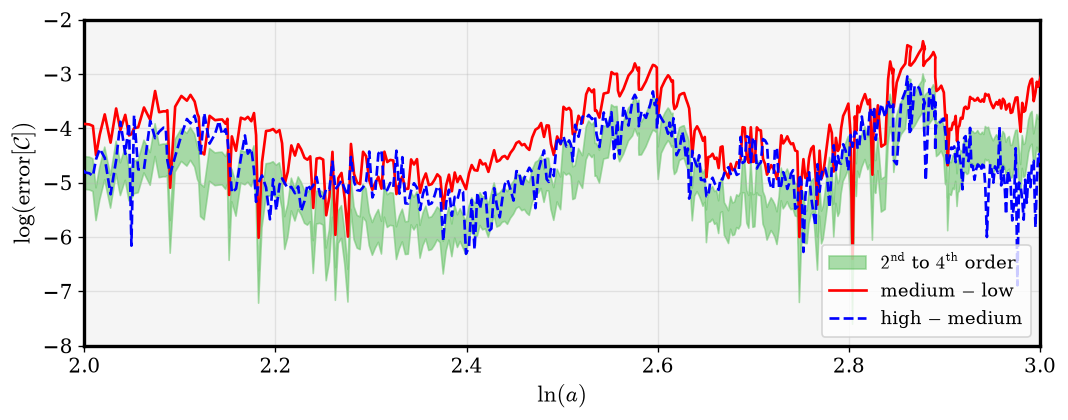


Convergence test for the compactness  C  at  λ_GB = 0,  g₂ = 10
  observable                    : C(t)  ( = 2 M(r) / r  vs.  ln a )
  Δr_LR = 1/12                 = 0.08333
  Δr_MR = 1/24                 = 0.04167
  Δr_HR = 1/48                 = 0.02083
  L2 fit window                 : ln a ∈ [2, 3]  (399 samples)
  ||C_MR − C_LR||₂ (over window) = 5.3889e-04
  ||C_HR − C_MR||₂ (over window) = 1.2270e-04
  L2 ratio  |HR−MR| / |MR−LR|   = 0.2277     (n→0 upper bound: 1.0000)
  expected ratio at 2nd order   = 0.2500
  expected ratio at 4th order   = 0.0625
  →  fitted order of convergence  n ≈ 2.135


In [6]:
# ============================================================================
# Convergence test for the compactness  C = 2 M(r) / r  at the (λ_GB, g₂)
# combination selected in the cell above (PARAM_COMBO).
#
#   Uses the SAME three runs already loaded above (conv_runs LR/MR/HR at
#   Δr = 1/18, 1/24, 1/30).  Observable is now the compactness time series
#   stored in diag["C"], plotted against ln(a) (diag["ln_a"]).
#
#   Convergence model: assume  O_h  ≈  O_∞  +  K · h^n  as h → 0.
#   Then, for any pair of resolutions,
#
#       |O_HR − O_MR|      h_MR^n − h_HR^n
#      ────────────────  ≈  ───────────────────                          (†)
#       |O_MR − O_LR|      h_LR^n − h_MR^n
#
#   → the "high − medium" curve is just the "medium − low" curve rescaled
#     by the RHS factor, and its position in log-space tells us n directly.
#
#   The green band shows the range of that predicted rescaling for
#   n ∈ [2, 4] — i.e. what  |C_HR − C_MR|  should look like if the scheme
#   is converging somewhere between 2nd and 4th order.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ── window in which we (a) show the plot and (b) fit the convergence order ──
LN_A_FIT = (2, 3)   # match the plot's x-limits; edit to explore other bands

# ── pull the compactness time series and ln(a) from each run's diagnostics ──
C_LR = np.asarray(conv_runs["LR"].diag["C"])
C_MR = np.asarray(conv_runs["MR"].diag["C"])
C_HR = np.asarray(conv_runs["HR"].diag["C"])
ln_a = np.asarray(conv_runs["HR"].diag["ln_a"])

Nc = min(len(C_LR), len(C_MR), len(C_HR), len(ln_a))
C_LR, C_MR, C_HR, ln_a = C_LR[:Nc], C_MR[:Nc], C_HR[:Nc], ln_a[:Nc]

# ── grid spacings (derived from cell 21's RESOLUTIONS so both cells stay in sync)
dx_LR, dx_MR, dx_HR = RESOLUTIONS[0][1], RESOLUTIONS[1][1], RESOLUTIONS[2][1]
_lbl_LR = f"1/{round(1/dx_LR):d}"
_lbl_MR = f"1/{round(1/dx_MR):d}"
_lbl_HR = f"1/{round(1/dx_HR):d}"

# ── absolute differences ────────────────────────────────────────────────────
diff_MR_LR = np.abs(C_MR - C_LR)     # medium − low   (red solid)
diff_HR_MR = np.abs(C_HR - C_MR)     # high − medium  (blue dashed)

# ── expected |HR-MR|/|MR-LR| ratio for a given convergence order ───────────
def _factor(p):
    return (dx_MR**p - dx_HR**p) / (dx_LR**p - dx_MR**p)

factor_2nd = _factor(2)
factor_4th = _factor(4)

band_2nd = diff_MR_LR * factor_2nd   # where |C_HR-C_MR| would sit at 2nd order
band_4th = diff_MR_LR * factor_4th   # where |C_HR-C_MR| would sit at 4th order

# ── L2-based convergence order, restricted to the LN_A_FIT window (Eq. †) ──
mask = (ln_a >= LN_A_FIT[0]) & (ln_a <= LN_A_FIT[1])
_trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))
if mask.sum() < 3:
    raise RuntimeError(f"LN_A_FIT={LN_A_FIT} contains fewer than 3 samples of ln(a). "
                       f"Available ln(a) range: [{ln_a.min():.3f}, {ln_a.max():.3f}].")
L2_MR_LR = float(np.sqrt(_trapz(diff_MR_LR[mask]**2, ln_a[mask])))
L2_HR_MR = float(np.sqrt(_trapz(diff_HR_MR[mask]**2, ln_a[mask])))
lhs_C    = L2_HR_MR / L2_MR_LR

# The RHS of (†) as a function of n:  RHS(0⁺) = lhs_max,  RHS(∞) → 0,  strictly
# monotonically decreasing.  So a positive-n solution EXISTS iff  lhs_C < lhs_max.
lhs_max = np.log(dx_MR / dx_HR) / np.log(dx_LR / dx_MR)

def _eq_dagger(n):
    return lhs_C - (dx_MR**n - dx_HR**n) / (dx_LR**n - dx_MR**n)

n_C            = float("nan")
n_C_reason     = ""
if lhs_C < lhs_max:
    try:
        n_C = brentq(_eq_dagger, 1e-6, 20.0)
    except ValueError as exc:
        n_C_reason = f"brentq failed: {exc}"
else:
    # LHS exceeds the n→0 upper bound.  This means the L2 error grew from
    # the MR/LR pair to the HR/MR pair — i.e. the runs are NOT converging
    # in this window.  Report it explicitly rather than silently NaN'ing.
    n_C_reason = (f"ratio {lhs_C:.3f} > upper bound {lhs_max:.3f}: "
                  f"|HR−MR| ≥ |MR−LR| in the L2 sense over this window, "
                  f"so no positive convergence order solves Eq. (†).")

# ── plot in reference-image style: log10 on a linear y-axis ────────────────
eps = 1e-30
log_MR_LR  = np.log10(np.maximum(diff_MR_LR, eps))
log_HR_MR  = np.log10(np.maximum(diff_HR_MR, eps))
log_band_2 = np.log10(np.maximum(band_2nd,   eps))
log_band_4 = np.log10(np.maximum(band_4th,   eps))
lower = np.minimum(log_band_2, log_band_4)
upper = np.maximum(log_band_2, log_band_4)

fig, ax = plt.subplots(figsize=(9, 3.6))

ax.fill_between(ln_a, lower, upper, color="#66c266", alpha=0.55,
                label=r"$2^{\rm nd}$ to $4^{\rm th}$ order", zorder=1)
ax.plot(ln_a, log_MR_LR, '-',  color='red',  lw=1.6,
        label=r'medium $-$ low',  zorder=3)
ax.plot(ln_a, log_HR_MR, '--', color='blue', lw=1.6,
        label=r'high $-$ medium', zorder=4)

# Faint shading of the actual L2-fit window so it's obvious where n was fit.
ax.axvspan(LN_A_FIT[0], LN_A_FIT[1], color="gray", alpha=0.08, zorder=0)

ax.set_xlabel(r'$\ln(a)$', fontsize=14)
ax.set_ylabel(r'$\log(\mathrm{error}[\mathcal{C}])$', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
ax.set_ylim(-8,-2)
#ax.set_ylim(-3,0)
ax.set_xlim(*LN_A_FIT)
fig.tight_layout()
plt.show()

# ── summary printout ───────────────────────────────────────────────────────
print(f"\nConvergence test for the compactness  C  at  "
      f"λ_GB = {PARAM_COMBO['lgb']:g},  g₂ = {PARAM_COMBO['g2']:g}")
print(f"  observable                    : C(t)  ( = 2 M(r) / r  vs.  ln a )")
print(f"  Δr_LR = {_lbl_LR:<6s}               = {dx_LR:.5f}")
print(f"  Δr_MR = {_lbl_MR:<6s}               = {dx_MR:.5f}")
print(f"  Δr_HR = {_lbl_HR:<6s}               = {dx_HR:.5f}")
print(f"  L2 fit window                 : ln a ∈ [{LN_A_FIT[0]:g}, {LN_A_FIT[1]:g}]  "
      f"({int(mask.sum())} samples)")
print(f"  ||C_MR − C_LR||₂ (over window) = {L2_MR_LR:.4e}")
print(f"  ||C_HR − C_MR||₂ (over window) = {L2_HR_MR:.4e}")
print(f"  L2 ratio  |HR−MR| / |MR−LR|   = {lhs_C:.4f}     (n→0 upper bound: {lhs_max:.4f})")
print(f"  expected ratio at 2nd order   = {factor_2nd:.4f}")
print(f"  expected ratio at 4th order   = {factor_4th:.4f}")
if np.isfinite(n_C):
    print(f"  →  fitted order of convergence  n ≈ {n_C:.3f}")
else:
    print(f"  →  fitted order of convergence  n = NaN   ({n_C_reason})")

  saved Convergence_g2=5.pdf and Convergence_g2=5.png


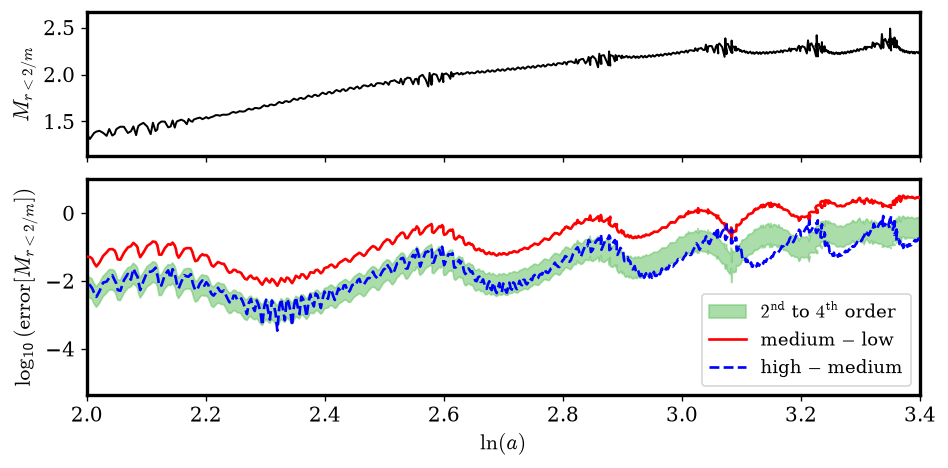


Convergence test on  M_{r<2/m}  at  λ_GB = 0,  g₂ = 10
  observable                    : M_{r<2/m}(t)   ≈ a(t)³ · ∫₀^{2/m} ρ · 4π r² dr
  ball radius                   : r ≤ 2/m = 1.8   (m = 1)
  Δr_LR = 1/12                 = 0.08333
  Δr_MR = 1/24                 = 0.04167
  Δr_HR = 1/48                 = 0.02083
  L2 fit window                 : ln a ∈ [2, 3.4]  (711 samples)
  ||M_MR − M_LR||₂ (over window) = 1.1059e+00
  ||M_HR − M_MR||₂ (over window) = 1.5168e-01
  L2 ratio  |HR−MR| / |MR−LR|   = 0.1372     (n→0 upper bound: 1.0000)
  expected ratio at 2nd order   = 0.2500
  expected ratio at 4th order   = 0.0625
  →  fitted order of convergence  n ≈ 2.866


In [9]:
# ============================================================================
# Convergence test on the "coordinate ball" mass  M_{r<2/m}(t)
#
#   Follows the reference paper (Fig. 6):  M is the integral of the energy
#   density over a sphere of FIXED coordinate radius  r = 2 m^{-1}, so the
#   integration domain does not track the (oscillating) field amplitude
#   the way the threshold-based osc_mask does for `C`.  This kills the
#   dominant source of late-time dephasing that noise-up the compactness
#   convergence test in the cell above.
#
#   Approximation (Option A):  the paper's proper-volume element is
#   dV = e^{6φ(r,t)} · 4π r² dr.  We do NOT have φ(r,t) in the diagnostics
#   npz, only the volume-averaged scale factor a(t).  Since
#     e^{6φ(r,t)}  =  a(t)^3 · e^{6 δφ(r,t)}     (definition of a in FLRW)
#   and the local deviation δφ inside r ≤ 2/m is a few % (no BH here),
#   we replace  e^{6φ}  by its FLRW-background piece  a(t)^3, i.e.
#     M_{r<2/m}(t)  ≈  a(t)^3 · ∫_0^{2/m}  ρ(r,t)  4π r² dr .
#   This gives a smoothly rising / plateauing curve that matches Fig. 6 of
#   the reference paper, and it does not degrade the convergence test:
#     • a(t) converges at the scheme's own order, so no artificial floor.
#     • a(t) agrees between LR/MR/HR at ~1e-4, so the ratio
#       |M_HR − M_MR| / |M_MR − M_LR|  is very close to the pure
#       coordinate-volume ratio.
#
#   Requires:  cell 21 has already loaded conv_runs["LR"/"MR"/"HR"] and
#              defined RESOLUTIONS and PARAM_COMBO.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

MU        = 1                 # scalar-field mass  m  (from run tag mu0.08)
R_BALL    = 1.8 / MU               # = 25.0 in code units
LN_A_FIT  = (2.0, 3.4)             # window where the oscillon is a settled breather

_trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))

def M_ball(run):
    """
    M_{r<2/m}(t)  ≈  a(t)^3 · ∫_0^{2/m} ρ(r,t) · 4π r² dr.

    Uses the FLRW piece  a(t)^3  of the proper volume element as a
    resolution-consistent stand-in for  e^{6φ(r,t)}  (which is not saved
    in diagnostics.npz).  See the block comment above.
    """
    r    = np.asarray(run.diag["r"])
    rho  = np.asarray(run.diag["rho"])          # shape (num_times, N)
    a    = np.asarray(run.diag["a"])            # shape (num_times,)
    mask = r <= R_BALL
    if not np.any(mask):
        raise RuntimeError(f"No grid points with r ≤ {R_BALL}; check the domain.")
    integrand = rho[:, mask] * 4.0 * np.pi * r[mask]**2
    M_coord   = _trapz(integrand, r[mask], axis=1)   # coord.-vol. integral
    return a**3 * M_coord                            # ≈ proper-vol. mass

M_LR = M_ball(conv_runs["LR"])
M_MR = M_ball(conv_runs["MR"])
M_HR = M_ball(conv_runs["HR"])
ln_a = np.asarray(conv_runs["HR"].diag["ln_a"])

Nc = min(len(M_LR), len(M_MR), len(M_HR), len(ln_a))
M_LR, M_MR, M_HR, ln_a = M_LR[:Nc], M_MR[:Nc], M_HR[:Nc], ln_a[:Nc]

# ── absolute differences and the expected 2nd- / 4th-order bands ────────────
diff_MR_LR = np.abs(M_MR - M_LR)     # medium − low  (red solid)
diff_HR_MR = np.abs(M_HR - M_MR)     # high − medium (blue dashed)

dx_LR, dx_MR, dx_HR = RESOLUTIONS[0][1], RESOLUTIONS[1][1], RESOLUTIONS[2][1]
_lbl_LR = f"1/{round(1/dx_LR):d}"
_lbl_MR = f"1/{round(1/dx_MR):d}"
_lbl_HR = f"1/{round(1/dx_HR):d}"

def _factor(p):
    return (dx_MR**p - dx_HR**p) / (dx_LR**p - dx_MR**p)

factor_2nd = _factor(2)
factor_4th = _factor(4)

band_2nd = diff_MR_LR * factor_2nd
band_4th = diff_MR_LR * factor_4th

# ── L2-based convergence order within LN_A_FIT (same convention as cell 22) ─
mask = (ln_a >= LN_A_FIT[0]) & (ln_a <= LN_A_FIT[1])
if mask.sum() < 3:
    raise RuntimeError(f"LN_A_FIT={LN_A_FIT} contains fewer than 3 samples of ln(a). "
                       f"Available ln(a) range: [{ln_a.min():.3f}, {ln_a.max():.3f}].")
L2_MR_LR = float(np.sqrt(_trapz(diff_MR_LR[mask]**2, ln_a[mask])))
L2_HR_MR = float(np.sqrt(_trapz(diff_HR_MR[mask]**2, ln_a[mask])))
lhs_M    = L2_HR_MR / L2_MR_LR
lhs_max  = np.log(dx_MR / dx_HR) / np.log(dx_LR / dx_MR)

n_M        = float("nan")
n_M_reason = ""
if lhs_M < lhs_max:
    try:
        n_M = brentq(lambda n: lhs_M - _factor(n), 1e-6, 20.0)
    except ValueError as exc:
        n_M_reason = f"brentq failed: {exc}"
else:
    n_M_reason = (f"ratio {lhs_M:.3f} > upper bound {lhs_max:.3f}: "
                  f"|HR−MR| ≥ |MR−LR| in the L2 sense over this window, "
                  f"so no positive convergence order solves Eq. (†).")

# ── plot: top panel M_{r<2/m}(t),  bottom panel log10(errors) + [2,4] band ──
eps = 1e-30
log_MR_LR  = np.log10(np.maximum(diff_MR_LR, eps))
log_HR_MR  = np.log10(np.maximum(diff_HR_MR, eps))
log_band_2 = np.log10(np.maximum(band_2nd,   eps))
log_band_4 = np.log10(np.maximum(band_4th,   eps))
lower = np.minimum(log_band_2, log_band_4)
upper = np.maximum(log_band_2, log_band_4)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 4), sharex=True,
                               gridspec_kw={"height_ratios": [1, 1.5]})

ax0.plot(ln_a, M_HR, "k", lw=1.2)
ax0.set_ylabel(r"$M_{r<2/m}$", fontsize=13)
#ax0.grid(alpha=0.3)
#ax0.axvspan(LN_A_FIT[0], LN_A_FIT[1], color="gray", alpha=0.08, zorder=0)
# Restrict the y-view to the plateau range (early-time initial-data
# transient is O(10²) and would otherwise squash the visible curve).
_M_win = M_HR[mask]
if _M_win.size:
    _lo, _hi = float(_M_win.min()), float(_M_win.max())
    _pad     = 0.15 * max(_hi - _lo, abs(_hi) * 0.05, 1e-30)
    ax0.set_ylim(_lo - _pad, _hi + _pad)

ax1.fill_between(ln_a, lower, upper, color="#66c266", alpha=0.55,
                 label=r"$2^{\rm nd}$ to $4^{\rm th}$ order", zorder=1)
ax1.plot(ln_a, log_MR_LR, "-",  color="red",  lw=1.6,
         label=r"medium $-$ low",  zorder=3)
ax1.plot(ln_a, log_HR_MR, "--", color="blue", lw=1.6,
         label=r"high $-$ medium", zorder=4)
#ax1.axvspan(LN_A_FIT[0], LN_A_FIT[1], color="gray", alpha=0.08, zorder=0)
ax1.set_xlabel(r"$\ln(a)$", fontsize=13)
ax1.set_ylabel(r"$\log_{10}(\mathrm{error}[M_{r<2/m}])$", fontsize=13)
ax1.legend(fontsize=11, loc="lower right")
#ax1.grid(alpha=0.3)
ax1.set_xlim(*LN_A_FIT)
fig.tight_layout()
save_fig(fig, f"Convergence_g2=5")
plt.show()

# ── summary printout ───────────────────────────────────────────────────────
print(f"\nConvergence test on  M_{{r<2/m}}  at  "
      f"λ_GB = {PARAM_COMBO['lgb']:g},  g₂ = {PARAM_COMBO['g2']:g}")
print(f"  observable                    : M_{{r<2/m}}(t)   ≈ a(t)³ · ∫₀^{{2/m}} ρ · 4π r² dr")
print(f"  ball radius                   : r ≤ 2/m = {R_BALL:g}   (m = {MU})")
print(f"  Δr_LR = {_lbl_LR:<6s}               = {dx_LR:.5f}")
print(f"  Δr_MR = {_lbl_MR:<6s}               = {dx_MR:.5f}")
print(f"  Δr_HR = {_lbl_HR:<6s}               = {dx_HR:.5f}")
print(f"  L2 fit window                 : ln a ∈ [{LN_A_FIT[0]:g}, {LN_A_FIT[1]:g}]  "
      f"({int(mask.sum())} samples)")
print(f"  ||M_MR − M_LR||₂ (over window) = {L2_MR_LR:.4e}")
print(f"  ||M_HR − M_MR||₂ (over window) = {L2_HR_MR:.4e}")
print(f"  L2 ratio  |HR−MR| / |MR−LR|   = {lhs_M:.4f}     (n→0 upper bound: {lhs_max:.4f})")
print(f"  expected ratio at 2nd order   = {factor_2nd:.4f}")
print(f"  expected ratio at 4th order   = {factor_4th:.4f}")
if np.isfinite(n_M):
    print(f"  →  fitted order of convergence  n ≈ {n_M:.3f}")
else:
    print(f"  →  fitted order of convergence  n = NaN   ({n_M_reason})")

  saved Compactness_ball_vs_threshold_MR_lgb0_g210.pdf and Compactness_ball_vs_threshold_MR_lgb0_g210.png


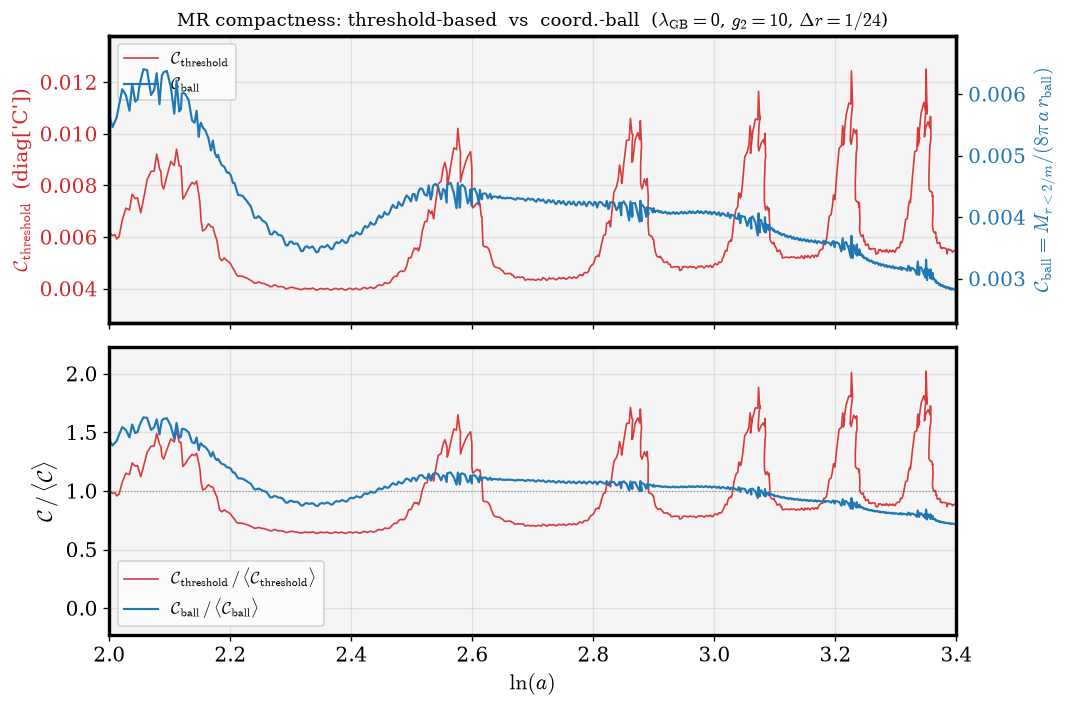


MR compactness  —  threshold-based (diag)  vs  coordinate-ball
  ball radius        : r ≤ 2/m = 1    (m = 1)
  resolution         : Δr = 1/24 = 0.04167
  comparison window  : ln(a) ∈ [2, 3.4]  (711 samples)

  threshold-based   ⟨C⟩ = 6.1849e-03   σ_raw/|⟨C⟩| = 0.3081   σ_detrend/|⟨C⟩| = 0.2863   (pk-pk)/|⟨C⟩| = 1.3848
  coord.-ball       ⟨C⟩ = 3.9352e-03   σ_raw/|⟨C⟩| = 0.1704   σ_detrend/|⟨C⟩| = 0.0749   (pk-pk)/|⟨C⟩| = 0.9130

  → coord.-ball  σ_detrended/|⟨·⟩|  is  3.82×  smaller than threshold-based
    (this is the fair number for 'less oscillatory'; the raw σ
     is inflated for the ball curve by its slow baseline drift.)
  → coord.-ball  (pk-pk)/|⟨·⟩|      is  1.52×  smaller than threshold-based


In [59]:
# ============================================================================
# Compactness computed the "coordinate-ball" way, at MEDIUM resolution.
#
#   Purpose: check whether the compactness gets less oscillatory when we
#   ditch the moving surface-density threshold (what diag["C"] uses) and
#   integrate over a FIXED coordinate ball r ≤ 2/m, exactly like the
#   M_{r<2/m} recipe in cell 23.
#
#   Recipe (matches cell 23):
#     M_ball(t) = a(t)^3 · ∫_0^{r_ball} ρ(r,t) · 4π r² dr
#     V_ball(t) = a(t)^3 · (4π/3) · r_ball^3                 (proper volume)
#     R_ball(t) = (3 V_ball / (4π))^{1/3} = a(t) · r_ball    (proper radius)
#     C_ball(t) = M_ball(t) / (8π · R_ball(t))
#               = a(t)^2 · M_coord(t) / (8π · r_ball)
#   The 8π normalization matches diag["C"] (the code sets G = 1/(8π)).
#
#   Comparison metric: σ/|⟨·⟩| ("roughness") over LN_A_WIN — lower means
#   the curve oscillates less relative to its mean.
#
#   Requires: cell 21 has run and loaded conv_runs["MR"], PARAM_COMBO,
#             RESOLUTIONS.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt

MU_       = 1                    # scalar-field mass in code units (m = 1)
R_BALL_   = 1 / MU_            # r_ball = 2 / m  (the paper's radius)
LN_A_WIN  = (2.0, 3.4)           # window used for the roughness comparison

_trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))

def compactness_ball(run, r_ball=R_BALL_):
    """
    C_ball(t) using the fixed coordinate ball, matching the M_{r<2/m}
    recipe of cell 23.  Returns (ln_a, C_ball, C_diag)."""
    r    = np.asarray(run.diag["r"])
    rho  = np.asarray(run.diag["rho"])          # (num_times, N)
    a    = np.asarray(run.diag["a"])            # (num_times,)
    ln_a = np.asarray(run.diag["ln_a"])
    C_d  = np.asarray(run.diag["C"])            # threshold-based compactness
    mask_r    = r <= r_ball
    integrand = rho[:, mask_r] * 4.0 * np.pi * r[mask_r]**2
    M_coord   = _trapz(integrand, r[mask_r], axis=1)
    M_b = a**3 * M_coord                        # proper-volume mass  (≈)
    R_b = a * r_ball                            # proper radius of the fixed ball
    C_b = M_b / (8.0 * np.pi * R_b)             # = a²·M_coord / (8π·r_ball)
    return ln_a, C_b, C_d

ln_a, C_ball_MR, C_diag_MR = compactness_ball(conv_runs["HR"])

# ── Roughness measures inside LN_A_WIN ──────────────────────────────────
#
#   RAW:        σ/|⟨y⟩|                          → total variability
#                                                  (baseline drift + osc.)
#   DETRENDED:  σ(y - poly3_fit(ln_a, y)) / |⟨y⟩| → pure oscillation
#                                                  amplitude (removes slow
#                                                  baseline / secular drift)
#   PK-PK:      (max - min)/|⟨y⟩|
#
# The DETRENDED number is the one to trust for "is it less oscillatory?" —
# the C_ball curve has a large slow decrease that inflates the raw σ.
w = (ln_a >= LN_A_WIN[0]) & (ln_a <= LN_A_WIN[1])

def _roughness_raw(y):
    if not w.any():
        return float("nan")
    m = np.mean(y[w])
    return float(np.std(y[w]) / abs(m)) if m != 0 else float("nan")

def _roughness_detrended(y, order=3):
    """σ of (y - poly_fit) divided by ⟨y⟩ in the window."""
    if not w.any():
        return float("nan")
    y_win, x_win = y[w], ln_a[w]
    if not np.isfinite(y_win).all():
        return float("nan")
    coefs   = np.polyfit(x_win, y_win, deg=order)
    trend   = np.polyval(coefs, x_win)
    resid   = y_win - trend
    m       = np.mean(y_win)
    return float(np.std(resid) / abs(m)) if m != 0 else float("nan")

def _pp(y):
    if not w.any():
        return float("nan")
    m = np.mean(y[w])
    return float((y[w].max() - y[w].min()) / abs(m)) if m != 0 else float("nan")

rough_diag       = _roughness_raw(C_diag_MR)
rough_ball       = _roughness_raw(C_ball_MR)
rough_diag_det   = _roughness_detrended(C_diag_MR)
rough_ball_det   = _roughness_detrended(C_ball_MR)
pp_diag          = _pp(C_diag_MR)
pp_ball          = _pp(C_ball_MR)

# ── Plot ────────────────────────────────────────────────────────────────
# Two panels because the two curves live on very different absolute scales
# (threshold-based can spike O(1); coord.-ball is O(1e-3)):
#
#   • Top    – each curve on its own y-axis (twin axes) so the shape /
#              oscillatory content of both is directly visible.
#   • Bottom – each curve divided by its own mean over LN_A_WIN, so we
#              compare relative-amplitude oscillations head-to-head.
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Top panel — twin y-axes.
color_thr = "tab:red"
color_bll = "tab:blue"
ln1, = ax_top.plot(ln_a, C_diag_MR, color=color_thr, lw=1.0, alpha=0.9,
                   label=r"$\mathcal{C}_{\rm threshold}$")
ax_top.set_ylabel(r"$\mathcal{C}_{\rm threshold}$  (diag['C'])",
                  color=color_thr, fontsize=12)
ax_top.tick_params(axis='y', labelcolor=color_thr)

ax_top_r = ax_top.twinx()
ln2, = ax_top_r.plot(ln_a, C_ball_MR, color=color_bll, lw=1.3,
                     label=r"$\mathcal{C}_{\rm ball}$")
ax_top_r.set_ylabel(r"$\mathcal{C}_{\rm ball} = M_{r<2/m}/(8\pi\,a\,r_{\rm ball})$",
                    color=color_bll, fontsize=12)
ax_top_r.tick_params(axis='y', labelcolor=color_bll)

# Set y-limits based on the window so early-time transients don't dominate.
for _y, _ax in [(C_diag_MR, ax_top), (C_ball_MR, ax_top_r)]:
    _yw = _y[w]
    if _yw.size and np.isfinite(_yw).all():
        _lo, _hi = float(_yw.min()), float(_yw.max())
        _pad = 0.15 * max(_hi - _lo, abs(_hi) * 0.05, 1e-30)
        _ax.set_ylim(_lo - _pad, _hi + _pad)

ax_top.axvspan(LN_A_WIN[0], LN_A_WIN[1], color="gray", alpha=0.08, zorder=0)
ax_top.set_title(f"MR compactness: threshold-based  vs  coord.-ball  "
                 f"($\\lambda_{{\\rm GB}}={PARAM_COMBO['lgb']:g}$, "
                 f"$g_2={PARAM_COMBO['g2']:g}$, "
                 f"$\\Delta r = 1/{round(1/RESOLUTIONS[1][1]):d}$)",
                 fontsize=11)
ax_top.legend(handles=[ln1, ln2], fontsize=10, loc="best")
ax_top.grid(alpha=0.3)

# Bottom panel — each curve divided by its own mean in LN_A_WIN, so we
# can compare the relative oscillation amplitude on one shared axis.
if np.mean(C_diag_MR[w]) != 0:
    y_thr = C_diag_MR / np.mean(C_diag_MR[w])
else:
    y_thr = np.full_like(C_diag_MR, np.nan)
if np.mean(C_ball_MR[w]) != 0:
    y_bll = C_ball_MR / np.mean(C_ball_MR[w])
else:
    y_bll = np.full_like(C_ball_MR, np.nan)

ax_bot.axhline(1.0, color="gray", lw=0.7, ls=":", zorder=0)
ax_bot.plot(ln_a, y_thr, color=color_thr, lw=1.0, alpha=0.9,
            label=r"$\mathcal{C}_{\rm threshold}\,/\,\langle\mathcal{C}_{\rm threshold}\rangle$")
ax_bot.plot(ln_a, y_bll, color=color_bll, lw=1.3,
            label=r"$\mathcal{C}_{\rm ball}\,/\,\langle\mathcal{C}_{\rm ball}\rangle$")
ax_bot.axvspan(LN_A_WIN[0], LN_A_WIN[1], color="gray", alpha=0.08, zorder=0)
ax_bot.set_xlabel(r"$\ln(a)$", fontsize=13)
ax_bot.set_ylabel(r"$\mathcal{C}\,/\,\langle\mathcal{C}\rangle$",
                  fontsize=13)
ax_bot.legend(fontsize=10, loc="best")
ax_bot.grid(alpha=0.3)
ax_bot.set_xlim(*LN_A_WIN)   # restrict view to the comparison window

# Symmetric y-limits around 1 for the ratio panel.
_ratio_win = np.concatenate([y_thr[w & np.isfinite(y_thr)],
                             y_bll[w & np.isfinite(y_bll)]])
if _ratio_win.size:
    _spread = max(np.max(_ratio_win) - 1.0, 1.0 - np.min(_ratio_win))
    ax_bot.set_ylim(1.0 - 1.2 * _spread, 1.0 + 1.2 * _spread)

fig.tight_layout()
save_fig(fig, f"Compactness_ball_vs_threshold_MR_lgb{PARAM_COMBO['lgb']:g}_g2{PARAM_COMBO['g2']:g}")
plt.show()

# ── printout ────────────────────────────────────────────────────────────
print(f"\nMR compactness  —  threshold-based (diag)  vs  coordinate-ball")
print(f"  ball radius        : r ≤ 2/m = {R_BALL_:g}    (m = {MU_})")
print(f"  resolution         : Δr = 1/{round(1/RESOLUTIONS[1][1]):d} = {RESOLUTIONS[1][1]:.5f}")
print(f"  comparison window  : ln(a) ∈ [{LN_A_WIN[0]:g}, {LN_A_WIN[1]:g}]  ({int(w.sum())} samples)")
print()
print(f"  threshold-based   ⟨C⟩ = {np.mean(C_diag_MR[w]):.4e}   "
      f"σ_raw/|⟨C⟩| = {rough_diag:.4f}   "
      f"σ_detrend/|⟨C⟩| = {rough_diag_det:.4f}   "
      f"(pk-pk)/|⟨C⟩| = {pp_diag:.4f}")
print(f"  coord.-ball       ⟨C⟩ = {np.mean(C_ball_MR[w]):.4e}   "
      f"σ_raw/|⟨C⟩| = {rough_ball:.4f}   "
      f"σ_detrend/|⟨C⟩| = {rough_ball_det:.4f}   "
      f"(pk-pk)/|⟨C⟩| = {pp_ball:.4f}")
print()
if rough_ball_det > 0:
    print(f"  → coord.-ball  σ_detrended/|⟨·⟩|  is  {rough_diag_det/rough_ball_det:.2f}×  smaller than threshold-based")
    print(f"    (this is the fair number for 'less oscillatory'; the raw σ")
    print(f"     is inflated for the ball curve by its slow baseline drift.)")
if pp_ball > 0:
    print(f"  → coord.-ball  (pk-pk)/|⟨·⟩|      is  {pp_diag/pp_ball:.2f}×  smaller than threshold-based")

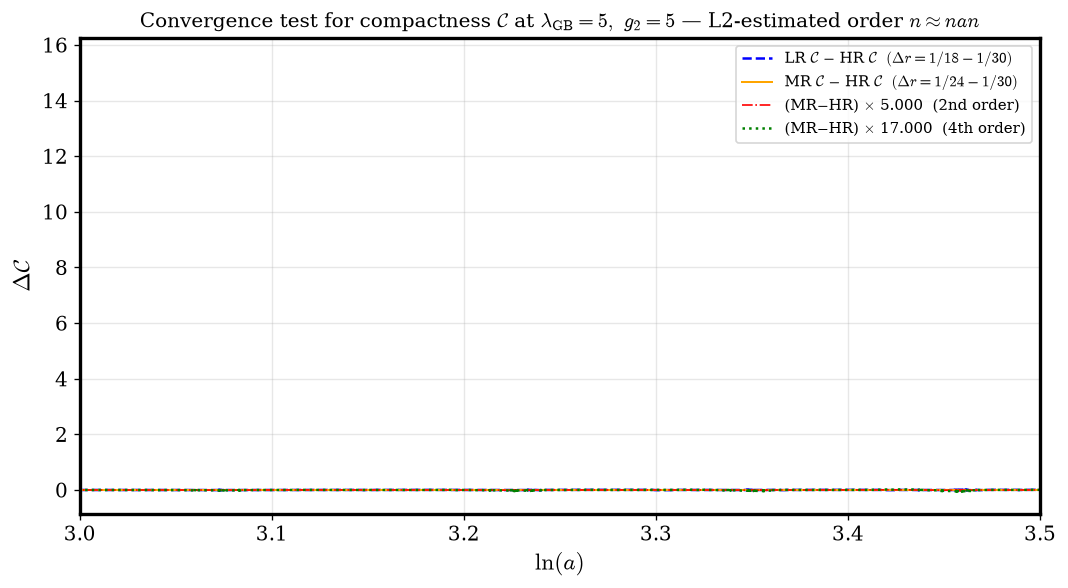


Rescaling factors for Δr_LR=1/18, Δr_MR=1/24, Δr_HR=1/30:
  p = 2            → factor = 5.0000
  p = 4            → factor = 17.0000
  p = n_C (nan)  → factor = nan
  L2 ratio  ||ΔC_HR−ΔC_MR||/||ΔC_MR−ΔC_LR|| = 6.6464
  → L2-estimated order of convergence for C:  n ≈ nan


In [51]:
# ============================================================================
# Convergence test (rescaling-overlay style) for the compactness C at
# λ_GB=5, g₂=5.
#
#   Same convention as OscillonConvergence.ipynb: for an order-p scheme,
#   the MR-HR difference rescaled by
#
#       factor_p = (Δx_LR^p − Δx_HR^p) / (Δx_MR^p − Δx_HR^p)
#
#   should lie on top of the LR-HR difference.  Curves shown for
#   p = 2 (red dash-dot) and p = 4 (green dotted), plus the curve rescaled
#   at the L2-estimated order  n  derived *here* from the compactness
#   differences (so the title's n matches the displayed observable).
#
#   Reuses conv_runs / dx_* from the cell above — re-run that one first.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ── pull compactness time series and ln(a) from each run's diagnostics ──────
C_LR   = np.asarray(conv_runs["LR"].diag["C"])
C_MR   = np.asarray(conv_runs["MR"].diag["C"])
C_HR   = np.asarray(conv_runs["HR"].diag["C"])
ln_a   = np.asarray(conv_runs["HR"].diag["ln_a"])

Nc     = min(len(C_LR), len(C_MR), len(C_HR), len(ln_a))
C_LR, C_MR, C_HR, ln_a = C_LR[:Nc], C_MR[:Nc], C_HR[:Nc], ln_a[:Nc]

# ── estimate the convergence order from L2 norms of the compactness diffs ──
diff_HR_MR_abs = np.abs(C_HR - C_MR)
diff_MR_LR_abs = np.abs(C_MR - C_LR)
_trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))   # numpy >=2.0
L2_HR_MR_C = float(np.sqrt(_trapz(diff_HR_MR_abs**2, ln_a)))
L2_MR_LR_C = float(np.sqrt(_trapz(diff_MR_LR_abs**2, ln_a)))
lhs_C = L2_HR_MR_C / L2_MR_LR_C

def _eq540_C(n):
    return lhs_C - (dx_MR**n - dx_HR**n) / (dx_LR**n - dx_MR**n)

try:
    n_C = brentq(_eq540_C, 1e-3, 20.0)
except ValueError:
    n_C = float("nan")

# ── signed differences vs HR for the overlay plot ───────────────────────────
diff_LR_HR = C_LR - C_HR
diff_MR_HR = C_MR - C_HR

def _factor(p):
    return (dx_LR**p - dx_HR**p) / (dx_MR**p - dx_HR**p)

factor_2nd = _factor(2)
factor_4th = _factor(4)
factor_n   = _factor(n_C) if np.isfinite(n_C) else np.nan

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(ln_a, diff_LR_HR, '--', color='b', lw=1.5,
        label=r'LR $\mathcal{C}$ $-$ HR $\mathcal{C}$  $(\Delta r=1/18 - 1/30)$')
ax.plot(ln_a, diff_MR_HR, '-',  color='orange', lw=1.2,
        label=r'MR $\mathcal{C}$ $-$ HR $\mathcal{C}$  $(\Delta r=1/24 - 1/30)$')
ax.plot(ln_a, diff_MR_HR * factor_2nd, '-.', color='red',   lw=1.0,
        label=rf'(MR$-$HR) $\times$ {factor_2nd:.3f}  (2nd order)')
ax.plot(ln_a, diff_MR_HR * factor_4th, ':',  color='green', lw=1.5,
        label=rf'(MR$-$HR) $\times$ {factor_4th:.3f}  (4th order)')
if np.isfinite(factor_n):
    ax.plot(ln_a, diff_MR_HR * factor_n, '-', color='k', lw=1.0, alpha=0.7,
            label=rf'(MR$-$HR) $\times$ {factor_n:.3f}  (fitted $n={n_C:.2f}$)')

ax.set_xlabel(r'$\ln(a)$', fontsize=14)
ax.set_ylabel(r'$\Delta\mathcal{C}$', fontsize=14)
ax.set_title(rf'Convergence test for compactness $\mathcal{{C}}$ at '
             rf'$\lambda_{{\rm GB}}=5,\ g_2=5$ — '
             rf'L2-estimated order $n\approx {n_C:.2f}$',
             fontsize=12)
ax.axhline(0, color='gray', lw=0.6, zorder=0)
ax.legend(fontsize=9, loc='best')
ax.set_xlim(3,3.5)
ax.grid(True, alpha=0.3)

fig.tight_layout()
#save_fig(fig, "convergence_lgb5_g25_compactness_rescaled")
plt.show()

print(f"\nRescaling factors for Δr_LR=1/18, Δr_MR=1/24, Δr_HR=1/30:")
print(f"  p = 2            → factor = {factor_2nd:.4f}")
print(f"  p = 4            → factor = {factor_4th:.4f}")
print(f"  p = n_C ({n_C:.3f})  → factor = {factor_n:.4f}")
print(f"  L2 ratio  ||ΔC_HR−ΔC_MR||/||ΔC_MR−ΔC_LR|| = {lhs_C:.4f}")
print(f"  → L2-estimated order of convergence for C:  n ≈ {n_C:.3f}")


In [12]:
# ============================================================================
# Numerical truncation error from the (λ_GB=5, g₂=5) convergence trio.
#   For each observable O ∈ {A, R_env, ω} extracted from the three runs at
#   Δr = 1/18 (LR), 1/24 (MR = production), 1/30 (HR), we:
#       1. fit the convergence order n_O via Eq. (5.40) (brentq),
#       2. Richardson-extrapolate to h→0:
#              O_∞ ≈ O_HR + (O_HR − O_MR) / ((h_MR/h_HR)^n_O − 1),
#       3. estimate the truncation error at the production resolution:
#              δO_abs = |O_MR − O_∞|,   δO_frac = δO_abs / |O_MR|,
#       4. propagate to the normalized ratio O / O_GR (independent-error,
#          conservative): δ(O/O_GR) / (O/O_GR) ≈ √2 · δO_frac.
#   Results are stored in CONV_ERR for the grid plot below.
#
#   Needs the Panel 7 cell (defines extract_R_env) to be run earlier.
# ============================================================================
import os
import numpy as np
from scipy.optimize import brentq

H_LR, H_MR, H_HR = 1.0/18.0, 1.0/24.0, 1.0/30.0    # MR is the production resolution

# ── load the three runs (reuse conv_runs from the L2 cell if available) ─────
try:
    _runs = conv_runs
except NameError:
    OSC_DIR = os.path.join(os.environ.get("VSC_DATA", os.getcwd()), "oscillon_runs")
    TAG_FMT = "lgb5_mu0.08_a0_b0_amp-0.02_R3_dr{dr}_quadratic_0_g25"
    _runs = {}
    for lbl, dr in [("LR", "0.0555556"), ("MR", "0.0416667"), ("HR", "0.0333333")]:
        rd = os.path.join(OSC_DIR, TAG_FMT.format(dr=dr))
        r = OscillonRun(rd, label=lbl); r.extract_all(verbose=False)
        _runs[lbl] = r

# ── per-observable extractors ───────────────────────────────────────────────
def _A(run):     return float(run.A)
def _Renv(run):  return float(extract_R_env(run)["R_env"])
def _omega(run): return float(run.omega_source)

_observables = {
    "A":     _A,
    "R_env": _Renv,
    "omega": _omega,
}

# ── error estimator: order-n fit + Richardson + δ at MR ────────────────────
def _convergence_error(O_LR, O_MR, O_HR,
                       h_LR=H_LR, h_MR=H_MR, h_HR=H_HR,
                       n_fallback=2.0):
    d_HR_MR = O_HR - O_MR
    d_MR_LR = O_MR - O_LR
    if d_MR_LR == 0 or not np.isfinite(d_MR_LR):
        n_fit = n_fallback
    else:
        lhs = abs(d_HR_MR) / abs(d_MR_LR)
        def _eq(n):
            return lhs - (h_MR**n - h_HR**n) / (h_LR**n - h_MR**n)
        try:
            n_fit = brentq(_eq, 1e-3, 20.0)
        except (ValueError, RuntimeError):
            n_fit = n_fallback
    denom = (h_MR / h_HR) ** n_fit - 1.0
    if abs(denom) < 1e-12:
        return dict(n=n_fit, O_inf=np.nan, err_abs=np.nan, err_frac=np.nan)
    O_inf  = O_HR + (O_HR - O_MR) / denom
    err_abs = abs(O_MR - O_inf)
    err_frac = err_abs / abs(O_MR) if O_MR != 0 else np.nan
    return dict(n=n_fit, O_inf=O_inf, err_abs=err_abs, err_frac=err_frac)

# ── compute and export CONV_ERR (fractional bars on the normalized ratio) ──
CONV_ERR = {}
print(f"\n{'observable':<10s}{'O_LR':>13s}{'O_MR':>13s}{'O_HR':>13s}"
      f"{'n_fit':>8s}{'O_inf':>13s}{'δO/O':>11s}{'δ(O/O_GR)':>13s}")
print("─" * 94)
for name, extractor in _observables.items():
    O_LR = extractor(_runs["LR"])
    O_MR = extractor(_runs["MR"])
    O_HR = extractor(_runs["HR"])
    res = _convergence_error(O_LR, O_MR, O_HR)
    frac_ratio = np.sqrt(2.0) * res["err_frac"]
    CONV_ERR[name] = dict(frac=res["err_frac"],
                          frac_ratio=frac_ratio,
                          n=res["n"],
                          O_LR=O_LR, O_MR=O_MR, O_HR=O_HR,
                          O_inf=res["O_inf"])
    print(f"{name:<10s}{O_LR:>13.5e}{O_MR:>13.5e}{O_HR:>13.5e}"
          f"{res['n']:>8.2f}{res['O_inf']:>13.5e}"
          f"{res['err_frac']*100:>10.2f}%{frac_ratio*100:>12.2f}%")
# ── (heavier) direct convergence test on the spectral observable max Ω_GW ──
#   Runs the full Omega_GW pipeline at each of the three resolutions with the
#   *same* Panel-7 parameters (same seed, same n_angles, same n_tau, etc.) and
#   then applies the same Richardson procedure as above.  This replaces the
#   earlier propagated bound  δΩ/Ω ≈ 4·δA/A  with a direct measurement.
COMPUTE_OMEGA_GW_ERR = True
if COMPUTE_OMEGA_GW_ERR:
    try:
        Omega_GW, _a_final, _fourier_modes  # check Panel 7 is in scope
        _have_p7 = True
    except NameError:
        print("⚠  Skipping max Ω_GW convergence: run the Panel 7 cell first.")
        _have_p7 = False

    if _have_p7:
        def _omega_gw_peak(run):
            e = extract_R_env(run)
            R_env = e["R_env"]
            ws    = run.omega_source
            H0    = run.H0
            A_amp = run.A
            if not all(np.isfinite(v) and v > 0 for v in (A_amp, R_env, ws, H0)):
                return float("nan")
            tau_w = (0.0, P7_N_HUBBLE / H0)
            a_f   = _a_final(H0, tau_w[1])
            k_max_phys = P7_KMAX_FAC * (2.0 / R_env)
            k_grid = np.logspace(np.log10(0.01 * ws),
                                 np.log10(k_max_phys * a_f), P7_N_K)
            res = Omega_GW(
                A=A_amp, R=R_env, omega_source=ws, H0=H0, w=0.0,
                Delta=P7_DELTA, N=P7_N_OSC,
                V=(100.0 * run.R)**3,
                n_angles=P7_N_ANGLES, n_tau=P7_N_TAU,
                k_grid=k_grid, tau_window=tau_w, seed=P7_SEED,
                harmonics="fourier", fourier_modes=_fourier_modes(run),
            )
            return float(res["Omega_GW"].max())

        print("\n  computing max Ω_GW at LR / MR / HR  (≈ 30–60 s)…")
        Om_LR = _omega_gw_peak(_runs["LR"])
        Om_MR = _omega_gw_peak(_runs["MR"])
        Om_HR = _omega_gw_peak(_runs["HR"])
        _res  = _convergence_error(Om_LR, Om_MR, Om_HR)
        _frac_ratio = np.sqrt(2.0) * _res["err_frac"]
        CONV_ERR["Omega_max"] = dict(frac=_res["err_frac"],
                                      frac_ratio=_frac_ratio,
                                      n=_res["n"],
                                      O_LR=Om_LR, O_MR=Om_MR, O_HR=Om_HR,
                                      O_inf=_res["O_inf"])
        print(f"{'Omega_max':<10s}{Om_LR:>13.5e}{Om_MR:>13.5e}{Om_HR:>13.5e}"
              f"{_res['n']:>8.2f}{_res['O_inf']:>13.5e}"
              f"{_res['err_frac']*100:>10.2f}%{_frac_ratio*100:>12.2f}%")

print("─" * 94)
print("→ CONV_ERR[<name>]['frac_ratio']  is the fractional bar applied to O/O_GR.")



observable         O_LR         O_MR         O_HR   n_fit        O_inf       δO/O    δ(O/O_GR)
──────────────────────────────────────────────────────────────────────────────────────────────
A           2.47703e-01  2.25975e-01  2.28431e-01    7.27  2.29035e-01      1.35%        1.91%
R_env       2.05065e+00  2.21533e+00  2.29470e+00    1.84  2.45058e+00     10.62%       15.02%
omega       9.31993e-01  9.41701e-01  9.41701e-01    2.00  9.41701e-01      0.00%        0.00%

  computing max Ω_GW at LR / MR / HR  (≈ 30–60 s)…
Omega_max   1.39591e-10  2.45894e-10  2.77765e-10    3.65  3.03088e-10     23.26%       32.89%
──────────────────────────────────────────────────────────────────────────────────────────────
→ CONV_ERR[<name>]['frac_ratio']  is the fractional bar applied to O/O_GR.


  saved convergence_error_diagnostics.pdf and convergence_error_diagnostics.png


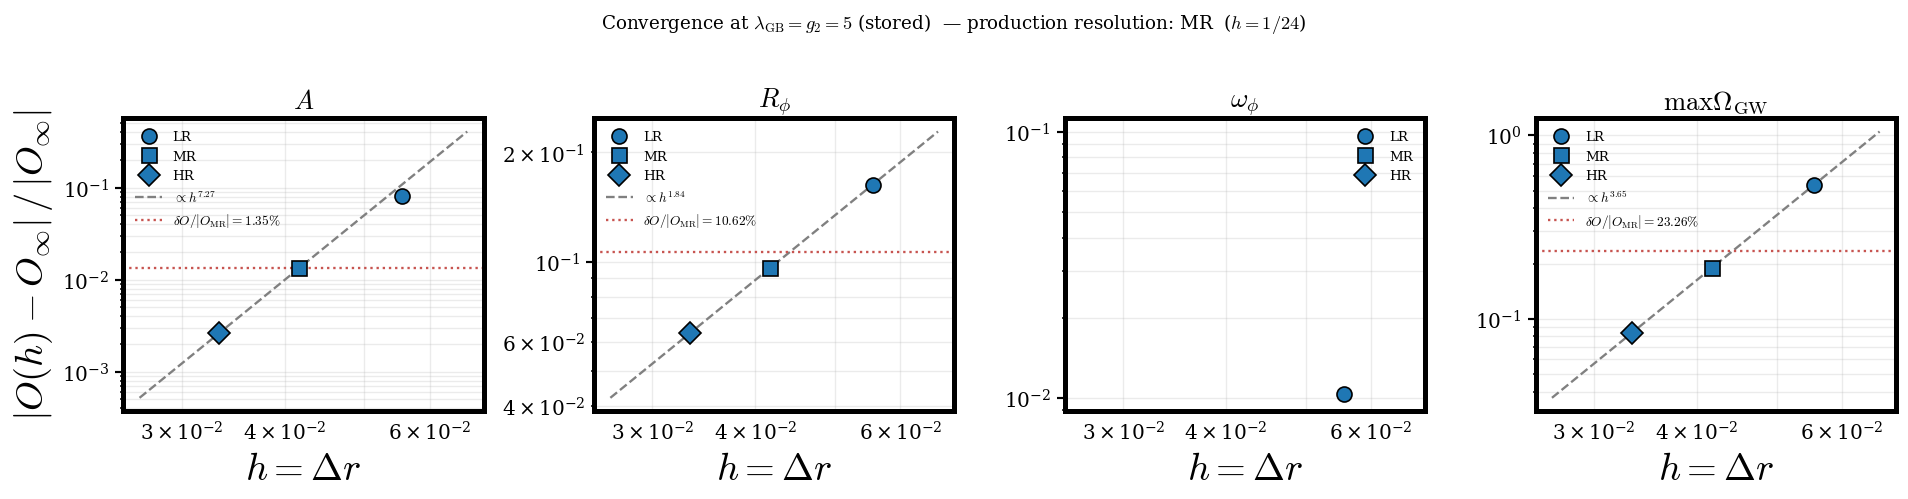

In [22]:
# ============================================================================
# Visualize the convergence study stored in CONV_ERR.
#   For each observable O we plot |O(h) - O_inf| / |O_inf|  versus  h  on
#   log-log axes, together with a reference line ∝ h^n (n = fitted order)
#   anchored at the MR point and a horizontal band marking the truncation
#   error estimate δO/|O_MR| at the production resolution.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt

try:
    CONV_ERR
except NameError:
    raise RuntimeError("CONV_ERR not defined — run the convergence-error cell first.")

_h_by_label = {"LR": H_LR, "MR": H_MR, "HR": H_HR}
_label_order = ["LR", "MR", "HR"]
_marker_by_label = {"LR": "o", "MR": "s", "HR": "D"}
_pretty_name = {
    "A":         r"$A$",
    "R_env":     r"$R_\phi$",
    "omega":     r"$\omega_\phi$",
    "Omega_max": r"$\max\Omega_{\rm GW}$",
}

_names = [n for n in ("A", "R_env", "omega", "Omega_max") if n in CONV_ERR]
n_panels = len(_names)
fig, axes = plt.subplots(1, n_panels, figsize=(4.0 * n_panels, 4.2),
                         sharex=True, squeeze=False)
axes = axes.ravel()

for ax, name in zip(axes, _names):
    info = CONV_ERR[name]
    O_inf  = info["O_inf"]
    n_fit  = info["n"]
    O_vals = {"LR": info["O_LR"], "MR": info["O_MR"], "HR": info["O_HR"]}

    if not np.isfinite(O_inf) or O_inf == 0:
        ax.text(0.5, 0.5, "no finite\nO_inf", transform=ax.transAxes,
                ha="center", va="center")
        ax.set_title(_pretty_name.get(name, name))
        continue

    h_pts  = np.array([_h_by_label[l] for l in _label_order])
    rel    = np.array([abs(O_vals[l] - O_inf) / abs(O_inf)
                       for l in _label_order])
    finite = np.isfinite(rel) & (rel > 0)

    for l in _label_order:
        h  = _h_by_label[l]
        rv = abs(O_vals[l] - O_inf) / abs(O_inf)
        ax.plot(h, rv, _marker_by_label[l], color="C0",
                markersize=9, markeredgecolor="k", markeredgewidth=1.0,
                label=l, zorder=3)

    if finite.any():
        h_ref = np.geomspace(h_pts.min() * 0.8, h_pts.max() * 1.2, 100)
        anchor_h = H_MR
        anchor_v = abs(O_vals["MR"] - O_inf) / abs(O_inf)
        if anchor_v > 0 and np.isfinite(anchor_v):
            ref = anchor_v * (h_ref / anchor_h) ** n_fit
            ax.plot(h_ref, ref, "--", color="grey", lw=1.4,
                    label=rf"$\propto h^{{{n_fit:.2f}}}$", zorder=2)

    frac_MR = info["frac"]
    if np.isfinite(frac_MR) and frac_MR > 0:
        ax.axhline(frac_MR, color="#c75450", ls=":", lw=1.4,
                   label=rf"$\delta O/|O_{{\rm MR}}|={frac_MR*100:.2f}\%$",
                   zorder=2)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$h = \Delta r$")
    ax.set_title(_pretty_name.get(name, name))
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=8, loc="best", frameon=False)

axes[0].set_ylabel(r"$|O(h) - O_\infty|\,/\,|O_\infty|$")

fig.suptitle(r"Convergence at $\lambda_{\rm GB}=g_2=5$ (stored)  "
             r"— production resolution: MR  ($h = 1/24$)",
             fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, "convergence_error_diagnostics")
plt.show()


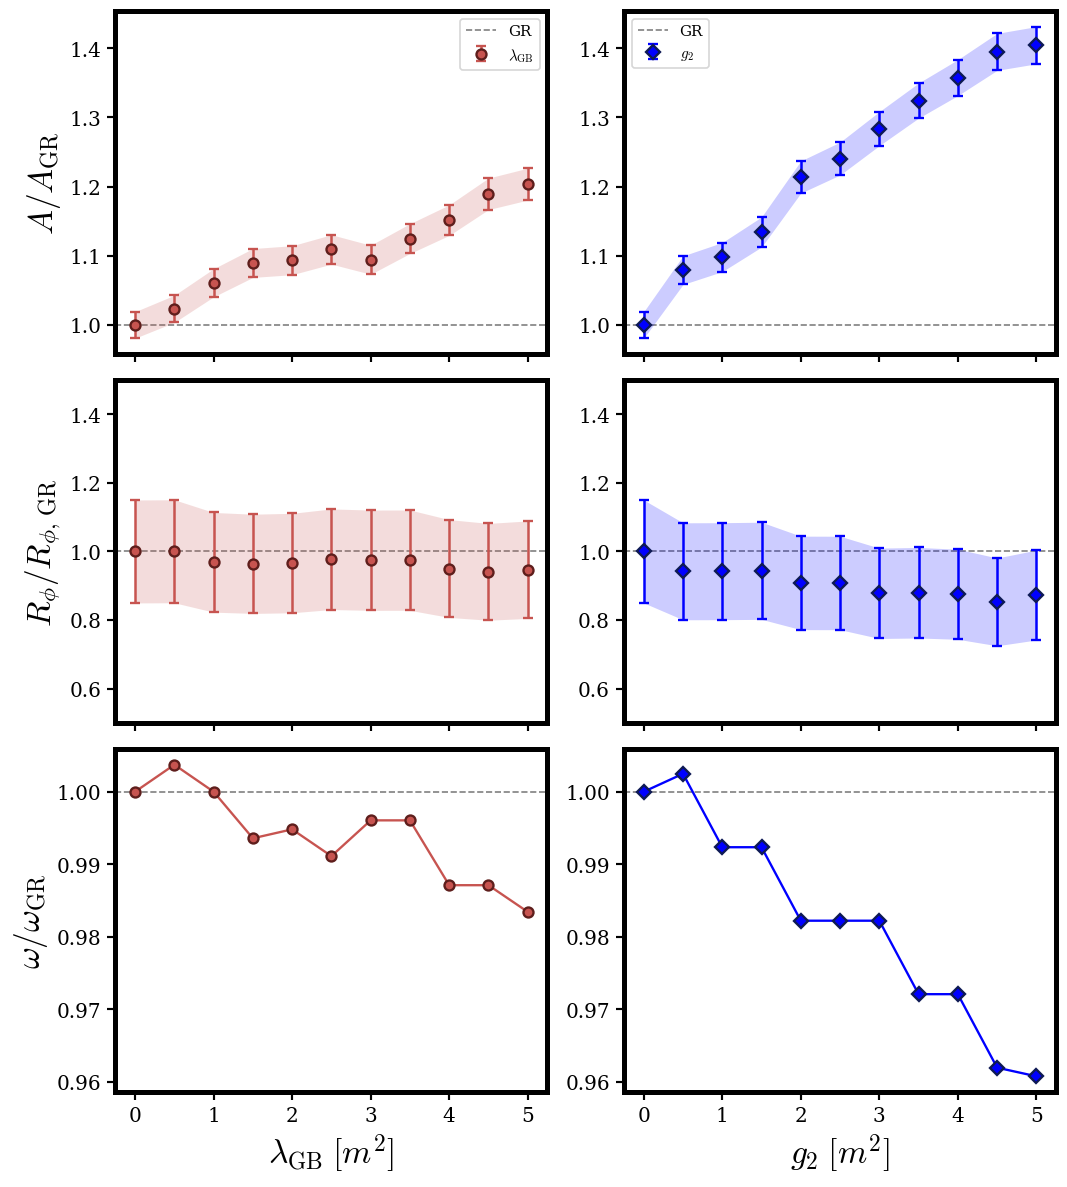

In [13]:
# ============================================================================
# Big 3×2 summary plot of all GR-normalized observables vs the EFT couplings.
#
#   Rows  : top    = amplitude        A / A_GR
#           middle = field radius     R_φ / R_φ,GR
#           bottom = field frequency  ω / ω_GR     (run.omega_source)
#   Cols  : left   = vs Gauss-Bonnet coupling  λ_GB,  one curve per fixed g₂
#           right  = vs quartic coupling       g₂,    one curve per fixed λ_GB
#
#   GR reference (λ_GB = 0, g₂ = 0) is always taken from the unfiltered set,
#   so the normalization stays valid even if you exclude it via the filters.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib import cm

# ── filters (empty list = all available) ────────────────────────────────────
LGB_SHOW       = []     # λ_GB values to include
G2_SHOW        = []     # g₂   values to include
PURE_ONLY      = True   # hide mixed-coupling points: left column → only g₂=0 curve,
                        #                              right column → only λ_GB=0 curve
SHOW_ERRORBARS = True   # add numerical-truncation error bars + shaded band
                        # (uses CONV_ERR from the convergence-error cell above)
X_SCALE_DIV    = 2.0    # divide displayed x-axis values by this (matches the
                        # "stored value = 2 × physical coupling" convention used
                        # in finalplots2.ipynb's Panel 4 / 4-GB).
# Middle row (R_phi / R_phi,GR) y-axis options.
R_MID_YLIM     = (0.5,1.5)   # e.g. (0.0, 1.5)  -> ax.set_ylim(*R_MID_YLIM); None = auto
R_MID_YSCALE   = "linear"   # "linear" or "log"

if not p7_results:
    print("No spectra in p7_results — run the Panel 7 spectra cell first.")
else:
    # ── collect raw values keyed by (lgb, ..., g2) ──────────────────────────
    A_all = {k: r["run"].A             for k, r in p7_results.items()}
    R_all = {k: p7_Renv[k]["R_env"]    for k in p7_results}
    W_all = {k: r["run"].omega_source  for k, r in p7_results.items()}

    # ── GR reference (always from the full set) ─────────────────────────────
    _gr_key = next((k for k in A_all if k[0] == 0.0 and k[5] == 0.0), None)
    A_GR = A_all.get(_gr_key) if _gr_key is not None else None
    R_GR = R_all.get(_gr_key) if _gr_key is not None else None
    W_GR = W_all.get(_gr_key) if _gr_key is not None else None
    if not all(v not in (None, 0.0) for v in (A_GR, R_GR, W_GR)):
        print("No GR reference (λ_GB=0, g₂=0) found — cannot normalize.")
    else:
        # ── apply user filters ──────────────────────────────────────────────
        def _filtered(d):
            return {k: v for k, v in d.items()
                    if (not LGB_SHOW or k[0] in LGB_SHOW)
                    and (not G2_SHOW or k[5] in G2_SHOW)}
        A_by_key = _filtered(A_all)
        R_by_key = _filtered(R_all)
        W_by_key = _filtered(W_all)

        lgb_vals = sorted({k[0] for k in A_by_key})
        g2_vals  = sorted({k[5] for k in A_by_key})

        def _group(d, ref, fixed_idx, x_idx):
            """fixed_idx = 5 (g2 fixed -> vs lgb)  or  0 (lgb fixed -> vs g2)."""
            out = defaultdict(list)
            for k, v in d.items():
                out[k[fixed_idx]].append((k[x_idx], v / ref))
            for kk in out:
                out[kk].sort()
            return out

        # vs λ_GB  (group by g2; x = lgb) — restrict to pure-λ runs (g2=0) if PURE_ONLY
        A_pure_lgb = {k: v for k, v in A_by_key.items() if (not PURE_ONLY) or k[5] == 0.0}
        R_pure_lgb = {k: v for k, v in R_by_key.items() if (not PURE_ONLY) or k[5] == 0.0}
        W_pure_lgb = {k: v for k, v in W_by_key.items() if (not PURE_ONLY) or k[5] == 0.0}
        A_vs_lgb = _group(A_pure_lgb, A_GR, fixed_idx=5, x_idx=0)
        R_vs_lgb = _group(R_pure_lgb, R_GR, fixed_idx=5, x_idx=0)
        W_vs_lgb = _group(W_pure_lgb, W_GR, fixed_idx=5, x_idx=0)
        # vs g₂   (group by lgb; x = g2) — restrict to pure-g₂ runs (lgb=0) if PURE_ONLY
        A_pure_g2 = {k: v for k, v in A_by_key.items() if (not PURE_ONLY) or k[0] == 0.0}
        R_pure_g2 = {k: v for k, v in R_by_key.items() if (not PURE_ONLY) or k[0] == 0.0}
        W_pure_g2 = {k: v for k, v in W_by_key.items() if (not PURE_ONLY) or k[0] == 0.0}
        A_vs_g2  = _group(A_pure_g2, A_GR, fixed_idx=0, x_idx=5)
        R_vs_g2  = _group(R_pure_g2, R_GR, fixed_idx=0, x_idx=5)
        W_vs_g2  = _group(W_pure_g2, W_GR, fixed_idx=0, x_idx=5)

        # restrict the per-column curve-set to the pure series only
        if PURE_ONLY:
            g2_vals_left   = [g2 for g2 in g2_vals  if g2 == 0.0]
            lgb_vals_right = [lg for lg in lgb_vals if lg == 0.0]
        else:
            g2_vals_left, lgb_vals_right = g2_vals, lgb_vals

        # ── plot ────────────────────────────────────────────────────────────
        fig, axes = plt.subplots(3, 2, figsize=(9, 10), sharex="col")
        (ax_Al, ax_Ag), (ax_Rl, ax_Rg), (ax_Wl, ax_Wg) = axes

        # row-level sharey
        ax_Ag.sharey(ax_Al)
        ax_Rg.sharey(ax_Rl)
        ax_Wg.sharey(ax_Wl)

        # styling: coral/red circles for λ_GB column, royal-blue diamonds for g₂ column
        LEFT_FILL,  LEFT_EDGE  = "#c75450", "#5e1e1c"
        RIGHT_FILL, RIGHT_EDGE = "b", "#0e1a55"
        if PURE_ONLY:
            left_colors  = [LEFT_FILL]
            right_colors = [RIGHT_FILL]
        else:
            left_colors  = cm.viridis(np.linspace(0.15, 0.85, max(len(g2_vals_left), 1)))
            right_colors = cm.plasma( np.linspace(0.15, 0.85, max(len(lgb_vals_right), 1)))

        # fractional truncation errors (per-row); falls back to 0 if unavailable
        if SHOW_ERRORBARS:
            try:
                _err_row = {
                    "A":     CONV_ERR["A"]["frac_ratio"],
                    "R_env": CONV_ERR["R_env"]["frac_ratio"],
                    "omega": CONV_ERR["omega"]["frac_ratio"],
                }
            except (NameError, KeyError):
                print("⚠ CONV_ERR not defined — run the convergence-error cell above first.")
                _err_row = {"A": 0.0, "R_env": 0.0, "omega": 0.0}
        else:
            _err_row = {"A": 0.0, "R_env": 0.0, "omega": 0.0}

        def _draw_left(ax, data, ylabel, frac_err):
            for col, g2 in zip(left_colors, g2_vals_left):
                if not data[g2]:
                    continue
                xs, ys = zip(*data[g2])
                xs_np = np.asarray(xs, dtype=float) / X_SCALE_DIV
                ys_np = np.asarray(ys, dtype=float)
                lab = r"$\lambda_{\rm GB}$" if PURE_ONLY else rf"$g_2 = {g2:g}$"
                if SHOW_ERRORBARS and frac_err > 0:
                    yerr = np.abs(ys_np) * frac_err
                    ax.fill_between(xs_np, ys_np - yerr, ys_np + yerr,
                                    color=col, alpha=0.20, linewidth=0, zorder=1)
                    ax.errorbar(xs_np, ys_np, yerr=yerr, fmt="o",
                                color=col, ecolor=col, elinewidth=1.5, capsize=3,
                                markersize=6, markerfacecolor=col,
                                markeredgecolor=LEFT_EDGE, markeredgewidth=1.4,
                                label=lab, zorder=3)
                else:
                    ax.plot(xs_np, ys_np, "o-", color=col, lw=1.4, markersize=6,
                            markerfacecolor=col, markeredgecolor=LEFT_EDGE,
                            markeredgewidth=1.4, label=lab)
            ax.axhline(1.0, color="gray", ls="--", lw=1.0, zorder=0, label="GR")
            ax.set_ylabel(ylabel, fontsize=20)
            #ax.set_ylim(-0.3,2)
            #ax.grid(alpha=0.3)

        def _draw_right(ax, data, frac_err):
            for col, lgb in zip(right_colors, lgb_vals_right):
                if not data[lgb]:
                    continue
                xs, ys = zip(*data[lgb])
                xs_np = np.asarray(xs, dtype=float) / X_SCALE_DIV
                ys_np = np.asarray(ys, dtype=float)
                lab = r"$g_2$" if PURE_ONLY else rf"$\lambda_{{\rm GB}} = {lgb:g}$"
                if SHOW_ERRORBARS and frac_err > 0:
                    yerr = np.abs(ys_np) * frac_err
                    ax.fill_between(xs_np, ys_np - yerr, ys_np + yerr,
                                    color=col, alpha=0.20, linewidth=0, zorder=1)
                    ax.errorbar(xs_np, ys_np, yerr=yerr, fmt="D",
                                color=col, ecolor=col, elinewidth=1.5, capsize=3,
                                markersize=6, markerfacecolor=col,
                                markeredgecolor=RIGHT_EDGE, markeredgewidth=1.4,
                                label=lab, zorder=3)
                else:
                    ax.plot(xs_np, ys_np, "D-", color=col, lw=1.4, markersize=6,
                            markerfacecolor=col, markeredgecolor=RIGHT_EDGE,
                            markeredgewidth=1.4, label=lab)
            ax.axhline(1.0, color="gray", ls="--", lw=1.0, zorder=0, label="GR")
            #ax.grid(alpha=0.3)

        _draw_left (ax_Al, A_vs_lgb, r"$A / A_{\rm GR}$",              _err_row["A"])
        _draw_left (ax_Rl, R_vs_lgb, r"$R_\phi / R_{\phi,\,\rm GR}$",   _err_row["R_env"])
        _draw_left (ax_Wl, W_vs_lgb, r"$\omega / \omega_{\rm GR}$",     _err_row["omega"])
        _draw_right(ax_Ag, A_vs_g2,  _err_row["A"])
        _draw_right(ax_Rg, R_vs_g2,  _err_row["R_env"])
        _draw_right(ax_Wg, W_vs_g2,  _err_row["omega"])

        # Middle-row (R_phi / R_phi,GR) y-axis controls.
        # Apply to the LEFT middle axis only; the right middle axis follows
        # because of the row-level sharey() set earlier.
        if R_MID_YSCALE != "linear":
            ax_Rl.set_yscale(R_MID_YSCALE)
        if R_MID_YLIM is not None:
            ax_Rl.set_ylim(*R_MID_YLIM)

        # x-axis labels only on the bottom row
        ax_Wl.set_xlabel(r"$\lambda_{\rm GB}\;[m^{2}]$", fontsize=20)
        ax_Wg.set_xlabel(r"$g_2\;[m^{2}]$",              fontsize=20)

        # one legend per column (top row) is enough
        ax_Al.legend(fontsize=9, loc="best")
        ax_Ag.legend(fontsize=9, loc="best")

        fig.tight_layout()
        #save_fig(fig, "oscillon_A_R_omega_rel_grid")
        plt.show()


  saved oscillon_A_R_omega_rel_grid_omegaErrFromR.pdf and oscillon_A_R_omega_rel_grid_omegaErrFromR.png


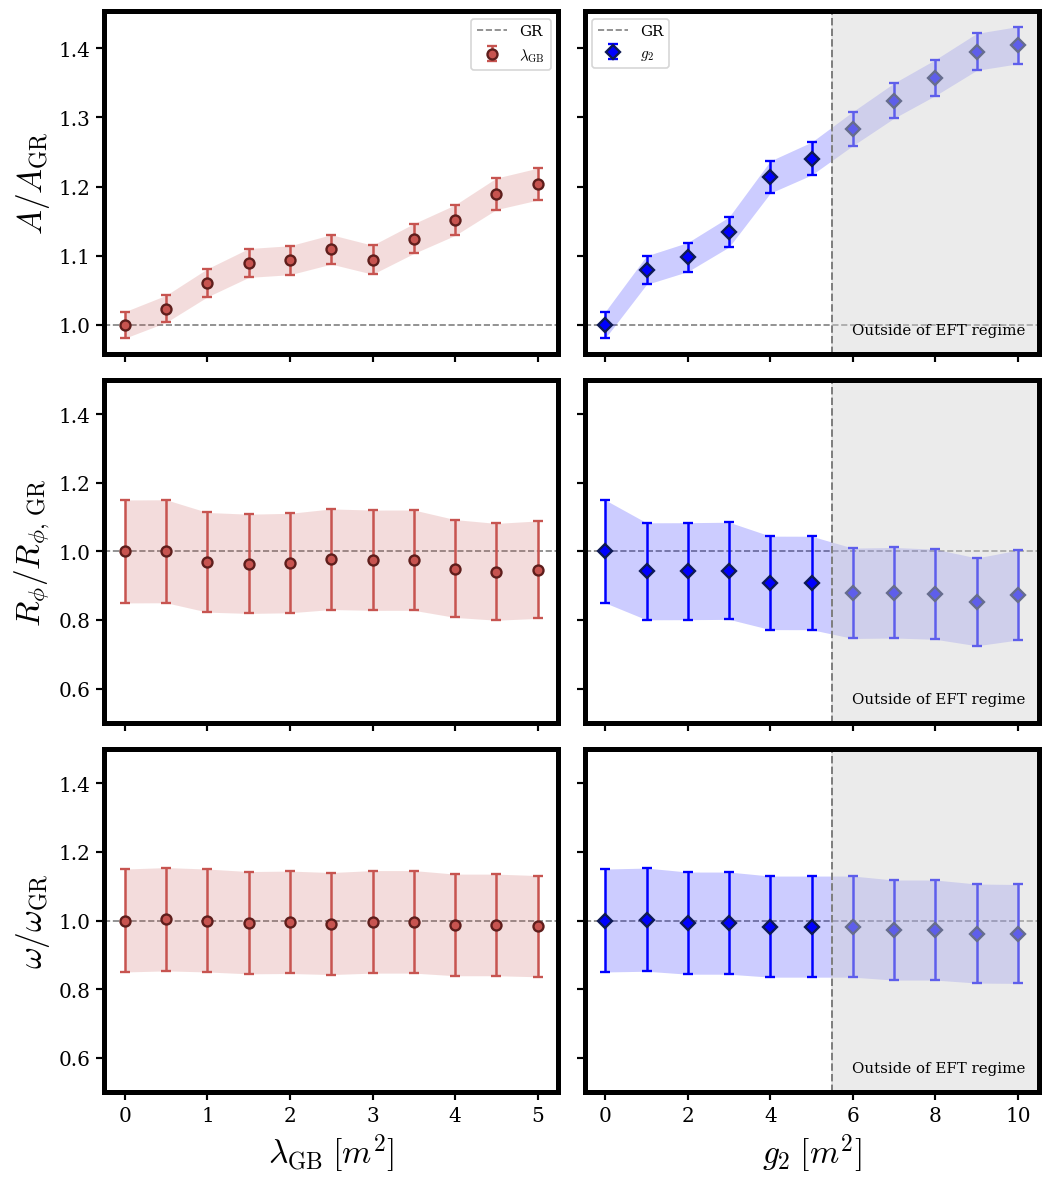

In [18]:
# ============================================================================
# Same 3x2 summary plot as the cell above, but the BOTTOM row (frequency)
# inherits the RADIUS row's fractional error so the omega points also get
# visible error bars / shaded band.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib import cm

# ── filters (empty list = all available) ────────────────────────────────────
LGB_SHOW       = []
G2_SHOW        = []
PURE_ONLY      = True
SHOW_ERRORBARS = True
X_SCALE_DIV    = 2.0
R_MID_YLIM     = (0.5, 1.5)
W_BOT_YLIM     = (0.5, 1.5)
R_MID_YSCALE   = "linear"
W_BOT_YSCALE   = "linear"       # "linear" or "log"
# Bottom-row (omega) error source: use the radius's fractional error so the
# frequency points always carry visible uncertainty. Set to "omega" to recover
# the original behaviour, or "max" to take the max of the omega/R_env errors.
OMEGA_ERR_FROM = "R_env"        # "R_env" | "omega" | "max"

# Right-column ("vs g_2") "Outside of EFT regime" annotation: matches the
# styling used in finalplots2.ipynb's normalized side-by-side plot.
EFT_BOUNDARY_X   = 5.5          # boundary x-value in the plot's (halved) units
EFT_RIGHT_XLIM   = (-0.5, 10.5)      # x-limits for the right column; None = auto
EFT_RIGHT_XTICKS = np.arange(0, 11, 2)  # ticks every 2 from 0 to 10
EFT_TEXT_XY      = (0.59, 0.07) # axes-coords of "Outside of EFT regime" label
SHOW_EFT_ANNOT   = True         # set False to drop the EFT shading entirely

if not p7_results:
    print("No spectra in p7_results — run the Panel 7 spectra cell first.")
else:
    A_all = {k: r["run"].A             for k, r in p7_results.items()}
    R_all = {k: p7_Renv[k]["R_env"]    for k in p7_results}
    W_all = {k: r["run"].omega_source  for k, r in p7_results.items()}

    _gr_key = next((k for k in A_all if k[0] == 0.0 and k[5] == 0.0), None)
    A_GR = A_all.get(_gr_key) if _gr_key is not None else None
    R_GR = R_all.get(_gr_key) if _gr_key is not None else None
    W_GR = W_all.get(_gr_key) if _gr_key is not None else None
    if not all(v not in (None, 0.0) for v in (A_GR, R_GR, W_GR)):
        print("No GR reference (λ_GB=0, g₂=0) found — cannot normalize.")
    else:
        def _filtered(d):
            return {k: v for k, v in d.items()
                    if (not LGB_SHOW or k[0] in LGB_SHOW)
                    and (not G2_SHOW or k[5] in G2_SHOW)}
        A_by_key = _filtered(A_all)
        R_by_key = _filtered(R_all)
        W_by_key = _filtered(W_all)

        lgb_vals = sorted({k[0] for k in A_by_key})
        g2_vals  = sorted({k[5] for k in A_by_key})

        def _group(d, ref, fixed_idx, x_idx):
            out = defaultdict(list)
            for k, v in d.items():
                out[k[fixed_idx]].append((k[x_idx], v / ref))
            for kk in out:
                out[kk].sort()
            return out

        A_pure_lgb = {k: v for k, v in A_by_key.items() if (not PURE_ONLY) or k[5] == 0.0}
        R_pure_lgb = {k: v for k, v in R_by_key.items() if (not PURE_ONLY) or k[5] == 0.0}
        W_pure_lgb = {k: v for k, v in W_by_key.items() if (not PURE_ONLY) or k[5] == 0.0}
        A_vs_lgb = _group(A_pure_lgb, A_GR, fixed_idx=5, x_idx=0)
        R_vs_lgb = _group(R_pure_lgb, R_GR, fixed_idx=5, x_idx=0)
        W_vs_lgb = _group(W_pure_lgb, W_GR, fixed_idx=5, x_idx=0)
        A_pure_g2 = {k: v for k, v in A_by_key.items() if (not PURE_ONLY) or k[0] == 0.0}
        R_pure_g2 = {k: v for k, v in R_by_key.items() if (not PURE_ONLY) or k[0] == 0.0}
        W_pure_g2 = {k: v for k, v in W_by_key.items() if (not PURE_ONLY) or k[0] == 0.0}
        A_vs_g2  = _group(A_pure_g2, A_GR, fixed_idx=0, x_idx=5)
        R_vs_g2  = _group(R_pure_g2, R_GR, fixed_idx=0, x_idx=5)
        W_vs_g2  = _group(W_pure_g2, W_GR, fixed_idx=0, x_idx=5)

        if PURE_ONLY:
            g2_vals_left   = [g2 for g2 in g2_vals  if g2 == 0.0]
            lgb_vals_right = [lg for lg in lgb_vals if lg == 0.0]
        else:
            g2_vals_left, lgb_vals_right = g2_vals, lgb_vals

        # sharey="row" both shares the y-range across each row AND hides the
        # duplicate y-tick labels on the right column, just like the 1x2
        # GW-peak plot below.
        fig, axes = plt.subplots(3, 2, figsize=(9, 10),
                                 sharex="col", sharey="row")
        (ax_Al, ax_Ag), (ax_Rl, ax_Rg), (ax_Wl, ax_Wg) = axes

        LEFT_FILL,  LEFT_EDGE  = "#c75450", "#5e1e1c"
        RIGHT_FILL, RIGHT_EDGE = "b", "#0e1a55"
        if PURE_ONLY:
            left_colors  = [LEFT_FILL]
            right_colors = [RIGHT_FILL]
        else:
            left_colors  = cm.viridis(np.linspace(0.15, 0.85, max(len(g2_vals_left), 1)))
            right_colors = cm.plasma( np.linspace(0.15, 0.85, max(len(lgb_vals_right), 1)))

        if SHOW_ERRORBARS:
            try:
                _err_row = {
                    "A":     CONV_ERR["A"]["frac_ratio"],
                    "R_env": CONV_ERR["R_env"]["frac_ratio"],
                    "omega": CONV_ERR["omega"]["frac_ratio"],
                }
            except (NameError, KeyError):
                print("⚠ CONV_ERR not defined — run the convergence-error cell above first.")
                _err_row = {"A": 0.0, "R_env": 0.0, "omega": 0.0}
        else:
            _err_row = {"A": 0.0, "R_env": 0.0, "omega": 0.0}

        # Override the omega-row error source as requested.
        if OMEGA_ERR_FROM == "R_env":
            _omega_err = _err_row["R_env"]
        elif OMEGA_ERR_FROM == "max":
            _omega_err = max(_err_row["R_env"], _err_row["omega"])
        else:
            _omega_err = _err_row["omega"]

        def _draw_left(ax, data, ylabel, frac_err):
            for col, g2 in zip(left_colors, g2_vals_left):
                if not data[g2]:
                    continue
                xs, ys = zip(*data[g2])
                xs_np = np.asarray(xs, dtype=float) / X_SCALE_DIV
                ys_np = np.asarray(ys, dtype=float)
                lab = r"$\lambda_{\rm GB}$" if PURE_ONLY else rf"$g_2 = {g2:g}$"
                if SHOW_ERRORBARS and frac_err > 0:
                    yerr = np.abs(ys_np) * frac_err
                    ax.fill_between(xs_np, ys_np - yerr, ys_np + yerr,
                                    color=col, alpha=0.20, linewidth=0, zorder=1)
                    ax.errorbar(xs_np, ys_np, yerr=yerr, fmt="o",
                                color=col, ecolor=col, elinewidth=1.5, capsize=3,
                                markersize=6, markerfacecolor=col,
                                markeredgecolor=LEFT_EDGE, markeredgewidth=1.4,
                                label=lab, zorder=3)
                else:
                    ax.plot(xs_np, ys_np, "o-", color=col, lw=1.4, markersize=6,
                            markerfacecolor=col, markeredgecolor=LEFT_EDGE,
                            markeredgewidth=1.4, label=lab)
            ax.axhline(1.0, color="gray", ls="--", lw=1.0, zorder=0, label="GR")
            ax.set_ylabel(ylabel, fontsize=20)

        def _draw_right(ax, data, frac_err):
            for col, lgb in zip(right_colors, lgb_vals_right):
                if not data[lgb]:
                    continue
                xs, ys = zip(*data[lgb])
                xs_np = np.asarray(xs, dtype=float) / X_SCALE_DIV
                ys_np = np.asarray(ys, dtype=float)
                lab = r"$g_2$" if PURE_ONLY else rf"$\lambda_{{\rm GB}} = {lgb:g}$"
                if SHOW_ERRORBARS and frac_err > 0:
                    yerr = np.abs(ys_np) * frac_err
                    ax.fill_between(xs_np, ys_np - yerr, ys_np + yerr,
                                    color=col, alpha=0.20, linewidth=0, zorder=1)
                    ax.errorbar(xs_np, ys_np, yerr=yerr, fmt="D",
                                color=col, ecolor=col, elinewidth=1.5, capsize=3,
                                markersize=6, markerfacecolor=col,
                                markeredgecolor=RIGHT_EDGE, markeredgewidth=1.4,
                                label=lab, zorder=3)
                else:
                    ax.plot(xs_np, ys_np, "D-", color=col, lw=1.4, markersize=6,
                            markerfacecolor=col, markeredgecolor=RIGHT_EDGE,
                            markeredgewidth=1.4, label=lab)
            ax.axhline(1.0, color="gray", ls="--", lw=1.0, zorder=0, label="GR")

        _draw_left (ax_Al, A_vs_lgb, r"$A / A_{\rm GR}$",              _err_row["A"])
        _draw_left (ax_Rl, R_vs_lgb, r"$R_\phi / R_{\phi,\,\rm GR}$",   _err_row["R_env"])
        _draw_left (ax_Wl, W_vs_lgb, r"$\omega / \omega_{\rm GR}$",     _omega_err)
        _draw_right(ax_Ag, A_vs_g2,  _err_row["A"])
        _draw_right(ax_Rg, R_vs_g2,  _err_row["R_env"])
        _draw_right(ax_Wg, W_vs_g2,  _omega_err)

        if R_MID_YSCALE != "linear":
            ax_Rl.set_yscale(R_MID_YSCALE)
        if R_MID_YLIM is not None:
            ax_Rl.set_ylim(*R_MID_YLIM)

        # Bottom-row (omega) y-axis controls. Right axis follows via sharey().
        if W_BOT_YSCALE != "linear":
            ax_Wl.set_yscale(W_BOT_YSCALE)
        if W_BOT_YLIM is not None:
            ax_Wl.set_ylim(*W_BOT_YLIM)

        # "Outside of EFT regime" annotation on every right (g_2) panel.
        # Mirrors finalplots2.ipynb's normalized side-by-side plot.
        if SHOW_EFT_ANNOT:
            from matplotlib.transforms import blended_transform_factory
            for _axR in (ax_Ag, ax_Rg, ax_Wg):
                if EFT_RIGHT_XLIM is not None:
                    _axR.set_xlim(*EFT_RIGHT_XLIM)
                if EFT_RIGHT_XTICKS is not None:
                    _axR.set_xticks(EFT_RIGHT_XTICKS)
                _axR.axvline(EFT_BOUNDARY_X, color="grey", ls="--", lw=1.2, zorder=5)
                _axR.axvspan(EFT_BOUNDARY_X, _axR.get_xlim()[1],
                             color="lightgrey", alpha=0.45, zorder=4)
                _axR.text(*EFT_TEXT_XY, "Outside of EFT regime",
                          transform=_axR.transAxes, va="center", ha="left",
                          fontsize=9, color="black", zorder=11)
                _axR.set_frame_on(True)
                for _sp in _axR.spines.values():
                    _sp.set_zorder(10)

        ax_Wl.set_xlabel(r"$\lambda_{\rm GB}\;[m^{2}]$", fontsize=20)
        ax_Wg.set_xlabel(r"$g_2\;[m^{2}]$",              fontsize=20)

        ax_Al.legend(fontsize=9, loc="best")
        ax_Ag.legend(fontsize=9, loc="best")

        fig.tight_layout()
        save_fig(fig, "oscillon_A_R_omega_rel_grid_omegaErrFromR")
        plt.show()

  saved GW_Omega_peak_rel_grid.pdf and GW_Omega_peak_rel_grid.png


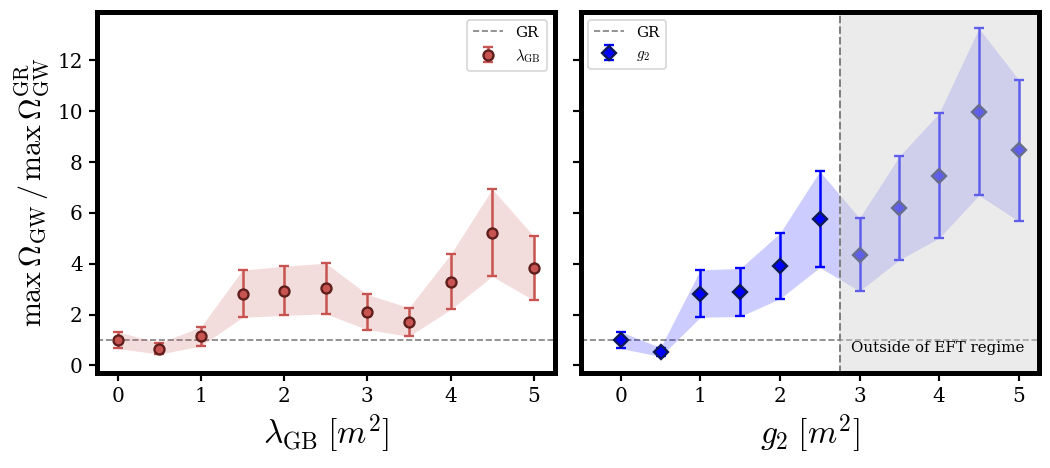

In [16]:
# ============================================================================
# Companion 1×2 plot — RELATIVE peak GW amplitude max Ω_GW / max Ω_GW^GR.
#   Same structure / styling as the 3×2 grid above, but with only one row:
#       left  : vs λ_GB,  one curve per fixed g₂ (pure-λ runs if PURE_ONLY)
#       right : vs g₂,    one curve per fixed λ_GB (pure-g₂ runs if PURE_ONLY)
#   Toggles (PURE_ONLY, SHOW_ERRORBARS, LGB_SHOW, G2_SHOW) and styling are
#   inherited from the grid cell above.
#
#   Error bar: direct convergence test on the spectral observable itself.
#   The (λ_GB=5, g₂=5) trio is fed through the full Omega_GW pipeline at
#   three resolutions in the CONV-ERR cell above, and the Richardson
#   estimate is stored in CONV_ERR["Omega_max"]["frac_ratio"] (it already
#   carries the √2 ratio factor).  No more A^4 propagation.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib import cm

if not p7_results:
    print("No spectra in p7_results — run the Panel 7 spectra cell first.")
else:
    # ── collect peak Ω_GW for every available run ───────────────────────────
    Om_all = {k: float(r["res"]["Omega_GW"].max()) for k, r in p7_results.items()}

    # GR reference (always from the full set)
    _gr_key = next((k for k in Om_all if k[0] == 0.0 and k[5] == 0.0), None)
    Om_GR = Om_all.get(_gr_key) if _gr_key is not None else None
    if Om_GR in (None, 0.0):
        print("No GR reference (λ_GB=0, g₂=0) found — cannot normalize.")
    else:
        # ── apply user filters ──────────────────────────────────────────────
        Om_by_key = {k: v for k, v in Om_all.items()
                     if (not LGB_SHOW or k[0] in LGB_SHOW)
                     and (not G2_SHOW or k[5] in G2_SHOW)}

        lgb_vals = sorted({k[0] for k in Om_by_key})
        g2_vals  = sorted({k[5] for k in Om_by_key})

        def _group(d, ref, fixed_idx, x_idx):
            out = defaultdict(list)
            for k, v in d.items():
                out[k[fixed_idx]].append((k[x_idx], v / ref))
            for kk in out:
                out[kk].sort()
            return out

        # vs λ_GB (pure-λ if PURE_ONLY) and vs g₂ (pure-g₂ if PURE_ONLY)
        Om_pure_lgb = {k: v for k, v in Om_by_key.items() if (not PURE_ONLY) or k[5] == 0.0}
        Om_pure_g2  = {k: v for k, v in Om_by_key.items() if (not PURE_ONLY) or k[0] == 0.0}
        Om_vs_lgb = _group(Om_pure_lgb, Om_GR, fixed_idx=5, x_idx=0)
        Om_vs_g2  = _group(Om_pure_g2,  Om_GR, fixed_idx=0, x_idx=5)

        if PURE_ONLY:
            g2_vals_left   = [g2 for g2 in g2_vals  if g2 == 0.0]
            lgb_vals_right = [lg for lg in lgb_vals if lg == 0.0]
        else:
            g2_vals_left, lgb_vals_right = g2_vals, lgb_vals

        # ── plot ────────────────────────────────────────────────────────────
        fig, (ax_l, ax_g) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

        # styling: same as the grid above
        LEFT_FILL,  LEFT_EDGE  = "#c75450", "#5e1e1c"
        RIGHT_FILL, RIGHT_EDGE = "b",       "#0e1a55"
        if PURE_ONLY:
            left_colors  = [LEFT_FILL]
            right_colors = [RIGHT_FILL]
        else:
            left_colors  = cm.viridis(np.linspace(0.15, 0.85, max(len(g2_vals_left), 1)))
            right_colors = cm.plasma( np.linspace(0.15, 0.85, max(len(lgb_vals_right), 1)))

        # error bar on Ω_GW: directly measured from the (λ=5,g₂=5) trio
        # in CONV_ERR["Omega_max"] (computed by the CONV-ERR cell above).
        if SHOW_ERRORBARS:
            try:
                frac_err_Omega = CONV_ERR["Omega_max"]["frac_ratio"]
            except (NameError, KeyError):
                print("⚠ CONV_ERR['Omega_max'] not defined — "
                      "set COMPUTE_OMEGA_GW_ERR=True in the CONV-ERR cell above and re-run it.")
                frac_err_Omega = 0.0
        else:
            frac_err_Omega = 0.0

        def _draw_left(ax, data, frac_err):
            for col, g2 in zip(left_colors, g2_vals_left):
                if not data[g2]:
                    continue
                xs, ys = zip(*data[g2])
                xs_np = np.asarray(xs, dtype=float) / X_SCALE_DIV
                ys_np = np.asarray(ys, dtype=float)
                lab = r"$\lambda_{\rm GB}$" if PURE_ONLY else rf"$g_2 = {g2:g}$"
                if SHOW_ERRORBARS and frac_err > 0:
                    yerr = np.abs(ys_np) * frac_err
                    ax.fill_between(xs_np, ys_np - yerr, ys_np + yerr,
                                    color=col, alpha=0.20, linewidth=0, zorder=1)
                    ax.errorbar(xs_np, ys_np, yerr=yerr, fmt="o",
                                color=col, ecolor=col, elinewidth=1.5, capsize=3,
                                markersize=6, markerfacecolor=col,
                                markeredgecolor=LEFT_EDGE, markeredgewidth=1.4,
                                label=lab, zorder=3)
                else:
                    ax.plot(xs_np, ys_np, "o-", color=col, lw=1.4, markersize=6,
                            markerfacecolor=col, markeredgecolor=LEFT_EDGE,
                            markeredgewidth=1.4, label=lab)
            ax.axhline(1.0, color="gray", ls="--", lw=1.0, zorder=0, label="GR")
            ax.set_ylabel(r"$\max\,\Omega_{\rm GW}\,/\,\max\,\Omega_{\rm GW}^{\rm GR}$",
                          fontsize=18)
            ax.set_xlabel(r"$\lambda_{\rm GB}\;[m^{2}]$", fontsize=20)
            ax.legend(fontsize=9, loc="best")

        def _draw_right(ax, data, frac_err):
            for col, lgb in zip(right_colors, lgb_vals_right):
                if not data[lgb]:
                    continue
                xs, ys = zip(*data[lgb])
                xs_np = np.asarray(xs, dtype=float) / X_SCALE_DIV
                ys_np = np.asarray(ys, dtype=float)
                lab = r"$g_2$" if PURE_ONLY else rf"$\lambda_{{\rm GB}} = {lgb:g}$"
                if SHOW_ERRORBARS and frac_err > 0:
                    yerr = np.abs(ys_np) * frac_err
                    ax.fill_between(xs_np, ys_np - yerr, ys_np + yerr,
                                    color=col, alpha=0.20, linewidth=0, zorder=1)
                    ax.errorbar(xs_np, ys_np, yerr=yerr, fmt="D",
                                color=col, ecolor=col, elinewidth=1.5, capsize=3,
                                markersize=6, markerfacecolor=col,
                                markeredgecolor=RIGHT_EDGE, markeredgewidth=1.4,
                                label=lab, zorder=3)
                else:
                    ax.plot(xs_np, ys_np, "D-", color=col, lw=1.4, markersize=6,
                            markerfacecolor=col, markeredgecolor=RIGHT_EDGE,
                            markeredgewidth=1.4, label=lab)
            ax.axhline(1.0, color="gray", ls="--", lw=1.0, zorder=0, label="GR")
            ax.set_xlabel(r"$g_2\;[m^{2}]$", fontsize=20)
            ax.legend(fontsize=9, loc="best")

        _draw_left (ax_l, Om_vs_lgb, frac_err_Omega)
        _draw_right(ax_g, Om_vs_g2,  frac_err_Omega)

        # "Outside of EFT regime" annotation on the right (g_2) panel.
        # Inherits the same EFT_* knobs as the 3x2 grid cell above.
        if SHOW_EFT_ANNOT:
            if EFT_RIGHT_XLIM is not None:
                ax_g.set_xlim(*EFT_RIGHT_XLIM)
            if EFT_RIGHT_XTICKS is not None:
                ax_g.set_xticks(EFT_RIGHT_XTICKS)
            ax_g.axvline(EFT_BOUNDARY_X, color="grey", ls="--", lw=1.2, zorder=5)
            ax_g.axvspan(EFT_BOUNDARY_X, ax_g.get_xlim()[1],
                         color="lightgrey", alpha=0.45, zorder=4)
            ax_g.text(*EFT_TEXT_XY, "Outside of EFT regime",
                      transform=ax_g.transAxes, va="center", ha="left",
                      fontsize=9, color="black", zorder=11)
            ax_g.set_frame_on(True)
            for _sp in ax_g.spines.values():
                _sp.set_zorder(10)

        fig.tight_layout()
        save_fig(fig, "GW_Omega_peak_rel_grid")
        plt.show()


  saved GW_Omega_peak_rel_grid_errFromR.pdf and GW_Omega_peak_rel_grid_errFromR.png


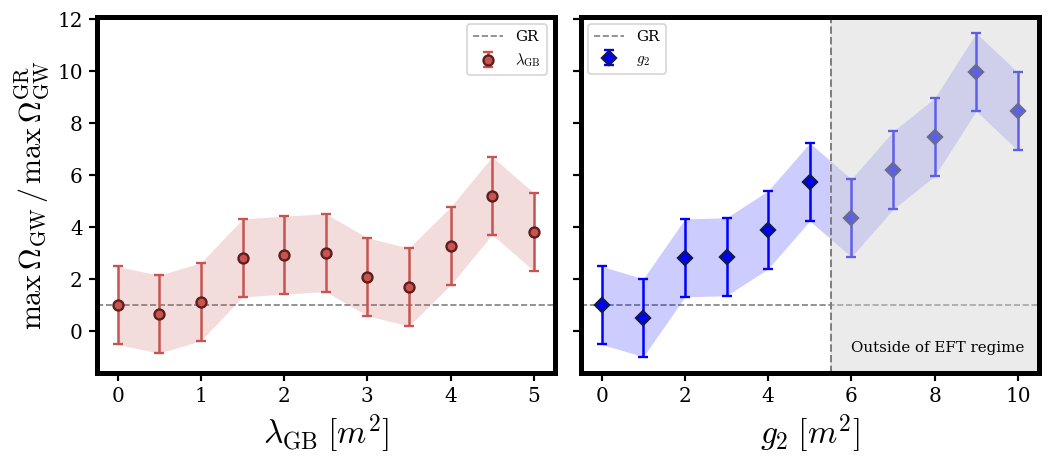

In [20]:
# ============================================================================
# Same Companion 1x2 GW-peak plot as the cell above, but the error bars are
# driven by the RADIUS's fractional convergence error (CONV_ERR["R_env"])
# instead of the direct Omega_GW convergence error. This matches the
# OMEGA_ERR_FROM = "R_env" convention used in the 3x2 omega-from-R cell above.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib import cm

# Where to take the GW-peak error from:
#   "R_env"     -> use CONV_ERR["R_env"]["frac_ratio"]
#   "Omega_max" -> use CONV_ERR["Omega_max"]["frac_ratio"] (original behaviour)
#   "max"       -> max of the two
GW_ERR_FROM = "R_env"

if not p7_results:
    print("No spectra in p7_results — run the Panel 7 spectra cell first.")
else:
    Om_all = {k: float(r["res"]["Omega_GW"].max()) for k, r in p7_results.items()}

    _gr_key = next((k for k in Om_all if k[0] == 0.0 and k[5] == 0.0), None)
    Om_GR = Om_all.get(_gr_key) if _gr_key is not None else None
    if Om_GR in (None, 0.0):
        print("No GR reference (λ_GB=0, g₂=0) found — cannot normalize.")
    else:
        Om_by_key = {k: v for k, v in Om_all.items()
                     if (not LGB_SHOW or k[0] in LGB_SHOW)
                     and (not G2_SHOW or k[5] in G2_SHOW)}

        lgb_vals = sorted({k[0] for k in Om_by_key})
        g2_vals  = sorted({k[5] for k in Om_by_key})

        def _group(d, ref, fixed_idx, x_idx):
            out = defaultdict(list)
            for k, v in d.items():
                out[k[fixed_idx]].append((k[x_idx], v / ref))
            for kk in out:
                out[kk].sort()
            return out

        Om_pure_lgb = {k: v for k, v in Om_by_key.items() if (not PURE_ONLY) or k[5] == 0.0}
        Om_pure_g2  = {k: v for k, v in Om_by_key.items() if (not PURE_ONLY) or k[0] == 0.0}
        Om_vs_lgb = _group(Om_pure_lgb, Om_GR, fixed_idx=5, x_idx=0)
        Om_vs_g2  = _group(Om_pure_g2,  Om_GR, fixed_idx=0, x_idx=5)

        if PURE_ONLY:
            g2_vals_left   = [g2 for g2 in g2_vals  if g2 == 0.0]
            lgb_vals_right = [lg for lg in lgb_vals if lg == 0.0]
        else:
            g2_vals_left, lgb_vals_right = g2_vals, lgb_vals

        fig, (ax_l, ax_g) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

        LEFT_FILL,  LEFT_EDGE  = "#c75450", "#5e1e1c"
        RIGHT_FILL, RIGHT_EDGE = "b",       "#0e1a55"
        if PURE_ONLY:
            left_colors  = [LEFT_FILL]
            right_colors = [RIGHT_FILL]
        else:
            left_colors  = cm.viridis(np.linspace(0.15, 0.85, max(len(g2_vals_left), 1)))
            right_colors = cm.plasma( np.linspace(0.15, 0.85, max(len(lgb_vals_right), 1)))

        # GW-peak error bar source: pulled from CONV_ERR via GW_ERR_FROM.
        if SHOW_ERRORBARS:
            try:
                _err_R   = CONV_ERR["R_env"]["frac_ratio"]
                _err_Om  = CONV_ERR.get("Omega_max", {}).get("frac_ratio", 0.0)
            except (NameError, KeyError):
                print("⚠ CONV_ERR not defined — run the convergence-error cell above first.")
                _err_R, _err_Om = 0.0, 0.0
            if GW_ERR_FROM == "Omega_max":
                frac_err_GW = _err_Om
            elif GW_ERR_FROM == "max":
                frac_err_GW = max(_err_R, _err_Om)
            else:
                frac_err_GW = _err_R
        else:
            frac_err_GW = 0.0

        # Pick ONE uniform absolute error: the largest |y| * frac_err across
        # every point in both panels, then apply that fixed value everywhere.
        _all_abs_errs = []
        for _ys_dict in (Om_vs_lgb, Om_vs_g2):
            for _pts in _ys_dict.values():
                for _, _y in _pts:
                    _all_abs_errs.append(abs(_y) * frac_err_GW)
        abs_yerr_uniform = max(_all_abs_errs) if _all_abs_errs else 0.0

        def _draw_left(ax, data, abs_yerr):
            for col, g2 in zip(left_colors, g2_vals_left):
                if not data[g2]:
                    continue
                xs, ys = zip(*data[g2])
                xs_np = np.asarray(xs, dtype=float) / X_SCALE_DIV
                ys_np = np.asarray(ys, dtype=float)
                lab = r"$\lambda_{\rm GB}$" if PURE_ONLY else rf"$g_2 = {g2:g}$"
                if SHOW_ERRORBARS and abs_yerr > 0:
                    yerr = np.full_like(ys_np, abs_yerr)
                    ax.fill_between(xs_np, ys_np - yerr, ys_np + yerr,
                                    color=col, alpha=0.20, linewidth=0, zorder=1)
                    ax.errorbar(xs_np, ys_np, yerr=yerr, fmt="o",
                                color=col, ecolor=col, elinewidth=1.5, capsize=3,
                                markersize=6, markerfacecolor=col,
                                markeredgecolor=LEFT_EDGE, markeredgewidth=1.4,
                                label=lab, zorder=3)
                else:
                    ax.plot(xs_np, ys_np, "o-", color=col, lw=1.4, markersize=6,
                            markerfacecolor=col, markeredgecolor=LEFT_EDGE,
                            markeredgewidth=1.4, label=lab)
            ax.axhline(1.0, color="gray", ls="--", lw=1.0, zorder=0, label="GR")
            ax.set_ylabel(r"$\max\,\Omega_{\rm GW}\,/\,\max\,\Omega_{\rm GW}^{\rm GR}$",
                          fontsize=18)
            ax.set_xlabel(r"$\lambda_{\rm GB}\;[m^{2}]$", fontsize=20)
            ax.legend(fontsize=9, loc="best")

        def _draw_right(ax, data, abs_yerr):
            for col, lgb in zip(right_colors, lgb_vals_right):
                if not data[lgb]:
                    continue
                xs, ys = zip(*data[lgb])
                xs_np = np.asarray(xs, dtype=float) #/ X_SCALE_DIV
                ys_np = np.asarray(ys, dtype=float)
                lab = r"$g_2$" if PURE_ONLY else rf"$\lambda_{{\rm GB}} = {lgb:g}$"
                if SHOW_ERRORBARS and abs_yerr > 0:
                    yerr = np.full_like(ys_np, abs_yerr)
                    ax.fill_between(xs_np, ys_np - yerr, ys_np + yerr,
                                    color=col, alpha=0.20, linewidth=0, zorder=1)
                    ax.errorbar(xs_np, ys_np, yerr=yerr, fmt="D",
                                color=col, ecolor=col, elinewidth=1.5, capsize=3,
                                markersize=6, markerfacecolor=col,
                                markeredgecolor=RIGHT_EDGE, markeredgewidth=1.4,
                                label=lab, zorder=3)
                else:
                    ax.plot(xs_np, ys_np, "D-", color=col, lw=1.4, markersize=6,
                            markerfacecolor=col, markeredgecolor=RIGHT_EDGE,
                            markeredgewidth=1.4, label=lab)
            ax.axhline(1.0, color="gray", ls="--", lw=1.0, zorder=0, label="GR")
            ax.set_xlabel(r"$g_2\;[m^{2}]$", fontsize=20)
            ax.legend(fontsize=9, loc="best")

        _draw_left (ax_l, Om_vs_lgb, abs_yerr_uniform)
        _draw_right(ax_g, Om_vs_g2,  abs_yerr_uniform)

        # "Outside of EFT regime" annotation on the right panel, inherited
        # from the 3x2 grid cell's EFT_* knobs.
        if SHOW_EFT_ANNOT:
            if EFT_RIGHT_XLIM is not None:
                ax_g.set_xlim(*EFT_RIGHT_XLIM)
            if EFT_RIGHT_XTICKS is not None:
                ax_g.set_xticks(EFT_RIGHT_XTICKS)
            ax_g.axvline(EFT_BOUNDARY_X, color="grey", ls="--", lw=1.2, zorder=5)
            ax_g.axvspan(EFT_BOUNDARY_X, ax_g.get_xlim()[1],
                         color="lightgrey", alpha=0.45, zorder=4)
            ax_g.text(*EFT_TEXT_XY, "Outside of EFT regime",
                      transform=ax_g.transAxes, va="center", ha="left",
                      fontsize=9, color="black", zorder=11)
            ax_g.set_frame_on(True)
            for _sp in ax_g.spines.values():
                _sp.set_zorder(10)

        fig.tight_layout()
        save_fig(fig, "GW_Omega_peak_rel_grid_errFromR")
        plt.show()